# Public Transportation Transaction TransJakarta

## Latar Belakang

#### Data transaksi penumpang dapat menggambarkan pola mobilitas dan kebutuhan transportasi publik di Jakarta Raya dan Kota Satelit di Sekitarnya

TransJakarta merupakan salah satu sistem transportasi publik utama di Jakarta yang mendukung mobilitas masyarakat dalam skala besar setiap harinya. Tingginya aktivitas pergerakan penumpang menghasilkan jutaan transaksi harian yang merepresentasikan pola mobilitas masyarakat perkotaan.

Namun, besarnya volume transaksi tersebut juga menunjukkan adanya perbedaan karakteristik penggunaan antar koridor maupun layanan. Beberapa koridor mengalami kepadatan penumpang yang tinggi pada jam tertentu, sementara layanan lainnya menunjukkan pola penggunaan yang berbeda, baik dari sisi intensitas perjalanan, titik perpindahan, maupun arah mobilitas penumpang.

Kondisi tersebut menimbulkan kebutuhan untuk memahami bagaimana pola mobilitas penumpang terbentuk pada jaringan TransJakarta, khususnya dalam mendukung pengambilan keputusan terkait kapasitas layanan dan pengembangan jaringan transportasi.

Berdasarkan kondisi tersebut, dapat dikembangkan pertanyaan utama:
1. ***Apakah terdapat potensi pengembangan koridor baru berdasarkan pola mobilitas penumpang yang terbentuk?***

Untuk menjawab pertanyaan tersebut, analisis dilakukan melalui identifikasi pola distribusi traffic penumpang pada masing-masing koridor dan layanan TransJakarta.

Analisis tersebut kemudian diturunkan ke dalam beberapa pertanyaan pendukung berikut:
1. ***Apakah pola transaksi penumpang berbeda antara weekday dan weekend?***
2. ***Bagaimana distribusi traffic penumpang pada berbagai jam operasional?***
3. ***Layanan atau koridor mana yang memiliki tingkat missing tap-out tertinggi dibandingkan total transaksi?***
4. ***Apakah terdapat perbedaan pola commuting berdasarkan gender?***
5. ***Halte mana yang paling sering menjadi titik perpindahan penumpang?***
6. ***Apakah terdapat pola directional flow yang dominan pada jam berangkat dan jam pulang kerja?***
7. ***Berapa rata-rata sequence length perjalanan penumpang?***
8. ***Apakah pola mobilitas penumpang cenderung terpusat pada area tertentu di Jakarta?***

Tanpa analisis yang tepat, disparitas pola traffic tersebut sulit dipahami secara menyeluruh dan berpotensi menghambat pengambilan keputusan berbasis data.

Oleh karena itu, analisis ini dilakukan untuk mengidentifikasi pola traffic penumpang pada berbagai koridor dan layanan TransJakarta guna memahami tingkat pemanfaatan jaringan transportasi secara lebih komprehensif serta mendukung pengambilan keputusan strategis untuk pengembangan dan perbaikan layanan di masa depan.

Untuk mendukung analisis ini, data transaksi penumpang periode 01–30 April 2023 dikumpulkan sebagai basis analisis. Dataset diperoleh melalui data operasional TransJakarta dan digunakan untuk mengidentifikasi pola traffic penumpang, tingkat penggunaan koridor, serta karakteristik perjalanan pada berbagai layanan TransJakarta. Dataset penelitian diperoleh melalui [Google Drive Repository](https://drive.google.com/drive/folders/1S04hk5uHfHYe6J1S6fVqDunuja1Lk1Lo)

In [1]:
# import libraries
import pandas as pd
import numpy as np

# visualizatio libraries
import matplotlib.pyplot as plt
import seaborn as sns

#Display Config.
from IPython.display import display,HTML

#set style visualization seaborn
sns.set_style('whitegrid')

### Data Import

Dataset berisi informasi terkait parameter-parameter informasi transaksi pengguna Transjakarta di bulan April 2023. Ada 22 kolom di dataset Transjakarta, yaitu:
1. transID: Unique transaction id for every transaction
2. payCardID: Customers main identifier. The card customers use as a ticket for entrance and exit.
3. payCardBank: Customers card bank issuer name
4. payCardName: Customers name that is embedded in the card.
5. payCardSex: Customers sex that is embedded in the card
6. payCardBirthDate: Customers birth year
7. corridorID: Corridor ID / Route ID as key for route grouping.
8. corridorName: Corridor Name / Route Name contains Start and Finish for each route.
9. direction: 0 for Go, 1 for Back. Direction of the route.
10. tapInStops: Tap In (entrance) Stops ID for identifying stops name
11. tapInStopsName: Tap In (entrance) Stops Name where customers tap in.
12. tapInStopsLat: Latitude of Tap In Stops
13. tapInStopsLon: Longitude of Tap In Stops
14. stopStartSeq: Sequence of the stops, 1st stop, 2nd stops etc. Related to
    direction.
15. tapInTime: Time of tap in. Date and time
16. tapOutStops: Tap Out (Exit) Stops ID for identifying stops name
17. tapOutStopsName: Tap out (exit) Stops Name where customers tap out.
18. tapOutStopsLat: Latitude of Tap Out Stops
19. tapOutStopsLon: Longitude of Tap Out Stops
20. stopEndSeq: Sequence of the stops, 1st stop, 2nd stops etc. Related to direction.
21. tapOutTime: Time of tap out. Date and time
22. payAmount: The number of what customers pay. Some are free. Some not.

In [2]:
# import dataset Transjakarta.csv dari Downloads File
df = pd.read_csv('Transjakarta.csv')

Berikut 10 Baris Teratas dan Terbawah dari Dataset TransJakarta:

In [3]:
# Lihat Header + 10 Data Pertama di Dataset

display(df.head(11),df.tail(11))

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,106.84402,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,106.83302,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,106.81435,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,106.93526,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,106.88900,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0
5,DDES630K2F80KC,2251412124634980,dki,Tirta Siregar,F,1993,1T,Cibubur - Balai Kota,0.0,B00127P,...,106.81632,3,2023-04-03 05:08:01,B00694P,Grand Sahid,-6.210975,106.82059,6.0,2023-04-03 05:52:25,20000.0
6,HEMW326B9N91TV,213155822653833,emoney,"R. Devi Hariyah, S.T.",M,1974,JAK.18,Kalibata - Kuningan,0.0,B00243P,...,106.85165,25,2023-04-03 06:58:21,NaN,NaN,NaN,NaN,NaN,NaN,0.0
7,XTKE052E5E87LN,3587341902618993,dki,Darmanto Rajasa,F,1991,NaN,NaN,1.0,B03416P,...,106.80221,2,2023-04-03 06:44:24,B00899P,Jln. Baros,-6.311046,106.78400,12.0,2023-04-03 07:11:43,0.0
8,OIHS248V7S72EB,6510013988638519,dki,"Cagak Maheswara, S.Sos",F,1992,B14,Bekasi Barat - Kuningan,1.0,B00795P,...,106.83059,1,2023-04-03 06:01:44,B01853P,Kayuringin 2,-6.245948,106.99247,16.0,2023-04-03 06:51:12,20000.0
9,ERXO372B2H63RB,3580401035990896,dki,"T. Dadap Pradana, M.Ak",M,2004,1Q,Rempoa - Blok M,0.0,B05781P,...,106.77889,15,2023-04-03 05:57:47,B06578P,Blok M Jalur 3,-6.243426,106.80188,24.0,2023-04-03 06:51:12,3500.0


,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapInStopsLon,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount
37889,FSZU331F3O29PS,4300800810103,online,Faizah Samosir,M,2009,JAK.18,Kalibata - Kuningan,0.0,B01450P,...,106.84661,8,2023-04-30 07:22:58,NaN,Gg. Trijaya IV Tebet Timur,-6.232163,106.85280,20.0,2023-04-30 09:10:03,0.0
37890,GFLN726N6E23SR,213142775112736,emoney,Nadine Waluyo,F,1997,JAK.30,Grogol - Meruya via Roxy,0.0,B00018P,...,106.76743,32,2023-04-30 14:45:49,B02471P,MNC Studios,-6.190376,106.76625,33.0,2023-04-30 15:09:39,0.0
37891,XQDZ821C9G88JD,2712823212983860,dki,"drg. Maras Wibowo, S.Ked",F,1966,JAK.30,Grogol - Meruya via Roxy,1.0,B01209P,...,106.73673,14,2023-04-19 16:31:09,B04071P,Sbr. Masjid Nurul Falah Grogol,-6.170757,106.78477,53.0,2023-04-19 19:13:53,0.0
37892,YHJT665I6G08OS,4775206940093,online,"Cahyo Sudiati, M.Farm",M,1979,JAK.52,Terminal Kalideres - Terminal Muara Angke,1.0,B01087P,...,106.73712,29,2023-04-28 16:38:56,B03207P,RSUD Cengkareng,-6.142238,106.73398,30.0,2023-04-28 18:35:16,0.0
37893,GNET512K3A93CA,3500965207195341,dki,Latika Salahudin,F,2000,JAK.80,Rawa Buaya - Rawa Kompeni,0.0,B02485P,...,106.70237,39,2023-04-19 08:16:10,B03053P,Puskesmas Kel. Kamal II,-6.100938,106.69786,42.0,2023-04-19 10:32:30,0.0
37894,ZXVG342K6T27GU,4475487986105118550,brizzi,"Tgk. Dipa Purnawati, S.E.I",F,2012,JAK.39,Kalimalang - Duren Sawit,0.0,B04489P,...,106.94229,27,2023-04-14 11:36:12,B01624P,Jln. Swakarsa III Pondok Kelapa,-6.244759,106.94249,35.0,2023-04-14 13:15:25,0.0
37895,ZWEC949B8Q87QG,4685818286724028395,brizzi,Kamila Mahendra,F,2004,6B,Ragunan - MH Thamrin via Semanggi,1.0,P00261,...,106.82309,2,2023-04-21 18:18:37,P00228,SMK 57,-6.290967,106.82365,13.0,2023-04-21 19:55:49,3500.0
37896,YHHK837P6Y95GN,6502902290603767,dki,Titi Siregar,M,1974,9N,Pinang Ranti - Pramuka,1.0,P00064,...,106.88116,1,2023-04-18 21:52:31,P00179,Pinang Ranti,-6.291075,106.88634,2.0,2023-04-18 22:28:22,3500.0
37897,YXPP627N4G95HO,213159426675861,emoney,drg. Zahra Nashiruddin,F,1976,1T,Cibubur - Balai Kota,1.0,B02873P,...,106.81676,12,2023-04-04 10:29:47,B00226P,Buperta Cibubur,-6.370321,106.89628,14.0,2023-04-04 13:27:25,20000.0
37898,RGVK175U2U98UV,377840859133591,emoney,Ana Agustina,M,1976,JAK.13,Tanah Abang - Jembatan Lima,1.0,B02505P,...,106.80954,33,2023-04-15 19:59:26,B01787P,JPO Blok G,-6.188861,106.81135,34.0,2023-04-15 20:27:50,0.0


### Data Understanding

Data understanding dilakukan untuk mengidentifikasi adanya anomali pada data serta membangun pemahaman awal terhadap dataset sebelum proses analisis dilakukan. Pada tahap ini, berbagai anomali yang ditemukan dalam dataset dianalisis untuk menentukan apakah perlu dilakukan penanganan pada tahap data cleaning. Setiap penanganan anomali dilakukan berdasarkan justifikasi yang didukung oleh domain knowledge maupun pertimbangan statistik.

In [4]:
# Cek DataType dan Cek Anomali Data
print(f"Jumlah baris dan kolom di dataset df adalah:", df.shape)
df.info()

Jumlah baris dan kolom di dataset df adalah: (37900, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37900 entries, 0 to 37899
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   transID           37900 non-null  object 
 1   payCardID         37900 non-null  int64  
 2   payCardBank       37900 non-null  object 
 3   payCardName       37900 non-null  object 
 4   payCardSex        37900 non-null  object 
 5   payCardBirthDate  37900 non-null  int64  
 6   corridorID        36643 non-null  object 
 7   corridorName      35970 non-null  object 
 8   direction         37900 non-null  float64
 9   tapInStops        36687 non-null  object 
 10  tapInStopsName    37900 non-null  object 
 11  tapInStopsLat     37900 non-null  float64
 12  tapInStopsLon     37900 non-null  float64
 13  stopStartSeq      37900 non-null  int64  
 14  tapInTime         37900 non-null  object 
 15  tapOutStops       35611 non-nu

Datatype `tapInTime` dan `tapOutTime` masih berbentuk object, sehingga perlu diubah menjadi datetime.

In [5]:
# Cek Statistik Data 

display(df.describe(), df.describe(include='object'))

,payCardID,payCardBirthDate,direction,tapInStopsLat,tapInStopsLon,stopStartSeq,tapOutStopsLat,tapOutStopsLon,stopEndSeq,payAmount
count,3.790000e+04,37900.000000,37900.000000,37900.000000,37900.000000,37900.000000,36556.000000,36556.000000,36556.000000,36893.000000
mean,4.250060e+17,1990.089314,0.500633,-6.214838,106.841554,13.572480,-6.214651,106.841233,21.219909,2699.712683
std,1.321699e+18,13.051482,0.500006,0.057911,0.060369,12.237623,0.059022,0.060999,13.800689,4212.225592
min,6.040368e+10,1946.000000,0.000000,-6.394973,106.614730,0.000000,-6.394973,106.614730,1.000000,0.000000
25%,1.800442e+14,1982.000000,0.000000,-6.245863,106.803470,4.000000,-6.247225,106.801750,11.000000,0.000000
50%,3.507947e+15,1990.000000,1.000000,-6.214587,106.834830,10.000000,-6.214718,106.834580,18.000000,3500.000000
75%,4.699023e+15,2001.000000,1.000000,-6.175528,106.882270,19.000000,-6.174736,106.883030,29.000000,3500.000000
max,4.997694e+18,2012.000000,1.000000,-6.089429,107.023950,68.000000,-6.091746,107.023660,77.000000,20000.000000


,transID,payCardBank,payCardName,payCardSex,corridorID,corridorName,tapInStops,tapInStopsName,tapInTime,tapOutStops,tapOutStopsName,tapOutTime
count,37900,37900,37900,37900,36643,35970,36687,37900,37900,35611,36556,36556
unique,37900,6,1993,2,221,216,2570,2602,37079,2230,2248,35908
top,EIIW227B8L34VB,dki,Fathonah Saefullah,F,1T,Cibubur - Balai Kota,P00170,Penjaringan,2023-04-25 06:23:00,P00016,BKN,2023-04-10 19:10:15
freq,1,18743,80,20157,400,391,236,243,3,306,316,3


<function matplotlib.pyplot.show(close=None, block=None)>

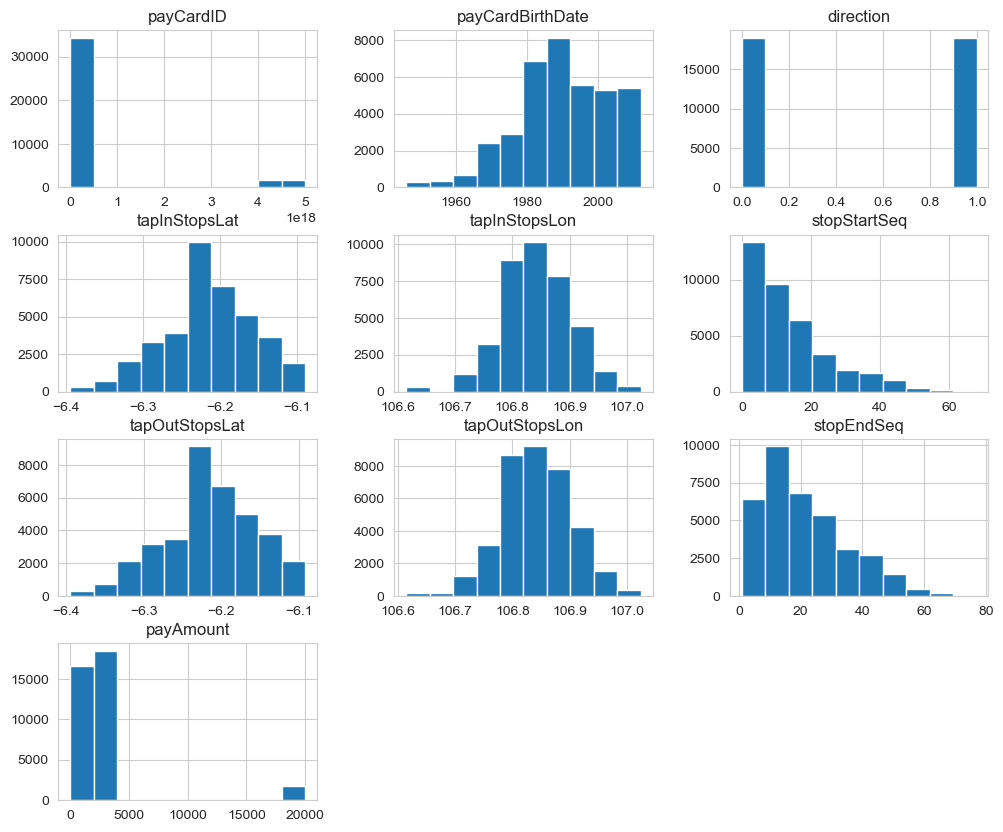

In [6]:
# General Histogram Grafik
df.hist(figsize = (12,10))
plt.show

Terlihat dari grafik di atas:

1. `payCardID` tidak perlu divisualisasikan karena hanya berfungsi sebagai identifier unik untuk kartu.
2. `Direction` lebih cocok divisualisaikan menggunakan bar chart.
3. tapInStops dan tapOutStops Latitude maupun Longtitude lebih cocok divisualisasikan dengan heatmap atau scattermap karena persebaran lokasi hanya terbatas di area Jakarta (dan sekitarnya, contoh: Cibubur).
4. Selanjutnya, visualisasi data dilakukan kembali setelah proses data cleaning selesai.

### Cek Missing Value

In [7]:
## Data Frame Table

missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
).round(2)

missing_table = pd.DataFrame({
    'Missing Count' : missing_count,
    'Missing Percentage (%)': missing_percentage
})

## Gunakan Hanya Data yang Missing
missing_table = missing_table[
    missing_table['Missing Count'] > 0
]

## Urutan Data Descending
missing_table = missing_table.sort_values(
    by='Missing Percentage (%)',
    ascending=False
)

## Mengubah index menjadi kolom
missing_table = missing_table.reset_index()

# Rename nama kolom
missing_table = missing_table.rename(
    columns={
        'index' : 'Transjakarta Data',
    }
)

## Membuat Nomor Urut Baru
missing_table.insert(
    0,
    'No',
    range(1, len(missing_table) + 1)
)

## Tambahkan Total Missing Count di paling bawah
total_row = pd.DataFrame({
    'No': [''],
    'Transjakarta Data': ['TOTAL'],
    'Missing Count': [missing_table['Missing Count'].sum()],
    'Missing Percentage (%)': [
        missing_table['Missing Percentage (%)'].sum()
    ]
})

missing_table = pd.concat(
    [missing_table, total_row],
    ignore_index=True
)

## Agar Table Rata Tengah & Wrap Text
display(
    missing_table.style.hide(axis='index')
    .format({
        'Missing Percentage (%)': '{:.2f}'
    })
    .set_properties(**{
        'text-align':'center',
        'white-space':'normal'
    })
    .set_table_styles([
        {
            'selector':'th',
            'props':[
                ('text-align', 'center'),
                ('white-space','normal'),
                ('font-size','16px'),
                ('font-weight','bold'),
                ('word-wrap','break-word')
            ]
        },
        {
            'selector':'td',
            'props':[
                ('text-align', 'center'),
                ('font-size','14px'),
                ('word-wrap','break-word')
            ]
        },
        {
            'selector':'table',
            'props':[
                ('margin-left', 'auto'),
                ('margin-right','auto'),
            ]
        },
    ])
)

No,Transjakarta Data,Missing Count,Missing Percentage (%)
1,tapOutStops,2289,6.04
2,corridorName,1930,5.09
3,tapOutStopsName,1344,3.55
4,tapOutStopsLat,1344,3.55
5,tapOutStopsLon,1344,3.55
6,stopEndSeq,1344,3.55
7,tapOutTime,1344,3.55
8,corridorID,1257,3.32
9,tapInStops,1213,3.20
10,payAmount,1007,2.66


Dari tabel diatas, 

1. Missing value pada data ini relatif rendah (<10%), dengan missing count + percentage tertinggi pada `tapOutstops`.
2. `corridorID` dan `corridorName` dapat diinvestigasi keterkaitannya. `corrdiorID` dapat diisi dengan mengetahui `corridorName` nya, begitupun sebaliknya. Ketika kedua datanya tidak ada pada transaksi itu, baru data akan di-drop untuk keperluan analisis.
3. `tapOutStopsName`, `tapOutStopsLat`, `tapOutStopsLon`, `stopEndSeq` dan `tapOutTime` memiliki missing count yang sama. Sehingga perlu dicek keterkaitannya.
4. Secara umum, data tergolong memiliki kualitas yang baik.

Data missing value ini kemudian divisualisasikan ke dalam grafik barChart sebagai berikut:

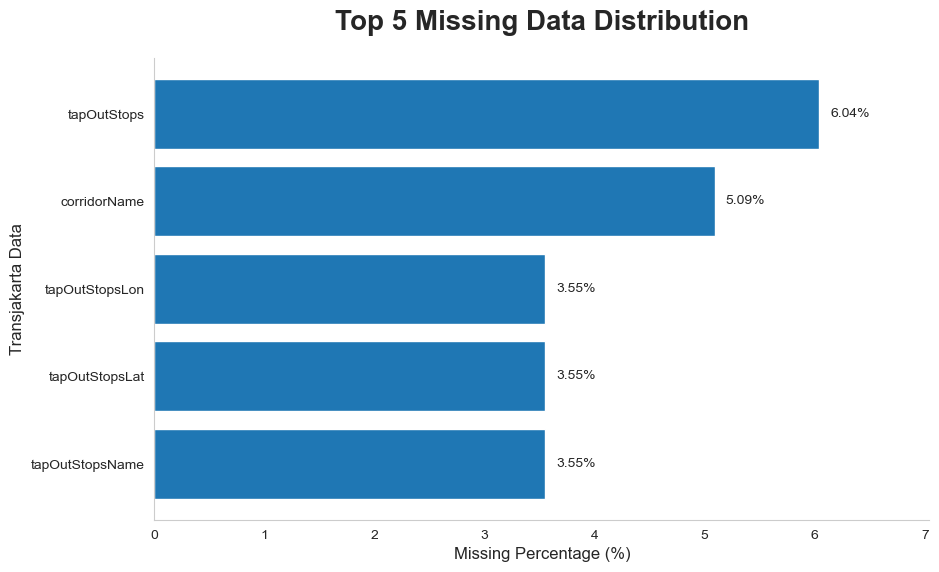

In [8]:
# Hilangkan baris TOTAL
missing_chart = missing_table[
    missing_table['Transjakarta Data'] != 'TOTAL'
]

# Ambil TOP 5 missing terbesar
missing_table_sorted = (
    missing_chart
    .sort_values(by='Missing Percentage (%)', ascending=False)
    .head(5)
    .sort_values(by='Missing Percentage (%)', ascending=True)
)

plt.figure(figsize=(10,6))

bars = plt.barh(
    missing_table_sorted['Transjakarta Data'],
    missing_table_sorted['Missing Percentage (%)']
)

# Label persentase
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 0.1,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}%',
        va='center'
    )

plt.xlim(
    0,
    missing_table_sorted['Missing Percentage (%)'].max() + 1
)

# Judul
plt.title(
    'Top 5 Missing Data Distribution',
    fontsize=20,
    fontweight='bold',
    pad=20
)

plt.xlabel('Missing Percentage (%)', fontsize=12)
plt.ylabel('Transjakarta Data', fontsize=12)

# Hapus grid
plt.grid(False)

# Hapus frame atas & kanan
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.show()

In [9]:
# Cek Duplicate Data

df.duplicated().sum()

np.int64(0)

Tidak ada duplikat pada data.

Kolom numerik:
Index(['payCardID', 'payCardBirthDate', 'direction', 'tapInStopsLat',
       'tapInStopsLon', 'stopStartSeq', 'tapOutStopsLat', 'tapOutStopsLon',
       'stopEndSeq', 'payAmount'],
      dtype='object')


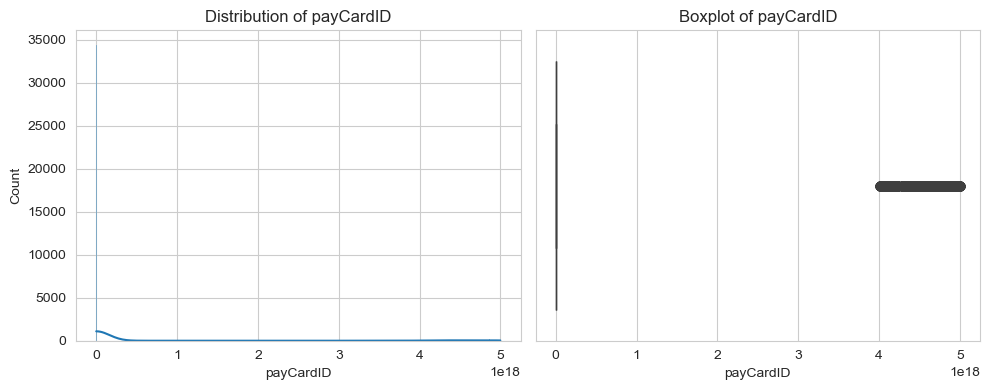

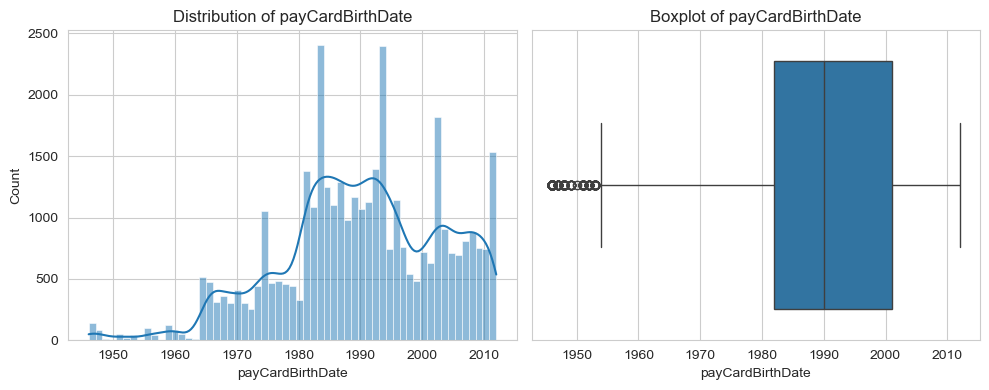

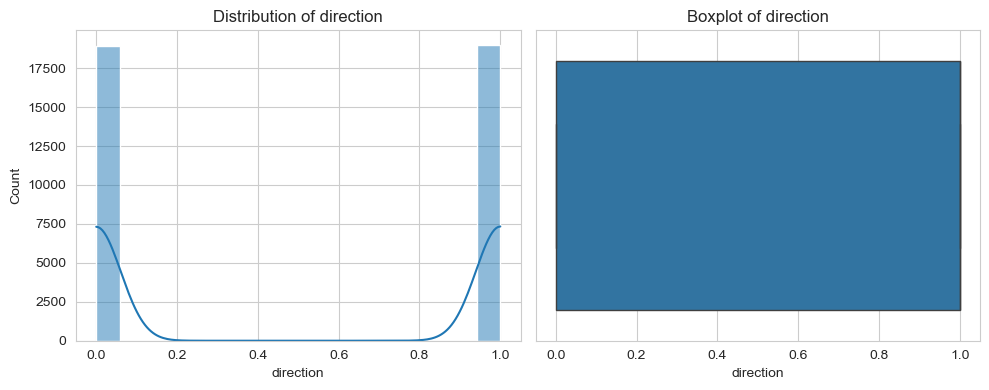

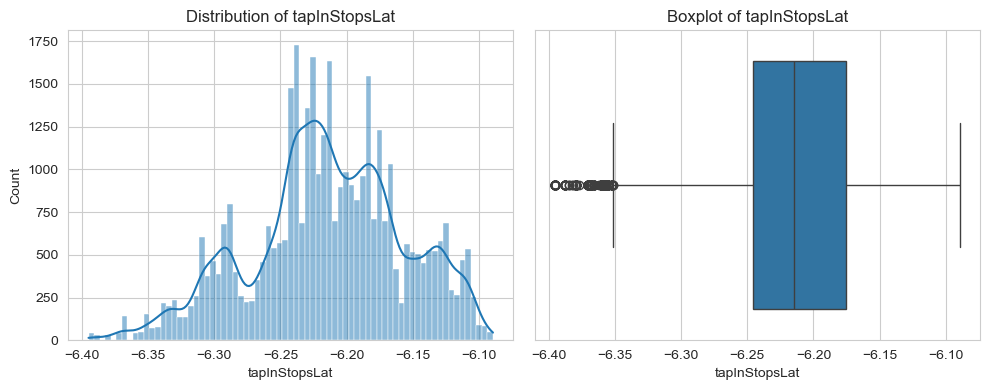

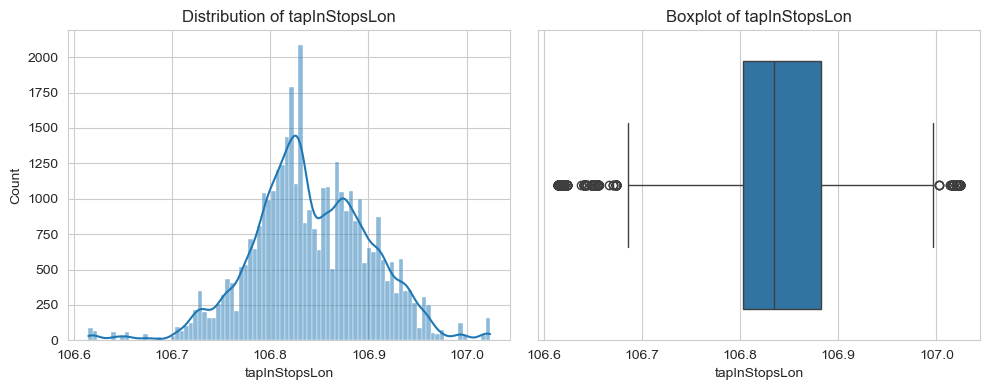

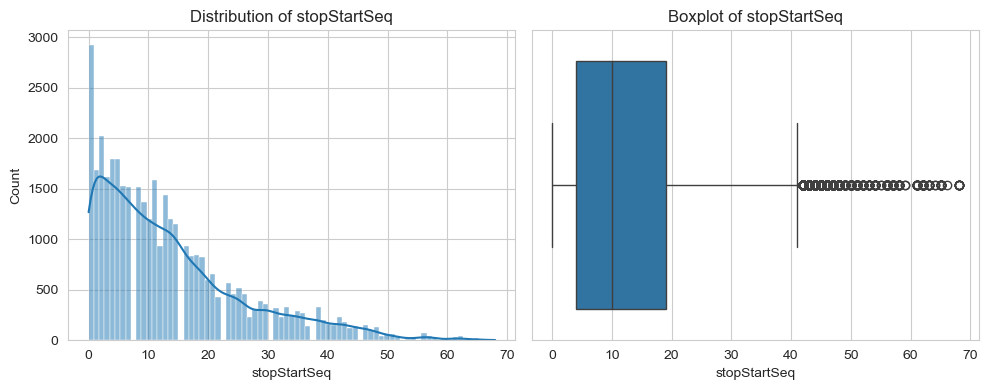

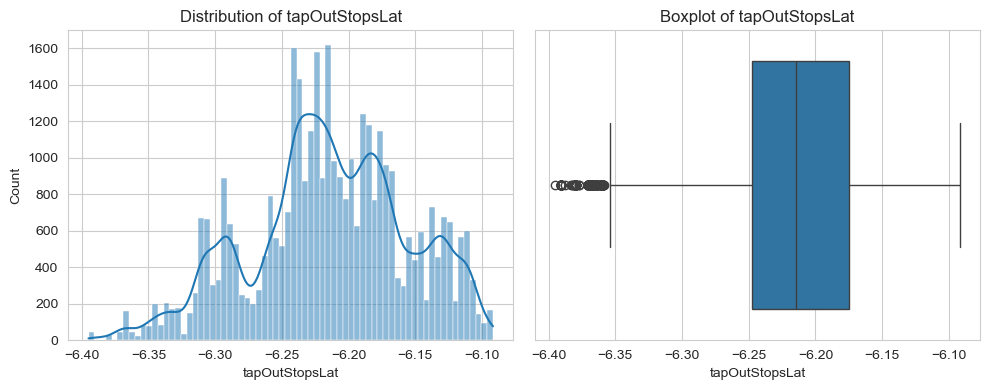

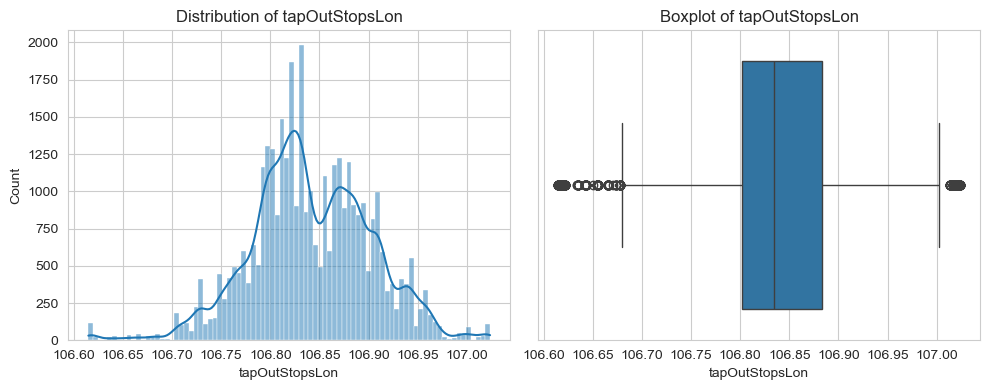

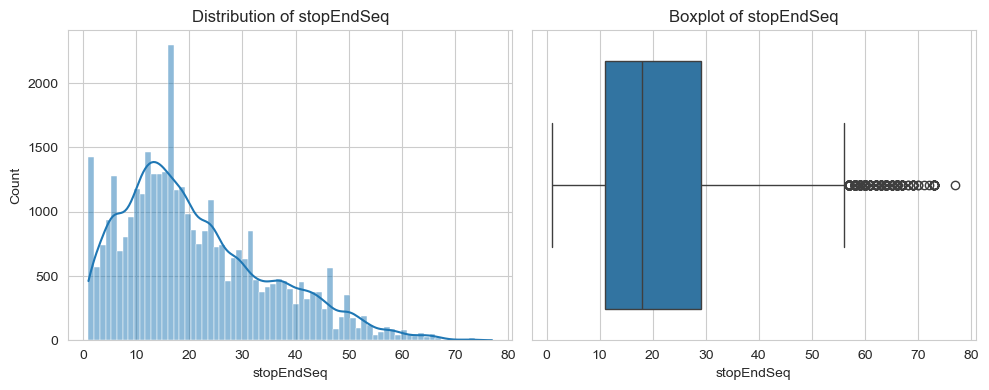

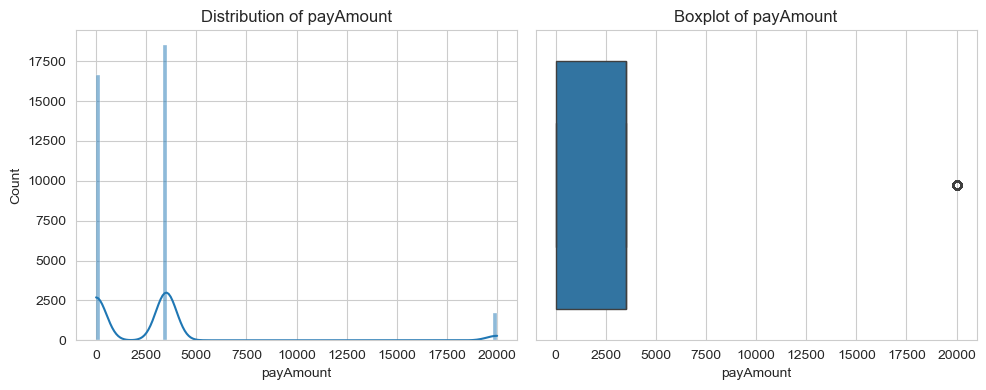

In [10]:
# Cek distribusi awal data
# ambil kolom numerik
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

print("Kolom numerik:")
print(numerical_cols)

# plot distribusi
for col in numerical_cols:
    
    plt.figure(figsize=(10,4))
    
    # Histogram
    plt.subplot(1,2,1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    
    # Boxplot
    plt.subplot(1,2,2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

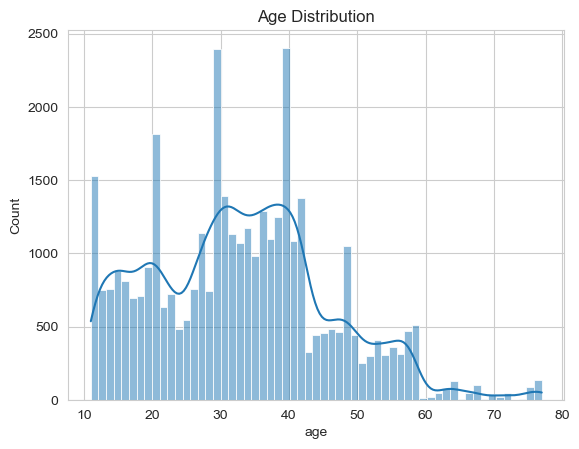

P-value: 1.3523321867946702e-27


In [11]:
# Cek distribusi + normalitas

# Data distribusi umur
from datetime import datetime

current_year = 2023 #karena data diambil tahun 2023

df['age'] = current_year - df['payCardBirthDate']

sns.histplot(df['age'], kde=True)
plt.title('Age Distribution')
plt.show()

from scipy.stats import shapiro

data = df['age'].dropna()

stat, p = shapiro(data.sample(5000, random_state=42))

print("P-value:", p)

Berdasarkan grafik distribusi usia pengguna diatas, data dapat dikatakan tidak terdistribusi normal (p<0.05). Persebaran data tergolong right-skewed dengan pengguna umumnya berada di rentang usia 25-45 tahun, dengan puncaknya di umur akhir 30-an.

## Data Cleaning

In [12]:
# Buat dataset copy khusus untuk data cleaning

df_cleans = df.copy()

print("Jumlah row data asli :", len(df))
print("Jumlah row data cleans:", len(df_cleans))

Jumlah row data asli : 37900
Jumlah row data cleans: 37900


## Convert datatype tapInTime dan tapOutTime

Dari hasil identifikasi data pada tahap data understanding, diketahui bahwa data `tapInTime` dan `tapOutTime` perlu diconvert dari bentuk object ke datetime sehingga dapat diidentifikasi lamanya perjalanan setiap transaksi.

In [13]:
### Ubah datatype tapInTime dan tapOutTime dari object ke datetime
df_cleans['tapInTime'] = pd.to_datetime(df_cleans['tapInTime'],errors = 'coerce')
df_cleans['tapOutTime'] = pd.to_datetime(df_cleans['tapOutTime'],errors = 'coerce')

df_cleans.head(10)

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,stopStartSeq,tapInTime,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount,age
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,7,2023-04-03 05:21:44,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0,15
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,13,2023-04-03 05:42:44,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0,26
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,38,2023-04-03 05:59:06,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0,31
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,23,2023-04-03 05:44:51,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0,45
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,5,2023-04-03 06:17:35,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0,41
5,DDES630K2F80KC,2251412124634980,dki,Tirta Siregar,F,1993,1T,Cibubur - Balai Kota,0.0,B00127P,...,3,2023-04-03 05:08:01,B00694P,Grand Sahid,-6.210975,106.82059,6.0,2023-04-03 05:52:25,20000.0,30
6,HEMW326B9N91TV,213155822653833,emoney,"R. Devi Hariyah, S.T.",M,1974,JAK.18,Kalibata - Kuningan,0.0,B00243P,...,25,2023-04-03 06:58:21,NaN,NaN,NaN,NaN,NaN,NaT,0.0,49
7,XTKE052E5E87LN,3587341902618993,dki,Darmanto Rajasa,F,1991,NaN,NaN,1.0,B03416P,...,2,2023-04-03 06:44:24,B00899P,Jln. Baros,-6.311046,106.78400,12.0,2023-04-03 07:11:43,0.0,32
8,OIHS248V7S72EB,6510013988638519,dki,"Cagak Maheswara, S.Sos",F,1992,B14,Bekasi Barat - Kuningan,1.0,B00795P,...,1,2023-04-03 06:01:44,B01853P,Kayuringin 2,-6.245948,106.99247,16.0,2023-04-03 06:51:12,20000.0,31
9,ERXO372B2H63RB,3580401035990896,dki,"T. Dadap Pradana, M.Ak",M,2004,1Q,Rempoa - Blok M,0.0,B05781P,...,15,2023-04-03 05:57:47,B06578P,Blok M Jalur 3,-6.243426,106.80188,24.0,2023-04-03 06:51:12,3500.0,19


In [14]:
# Ambil tanggal saja
df_cleans['Date'] = (
    df_cleans['tapInTime'].dt.date
)

# Hitung jumlah trip per hari
daily_trip = (
    df_cleans.groupby('Date')
    .size()
    .reset_index(name='Jumlah Trip')
)

# Rata-rata trip harian
average_daily_trip = (
    daily_trip['Jumlah Trip'].mean()
)

print(
    f'Rata-rata jumlah trip harian: {average_daily_trip:,.0f}'
)

Rata-rata jumlah trip harian: 1,263


In [15]:
## Validasi hasil convert datetime

## Cek jumlah missing datetime
print("tapInTime kosong:", df_cleans['tapInTime'].isna().sum())
print("tapOutTime kosong:",df_cleans['tapOutTime'].isna().sum())

tapInTime kosong: 0
tapOutTime kosong: 1344


Berarti, pada kolom `tapOutTime` terdapat 1344 data yang kosong. Data yang diketahui memiliki `tapOutTime` kosong kemudian didefinisikan sebagai transaksi **incomplete**. Data ini dapat digunakan untuk investigasi seberapa besar persentase error pada sistem integrasi pembayaran TransJakarta.

In [16]:
## Pernyataan Kembali Transaksi Complete dan Incomplete

df_cleans['tripStatus'] = np.where(
    (df_cleans['tapOutTime'].isna()),
    'Incomplete',
    'Complete'
)

df_cleans[['tapInTime','tapOutTime','tripStatus']].head(10)

,tapInTime,tapOutTime,tripStatus
0,2023-04-03 05:21:44,2023-04-03 06:00:53,Complete
1,2023-04-03 05:42:44,2023-04-03 06:40:01,Complete
2,2023-04-03 05:59:06,2023-04-03 06:50:55,Complete
3,2023-04-03 05:44:51,2023-04-03 06:28:16,Complete
4,2023-04-03 06:17:35,2023-04-03 06:57:03,Complete
5,2023-04-03 05:08:01,2023-04-03 05:52:25,Complete
6,2023-04-03 06:58:21,NaT,Incomplete
7,2023-04-03 06:44:24,2023-04-03 07:11:43,Complete
8,2023-04-03 06:01:44,2023-04-03 06:51:12,Complete
9,2023-04-03 05:57:47,2023-04-03 06:51:12,Complete


In [17]:
## Mengetahui Jumlah Complete dan Incomplete Data Awal

trip_counts = df_cleans['tripStatus'].value_counts()

#Display Trip Status
display(trip_counts)

#Total Keseluruhan Data Trip
print("Total Seluruh Trip:", trip_counts.sum())

tripStatus
Complete      36556
Incomplete     1344
Name: count, dtype: int64

Total Seluruh Trip: 37900


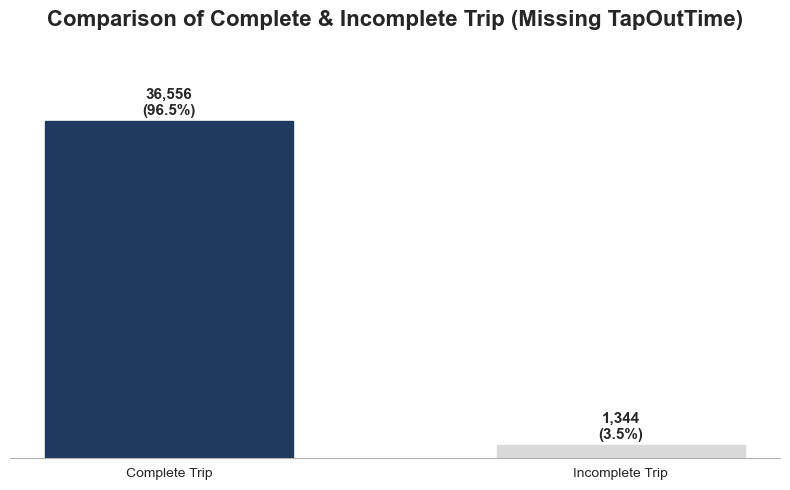

In [18]:
## Dinyatakan dalam bentuk grafik

## Jumlah Data
complete = trip_counts.get('Complete', 0)
incomplete = trip_counts.get('Incomplete', 0)

# Total
total = complete + incomplete

# Persentase
complete_pct = (complete / total) * 100
incomplete_pct = (incomplete / total) * 100

# Data untuk Bar Chart
kategori = ['Complete Trip', 'Incomplete Trip']
jumlah = [complete, incomplete]

# =========================
# Figure
# =========================

plt.figure(figsize=(8,5))

bars = plt.bar(
    kategori,
    jumlah,
    width=0.55
)

# Warna Clean Consulting Style

bars[0].set_color('#1F3A5F')   # dark blue
bars[1].set_color('#D9D9D9')   # light grey

# =========================
# Rapihin Axis
# =========================

ax = plt.gca()

# Hilangkan border yang tidak perlu
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)

# Bottom line tipis
ax.spines['bottom'].set_color('#B0B0B0')

# Hilangkan angka y-axis
plt.yticks([])

# Hilangkan grid
plt.grid(False)

# =========================
# Label Jumlah + Persentase
# =========================

for bar, persen in zip(
    bars,
    [complete_pct, incomplete_pct]
):

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + (total * 0.01),
        f'{yval:,}\n({persen:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )
    
# Title 

plt.title(
    'Comparison of Complete & Incomplete Trip (Missing TapOutTime)',
    fontsize=16,
    fontweight='bold',
    loc='center',
    pad=20
)

# Layout

plt.ylim(0, max(jumlah) * 1.2)

plt.tight_layout()

plt.show()

### Distribusi Complete dan Incomplete Trip

Visualisasi grafik di atas menunjukkan bahwa sebagian besar perjalanan TransJakarta berhasil diselesaikan, dimana sebanyak `36.556` transaksi atau `96.5%` total transaksi termasuk **complete trip**. Sementara itu, `1.334` transaksi lainnya atau `3.5%` tergolong **incomplete trip** karena tidak tersedianya informasi `tapOutTime`.



Karena anslisis lanjutan seperti distribusi tujuan perjalanan pelanggan Transjakarta serta durasi perjalanan membutuhkan informasi asal dan tujuan yang lengkap, maka data yang tidak memiliki `tapOutTime` atau **incomplete trip** dikeluarkan pada tahap analisis selanjutnya dan hanya menggunakan data yang tergolong **complete trip**.

## Catatan Terkait tapOutStops

Hasil analisis ***missing value*** sebelumnya menunjukkan bahwa kolom `tapOutStops` memiliki jumlah missing value terbesar, yaitu sebanyak `2.289` data atau sekitar `6.04%` dari total data. Namun, tingginya missing value pada kolom ini sebenarnya terjadi karena informasi tap-out penumpang memang tidak tercatat secara langkap.

Ketika data `tapOutTime` tidak tersedia, maka informasi yang berkaitan dengan proses tap-out seperti `stopEndSeq`, `tapOutStops`, `tapOutStopsLat`, dan `tapOutStopsLon` juga ikut tidak tercatat. 

Namun, hasil pengecekan lebih lanjut menunjukkan masih terdapat sejumlah data dimana `tapOutStops` kosong meskipun informasi tap-out lainnya masih tersedia. Dengan demikian, missing value apda `tapOutStops` tidak sepenuhnya selalu disebabkan oleh hilangnya set data tap-out, tapi juga terdapat beberapa kasus dimana identifier halte tujuan tidak tercatat meskipun atribut tap-out masih tersedia.

Selanjutnya, karena `tapOutStops` pada dasarnya hanya berfungsi sebagai identifier halte tujuan sehingga hilangnya data `tapOutStops` tidak terlalu mempengaruhi proses analisis secara umum, selama `corridorID` dan `corridorName` masih lengkap.

In [19]:
# Cek apakah ada kasus saat tapOutStops kosong tetapi data tap-out lain masih ada
cek_tapout = df_cleans[
    (df_cleans['tapOutStops'].isna()) &
    (
        df_cleans['tapOutTime'].notna() |
        df_cleans['tapOutStopsName'].notna() |
        df_cleans['tapOutStopsLat'].notna() |
        df_cleans['tapOutStopsLon'].notna() |
        df_cleans['stopEndSeq'].notna()
    )
]

print("Jumlah kasus tapOutStops kosong tetapi data tap-out lain masih ada:")
print(len(cek_tapout))

# Preview data
cek_tapout.head()

Jumlah kasus tapOutStops kosong tetapi data tap-out lain masih ada:
945


,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount,age,Date,tripStatus
89,QMHC825R0K38KM,3537543297101185,dki,Samsul Ramadan,M,1966,M11,NaN,1.0,P00158,...,NaN,Walikota Jakarta Timur,-6.212540,106.94537,7.0,2023-04-03 06:52:14,3500.0,57,2023-04-03,Complete
149,OVAQ760H7C61IE,4946777822784,online,Wirda Yuliarti,M,1990,5,Matraman Baru - Ancol,0.0,P00224,...,NaN,Budi Utomo,-6.166063,106.83906,9.0,2023-04-03 05:33:29,3500.0,33,2023-04-03,Complete
168,MGKL991J8F92EL,4719371541269014,dki,Nasab Megantara,F,1997,3A,Rusun Pesakih - Kalideres,1.0,B01798P,...,NaN,Pertamina Kalideres Daan Mogot,-6.155710,106.70927,2.0,2023-04-03 07:20:34,0.0,26,2023-04-03,Complete
359,ZSRY589C8Y95YP,4268640600849949,dki,"Elvina Situmorang, S.Psi",F,1985,JAK.15,Bulak Turi - Tanjung Priok,1.0,B04940P,...,NaN,Sbr. Kebantenan IX,-6.108601,106.93245,28.0,2023-04-03 18:58:18,0.0,38,2023-04-03,Complete
428,JAND103I5L52IF,6011618540818377,dki,"Cut Agnes Thamrin, S.Psi",F,1970,JAK.26,Rawamangun - Duren Sawit,0.0,B05069P,...,NaN,HKBP Rawamangun,-6.196463,106.88597,45.0,2023-04-03 18:44:09,0.0,53,2023-04-03,Complete


In [20]:
## Membuat dataframe baru yang hanya berisi complete trip

df_complete = df_cleans[df_cleans['tripStatus'] == 'Complete'].copy()

print("Jumlah Complete Trip:", len(df_complete))

df_complete.head(11)

Jumlah Complete Trip: 36556


,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount,age,Date,tripStatus
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,P00253,Tegalan,-6.203101,106.85715,12.0,2023-04-03 06:00:53,3500.0,15,2023-04-03,Complete
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,B03307P,Sampoerna Strategic,-6.217152,106.81892,21.0,2023-04-03 06:40:01,3500.0,26,2023-04-03,Complete
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,B04962P,Simpang Kunir Kemukus,-6.133731,106.81475,39.0,2023-04-03 06:50:55,3500.0,31,2023-04-03,Complete
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,B03090P,Raya Penggilingan,-6.183068,106.93194,29.0,2023-04-03 06:28:16,3500.0,45,2023-04-03,Complete
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,P00098,Kali Besar Barat,-6.135355,106.81143,15.0,2023-04-03 06:57:03,3500.0,41,2023-04-03,Complete
5,DDES630K2F80KC,2251412124634980,dki,Tirta Siregar,F,1993,1T,Cibubur - Balai Kota,0.0,B00127P,...,B00694P,Grand Sahid,-6.210975,106.82059,6.0,2023-04-03 05:52:25,20000.0,30,2023-04-03,Complete
7,XTKE052E5E87LN,3587341902618993,dki,Darmanto Rajasa,F,1991,NaN,NaN,1.0,B03416P,...,B00899P,Jln. Baros,-6.311046,106.78400,12.0,2023-04-03 07:11:43,0.0,32,2023-04-03,Complete
8,OIHS248V7S72EB,6510013988638519,dki,"Cagak Maheswara, S.Sos",F,1992,B14,Bekasi Barat - Kuningan,1.0,B00795P,...,B01853P,Kayuringin 2,-6.245948,106.99247,16.0,2023-04-03 06:51:12,20000.0,31,2023-04-03,Complete
9,ERXO372B2H63RB,3580401035990896,dki,"T. Dadap Pradana, M.Ak",M,2004,1Q,Rempoa - Blok M,0.0,B05781P,...,B06578P,Blok M Jalur 3,-6.243426,106.80188,24.0,2023-04-03 06:51:12,3500.0,19,2023-04-03,Complete
10,CLWK627W2M22WO,5541851157087967,dki,"Oskar Widiastuti, S.Farm",F,1997,5M,Kampung Melayu - Tanah Abang via Cikini,1.0,B05433P,...,B02387P,Matraman 4,-6.199782,106.85450,23.0,2023-04-03 07:23:54,3500.0,26,2023-04-03,Complete


## Data Cleaning : corridorName

Setelah proses cleaning pada data yang berkaitan dengan informasi tap-out selesai dilakukan, tahap data cleaning dilanjutkan pada `corridorName`, yang merupakan kolom dengan jumlah missing value terbesar kedua pada dataset ini.

In [21]:
# Mengetahui Jumlah Koridor

print("Jumlah Koridor:", df_complete['corridorName'].nunique())

df_complete ['corridorName'].value_counts().head(20)

Jumlah Koridor: 216


corridorName
Cibubur - Balai Kota                           375
Ciputat - CSW                                  371
Harmoni - Jakarta International Stadium        329
Pulo Gadung - Monas                            328
Kampung Rambutan - Pondok Gede                 324
Kalideres - Bundaran HI via Veteran            319
Rusun Pondok Bambu - Walikota Jakarta Timur    317
Kebayoran Lama - Tanah Abang                   315
Rusun Rawa Bebek - Kodamar                     301
BKN - Blok M                                   292
Pasar Minggu - Tanah Abang                     291
Kampung Rambutan - Pasar Rebo via Poncol       284
Kampung Melayu - Pulo Gebang via BKT           281
Ragunan - Blok M via Kemang                    280
Blok M - Kota                                  280
Kampung Melayu - Pondok Kelapa                 276
Tanah Abang - Kebayoran Lama                   276
Pulo Gebang - Rorotan                          268
Terminal Tanah Merah - Pulo Gadung             257
Gondangdia - Senen

Diketahui bahwa pada dataset ini, terdapat 216 nilai `corridorName` yang berbeda (unique).

In [22]:
## Cek Jumlah CorridorID

print("Jumlah KoridorID:", df_complete['corridorID'].nunique())

df_complete ['corridorID'].value_counts().head(20)

Jumlah KoridorID: 221


corridorID
1T         384
S21        376
JIS3       332
JAK.06     327
11P        323
8C         321
2E         307
M7B        298
9D         297
JAK.72     292
6N         290
11Q        287
JAK.42     280
JAK.11     275
2          272
JAK.27     272
JAK.58     261
JAK.112    259
2P         258
T11        255
Name: count, dtype: int64

Diketahui bahwa pada dataset ini terdapat 216 data `corridorName` yang unik, sedangkan pada kolom `corridorID` terdapat 221 data unik. Jumlah nilai unik pada `corridorID` yang lebih banyak dibandingkan `corridorName` menunjukkan adanya kemungkinan beberapa `corridorID` belum memiliki informasi `corridorName` yang terisi.

Berdasarkan kondisi tersebut, dilakukan identifikasi hubungan antara `corridorID` dan `corridorName` untuk melihat apakah kedua kolom memiliki keterkaitan yang konsisten, Hasil identifikasi menunjukkan bahwa setiap `corridorID` umumnya merepresentasikan satu nama koridor tertentu, sehingga hubungan tersebut dapat dimanfaatkan untuk membantu proses pengisian missing value pada `corridorName`.

Oleh karena itu, missing value pada `corridorName` diisi menggunakan metode dictionary mapping, yaitu dengan memanfaatkan pasangan `corridorID` dan `corridorName` yang sudah tersedia pada dataset sebaagi referensi pengisian data yang kosong.

In [23]:
# Kondisi 1: Cek jumlah data dimana CorridorID ada tapi CorridorName kosong

ID_ada_name_kosong = len (
    df_complete[
        (df_complete['corridorID'].notna()) &
        (df_complete ['corridorName'].isna())
        ])
    
print("Corridor ID ada, Name kosong:", ID_ada_name_kosong)
df_complete[
    (df_complete ['corridorID'].notna()) &
    (df_complete ['corridorName'].isna()) 
    ][['corridorID', 'corridorName']].head(10)

Corridor ID ada, Name kosong: 776


,corridorID,corridorName
38,5M,NaN
39,2,NaN
60,T21,NaN
61,12A,NaN
73,M3,NaN
89,M11,NaN
112,JAK.13,NaN
123,JAK.22,NaN
202,8K,NaN
214,JAK.27,NaN


In [24]:
# Kondisi 2: Cek jumlah data dimana corridorName Ada tapi CorridorID kosong

Name_ada_ID_kosong = len (
    df_complete[
        (df_complete['corridorID'].isna()) &
        (df_complete ['corridorName'].notna())
        ])

print("Corridor Name ada, tapi ID kosong:", Name_ada_ID_kosong)

df_complete[
        (df_complete['corridorID'].isna()) &
        (df_complete ['corridorName'].notna())
        ][['corridorID', 'corridorName']].head(10)

Corridor Name ada, tapi ID kosong: 127


,corridorID,corridorName
438,NaN,Rusun Waduk Pluit - Penjaringan
895,NaN,Tanah Abang - Kebayoran Lama
1410,NaN,Sunter Boulevard Barat - Penjaringan
1723,NaN,Pulo Gebang - Pulo Gadung 2 via PIK
2423,NaN,Kampung Melayu - Pulo Gebang via BKT
2721,NaN,Cililitan - Condet
2890,NaN,Tanjung Priok - Pluit
2899,NaN,Ragunan - Gelora Bung Karno
3054,NaN,Puri Beta - Pancoran Barat
3263,NaN,Kalimalang - Duren Sawit


In [25]:
# Kondisi 3: Cek jumlah data dimana corridorName dan corridorID sama-sama kosong

Keduanya_kosong = len (
    df_complete[
        (df_complete['corridorID'].isna()) &
        (df_complete ['corridorName'].isna())
        ])

print("Keduanya kosong:", Keduanya_kosong)

df_complete[
        (df_complete['corridorID'].isna()) &
        (df_complete ['corridorName'].isna())
        ][['corridorID', 'corridorName']].head(10)

Keduanya kosong: 1078


,corridorID,corridorName
7,NaN,NaN
120,NaN,NaN
240,NaN,NaN
250,NaN,NaN
257,NaN,NaN
275,NaN,NaN
286,NaN,NaN
400,NaN,NaN
425,NaN,NaN
440,NaN,NaN


In [26]:
# Kondisi 4: Cek jumlah data dimana corridorName dan corridorID keduanya ada

Keduanya_ada = len (
    df_complete[
        (df_complete['corridorID'].notna()) &
        (df_complete ['corridorName'].notna())
        ])

print("Keduanya ada:", Keduanya_ada)

df_complete[
        (df_complete['corridorID'].notna()) &
        (df_complete ['corridorName'].notna())
        ][['corridorID', 'corridorName']].head(10)

Keduanya ada: 34575


,corridorID,corridorName
0,5,Matraman Baru - Ancol
1,6C,Stasiun Tebet - Karet via Patra Kuningan
2,R1A,Pantai Maju - Kota
3,11D,Pulo Gebang - Pulo Gadung 2 via PIK
4,12,Tanjung Priok - Pluit
5,1T,Cibubur - Balai Kota
8,B14,Bekasi Barat - Kuningan
9,1Q,Rempoa - Blok M
10,5M,Kampung Melayu - Tanah Abang via Cikini
11,M7B,BKN - Blok M


In [27]:
### Rekap
print("Corridor ID ada, Name kosong:", ID_ada_name_kosong)
print("Corridor Name ada, tapi ID kosong:", Name_ada_ID_kosong)
print("Keduanya kosong:", Keduanya_kosong)
print("Keduanya ada:", Keduanya_ada)

Corridor ID ada, Name kosong: 776
Corridor Name ada, tapi ID kosong: 127
Keduanya kosong: 1078
Keduanya ada: 34575


Untuk membuat basis dictionary yang tepat untuk keperluan mapping, akan dilakukan pemeriksaan pada konsistensi data.

In [28]:
### Cek konsistensi mapping
      
corridor_mapping = df_complete[
    (df_complete['corridorID'].notna()) &
    (df_complete['corridorName'].notna())
    ][['corridorID','corridorName']]\
    .drop_duplicates()\
    .sort_values(by = 'corridorID')\
    .reset_index(drop = True)

print("Jumlah mapping unik:", len(corridor_mapping))
corridor_mapping.style.hide(axis = 'index')

Jumlah mapping unik: 221


corridorID,corridorName
1,Blok M - Kota
10,Tanjung Priok - PGC 2
10A,Rusun Marunda - Tanjung Priok
10B,Rusun Cipinang Besar Selatan - Penas Kalimalang
10D,Kampung Rambutan - Tanjung Priok
10H,Tanjung Priok - Blok M
10K,Tanjung Priok - Senen via Taman BMW
11,Pulo Gebang - Matraman
11B,Rusun Rawa Bebek - Penggilingan
11C,Rusun Pinus Elok - Rusun Pulo Gebang


Dari data diatas, diketahui jumlah pasangan **koridor unik = 221**.

In [29]:
# Verifikasi Konsistensi Data Koridor TransJakarta

corridor_check = df_complete [
    ['corridorID', 'corridorName']].drop_duplicates().sort_values(by = 'corridorID')

corridor_check 

,corridorID,corridorName
1342,1,NaN
63,1,Blok M - Kota
226,10,Tanjung Priok - PGC 2
4126,10,NaN
12027,10A,Rusun Marunda - Tanjung Priok
...,...,...
35262,NaN,BKN - Blok M
35944,NaN,Tanah Abang - Meruya
36927,NaN,Pinang Ranti - Pluit
37113,NaN,Rusun Cipinang Besar Selatan - Penas Kalimalang


Berdasarkan hasil pengecekan, ditemukan bahwa satu `corridorID` dapat memiliki beberapa variasi `corridorName`, dimana sebagain data masih kosong sementara data lainnya telah terisi dengan benar. Kondisi serupa juga berpotensi pada data `corridorName` terhadap `corridorID`.

Oleh karena itu, dilakukan proses pelengkapan data untuk meningkatkan konsistensi data koridor, yaitu:
1. Mengisi nilai kosong pada `corridorName` berdasarkan pasangan `corridorID` yang sesuai.
2. Mengisi nilai kosong pada `corridorID` berdasarkan pasangan `corridorName` yang sesuai.
3. Ketika baris data memiliki `corridorID` dan `corridorName` sama-sama kosong, maka data tersebut akan dihapus karena tidak memiliki informasi koridor yang dapat digunakan untuk analisis selanjutnya. 

In [30]:
## Membuat Dataset Mapping Koridor

df_mapping = df_complete.copy()

In [31]:
# Revalidasi jumlah data kosong 

## Cek jumlah data dimana corridorID dan corridorName sama-sama kosong

both_missing = df_complete[
    df_complete[['corridorID', 'corridorName']]
    .isna()
    .all(axis=1)
]

print(f'Jumlah data dengan corridorID dan corridorName kosong: {len(both_missing)}')

Jumlah data dengan corridorID dan corridorName kosong: 1078


In [32]:
## Menghapus data yang corridorID dan corridorName sama-sama kosong

df_mapping = df_mapping.dropna(
    subset=['corridorID', 'corridorName'],
    how='all'
)

In [33]:
## Mapping Dictionary 1: corridorID terhadap corridorName

id_to_name = df_mapping.dropna(subset=['corridorName']) \
    .drop_duplicates('corridorID') \
    .set_index('corridorID')['corridorName']

print("Jumlah data mapping corridorID terhadap corridorName:",len(id_to_name))
pd.DataFrame(id_to_name).reset_index().head(10)

Jumlah data mapping corridorID terhadap corridorName: 222


,corridorID,corridorName
0,5,Matraman Baru - Ancol
1,6C,Stasiun Tebet - Karet via Patra Kuningan
2,R1A,Pantai Maju - Kota
3,11D,Pulo Gebang - Pulo Gadung 2 via PIK
4,12,Tanjung Priok - Pluit
5,1T,Cibubur - Balai Kota
6,B14,Bekasi Barat - Kuningan
7,1Q,Rempoa - Blok M
8,5M,Kampung Melayu - Tanah Abang via Cikini
9,M7B,BKN - Blok M


In [34]:
## Mapping Dictionary 2: corridorName terhadap corridorID
name_to_id = df_mapping.dropna(subset=['corridorID']) \
    .drop_duplicates('corridorName') \
    .set_index('corridorName')['corridorID']

print("Jumlah data mapping corridorName terhadap corridorID:",len(name_to_id))
pd.DataFrame(name_to_id).reset_index().head(10)

Jumlah data mapping corridorName terhadap corridorID: 217


,corridorName,corridorID
0,Matraman Baru - Ancol,5
1,Stasiun Tebet - Karet via Patra Kuningan,6C
2,Pantai Maju - Kota,R1A
3,Pulo Gebang - Pulo Gadung 2 via PIK,11D
4,Tanjung Priok - Pluit,12
5,Cibubur - Balai Kota,1T
6,Bekasi Barat - Kuningan,B14
7,Rempoa - Blok M,1Q
8,Kampung Melayu - Tanah Abang via Cikini,5M
9,BKN - Blok M,M7B


In [35]:
# Mengisi mising value
## Mengisi Missing Value corridorName

df_mapping['corridorName'] = df_mapping['corridorName'].fillna(
    df_mapping['corridorID'].map(id_to_name)
)


## Mengisi Missing Value corridorID

df_mapping['corridorID'] = df_mapping['corridorID'].fillna(
    df_mapping['corridorName'].map(name_to_id)
)

## Mengecek Remaining Missing Value

df_mapping[['corridorID', 'corridorName']].isna().sum()

corridorID      0
corridorName    0
dtype: int64

Setelah proses mapping dan data filling dilakukan, seluruh missing value pada `corridorID` dan `corridorName` berhasil terisi. Hal ini menunjukkan bahwa pasangan data koridor memiliki referensi yang cukup untuk dilakukannya proses pengisian missing value secara dua arah.

In [36]:
# Cek apakah masih ada inkonsistensi naming pada dataset

multi_name = df_mapping.groupby('corridorID')['corridorName'].nunique()

multi_name[multi_name > 1]

Series([], Name: corridorName, dtype: int64)

Setelah dilakukan validasi, diketahui sudah tidak ada data dengan nama duplikat. Oleh karena itu, data cleaning untuk `corridorName` selesai.

In [37]:
## Cek Jumlah Data Setelah Cleaning Corridor

print(f'Jumlah baris data setelah cleaning : {df_mapping.shape[0]}')
print(f'Jumlah kolom data setelah cleaning : {df_mapping.shape[1]}')

Jumlah baris data setelah cleaning : 35478
Jumlah kolom data setelah cleaning : 25


Dari hasil validasi data setelah cleaning, jumlahnya konsisten dengan jumlah data sebelum dilakukan mapping.

In [38]:
missing_table = df_mapping.isna().sum().sort_values(ascending=False)

missing_table[missing_table > 0]

tapInStops     1146
payAmount       941
tapOutStops     913
dtype: int64

Karena `tapInStops` dan `tapOutStops` hanya berfungsi sebagai identifier halte, maka baris data dengan kedua kolom tersebut kosong tetap dipertahankan karena informamsi perjalanan lainnya masih dapat digunakan untuk proses analisis. Tahap berikutnya difokuskan pada pemeriksaan missing value pada kolom `payAmount` yang merepresentasikan nilai transaksi pembayaran.

### data Cleaning: payAmount

In [39]:
#Tampilkan data yang payAmount nya kosong
df_mapping[
    df_mapping['payAmount'].isna()
].head()

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,tapOutStops,tapOutStopsName,tapOutStopsLat,tapOutStopsLon,stopEndSeq,tapOutTime,payAmount,age,Date,tripStatus
11,IIEK980X1O23NZ,347204308990092,emoney,R.M. Labuh Laksmiwati,F,1984,M7B,BKN - Blok M,1.0,P00254,...,P00129,Mampang Prapatan,-6.242699,106.82572,14.0,2023-04-03 06:50:21,NaN,39,2023-04-03,Complete
76,VHUC320U1S58CB,567286069354,flazz,"Dt. Atmaja Suartini, M.Farm",F,2000,JAK.48B,Stasiun Tebet - Kampung Melayu,0.0,B02272P,...,B01732P,Jatinegara Timur,-6.220486,106.86825,11.0,2023-04-03 06:57:35,NaN,23,2023-04-03,Complete
97,KFYK655N1H73XS,6590854673757012,dki,Bajragin Najmudin,M,1986,3H,Jelambar - Kota,0.0,P00087,...,P00138,Museum Fatahillah,-6.133930,106.81209,9.0,2023-04-03 06:35:04,NaN,37,2023-04-03,Complete
169,IWEH403G6J82OS,30428250357040,bni,Estiawan Hastuti,M,2008,M7B,BKN - Blok M,1.0,B02114P,...,B00290P,Dammara,-6.254190,106.83146,18.0,2023-04-03 06:08:02,NaN,15,2023-04-03,Complete
198,WFVC738E7S60SH,3540286623681182,dki,"Karimah Pangestu, S.Kom",M,1968,JAK.48A,Stasiun Tebet - Rusun Karet Tengsin,1.0,B05695P,...,B02320P,Masjid Jami Al Mamur Bukit Duri,-6.225059,106.85606,23.0,2023-04-03 05:54:13,NaN,55,2023-04-03,Complete


In [40]:
# Proporsi missing data 

missing_pay = df_mapping['payAmount'].isna().sum()

print(f'Jumlah missing payAmount: {missing_pay}')

print(f'Persentase missing: {(missing_pay / len(df_mapping))*100:.2f}%')

Jumlah missing payAmount: 941
Persentase missing: 2.65%


Karena fokus utama analisis adalah pola mobilitas penumpang, missing value pada `payAmount` tidak dilakukan imputasi dan tetap dipertahankan. Selain itu, keberadaan transaksi dengan nilai `0` yang valid menunjukkan bahwa missing value memiliki makna yang berbeda dengan nilai pembayaran nol. Oleh karena itu, penggantian missing value berpotensi menimbulkan bias pada interpretasi data transaksi.

Missing value pada `payAmount` selanjutnya dianalisis untuk mengidentifikasi pola tertentu berdasarkan moda maupun koridor perjalanan.

## Rekap Dataset Hasil Cleaning

In [41]:
# Ringkasan dataset
jumlah_transaksi = df_mapping.shape[0]

jumlah_halte = pd.concat([
    df_mapping['tapInStops'],
    df_mapping['tapOutStops']
]).dropna().nunique()

jumlah_koridor = df_mapping['corridorID'].nunique()

rata_umur = df_mapping['age'].mean()

tanggal_awal = df_mapping['tapInTime'].min()
tanggal_akhir = df_mapping['tapInTime'].max()


# Menampilkan hasil rekap
print(f'Jumlah transaksi                 : {jumlah_transaksi:,}')
print(f'Jumlah halte unik                : {jumlah_halte}')
print(f'Jumlah koridor unik              : {jumlah_koridor}')
print(f'Rata-rata umur pengguna          : {rata_umur:.2f} tahun')
print(f'Rentang periode data             : {tanggal_awal} sampai {tanggal_akhir}')

Jumlah transaksi                 : 35,478
Jumlah halte unik                : 3549
Jumlah koridor unik              : 221
Rata-rata umur pengguna          : 32.86 tahun
Rentang periode data             : 2023-04-01 06:22:27 sampai 2023-04-30 21:55:41


In [42]:
## Dataset Description

listItem = []

for col in df_mapping.columns:
    
    listItem.append([
        col,
        df_mapping[col].dtype,
        df_mapping[col].isna().sum(),
        df_mapping[col].isna().mean() * 100,
        df_mapping[col].nunique(),
        df_mapping[col].drop_duplicates().sample(
            min(2, df_mapping[col].nunique())
        ).tolist()
    ])

dfDesc = pd.DataFrame(
    columns=[
        'dataFeatures',
        'dataType',
        'null',
        'nullPercentage',
        'unique',
        'uniqueSample'
    ],
    data=listItem
)

print('Jumlah Baris dan Kolom:', df_mapping.shape)

dfDesc

Jumlah Baris dan Kolom: (35478, 25)


,dataFeatures,dataType,null,nullPercentage,unique,uniqueSample
0,transID,object,0,0.000000,35478,"[QXBM223G5P14LV, NTMR303R4X02TC]"
1,payCardID,int64,0,0.000000,1983,"[4023261383627521, 6519634770438502]"
2,payCardBank,object,0,0.000000,6,"[emoney, dki]"
3,payCardName,object,0,0.000000,1976,"[Rahayu Prabowo, Septi Kusumo]"
4,payCardSex,object,0,0.000000,2,"[M, F]"
5,payCardBirthDate,int64,0,0.000000,67,"[1966, 1970]"
6,corridorID,object,0,0.000000,221,"[S31, L13E]"
7,corridorName,object,0,0.000000,216,"[Tanah Abang - Stasiun Gondangdia, Lebak Bulus..."
8,direction,float64,0,0.000000,2,"[0.0, 1.0]"
9,tapInStops,object,1146,3.230171,2504,"[P00005, B01397P]"


In [43]:
## Perbandingan Jumlah Data Sebelum dan Sesudah Cleaning

jumlah_awal = df.shape[0]

jumlah_akhir = df_mapping.shape[0]

jumlah_terhapus = jumlah_awal - jumlah_akhir

persentase_terhapus = (
    jumlah_terhapus / jumlah_awal
) * 100


print(f'Jumlah data sebelum cleaning : {jumlah_awal:,}')
print(f'Jumlah data sesudah cleaning : {jumlah_akhir:,}')
print(f'Jumlah data terhapus         : {jumlah_terhapus:,}')
print(f'Persentase data terhapus     : {persentase_terhapus:.2f}%')

Jumlah data sebelum cleaning : 37,900
Jumlah data sesudah cleaning : 35,478
Jumlah data terhapus         : 2,422
Persentase data terhapus     : 6.39%


Proses cleaning dilakukan pada data yang tidak memiliki informasi `tapOutTime` serta  pada data dengan `corridorID` dan `corridorName` yang keduanya kosong.

## Data Analysis

Setelah data cleaning selesai dilakukan, kemudian dilakukan data analysis yang untuk memahami analisis pola perjalanan.

## Karakteristik Operasional TransJakarta

### Jumlah Koridor dan Halte

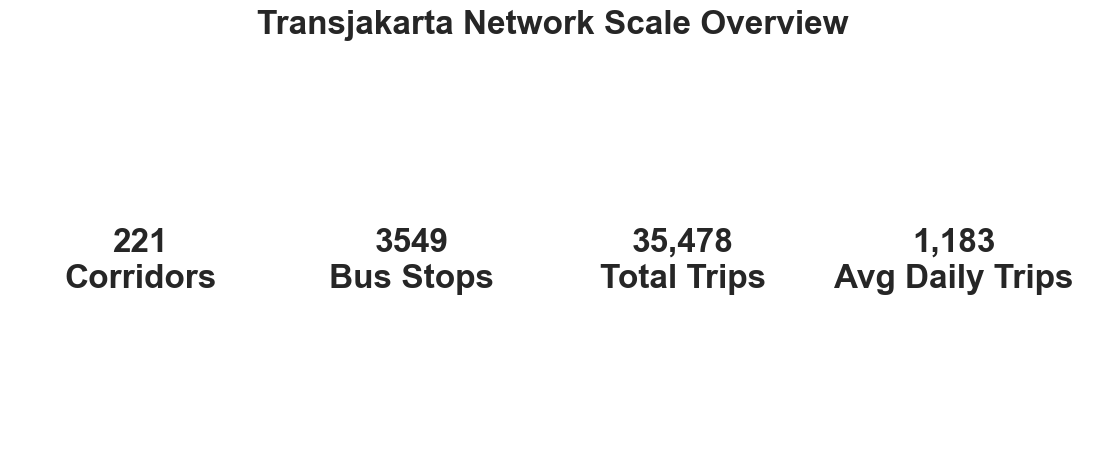

In [44]:
# Total Unique Bus Stops
total_bus_stops = pd.concat([
    df_mapping['tapInStops'],
    df_mapping['tapOutStops']
]).dropna().nunique()

# Total Corridors
total_corridors = (
    df_mapping['corridorID']
    .nunique()
)

# Total Trips
total_trips = len(df_mapping)

# Average Daily Trips
df_mapping['tapInTime'] = pd.to_datetime(
    df_mapping['tapInTime']
)

df_mapping['Date'] = (
    df_mapping['tapInTime'].dt.date
)

daily_trip = (
    df_mapping.groupby('Date')
    .size()
)

average_daily_trips = daily_trip.mean()

# =========================
# NETWORK SCALE OVERVIEW
# =========================

fig, ax = plt.subplots(figsize=(14,5))

ax.axis('off')

plt.title(
    'Transjakarta Network Scale Overview',
    fontsize=24,
    fontweight='bold',
    pad=25
)

# Corridor
ax.text(
    0.12, 0.5,
    f'{total_corridors}\nCorridors',
    ha='center',
    va='center',
    fontsize=24,
    fontweight='bold'
)

# Bus Stops
ax.text(
    0.37, 0.5,
    f'{total_bus_stops}\nBus Stops',
    ha='center',
    va='center',
    fontsize=24,
    fontweight='bold'
)

# Total Trips
ax.text(
    0.62, 0.5,
    f'{total_trips:,.0f}\nTotal Trips',
    ha='center',
    va='center',
    fontsize=24,
    fontweight='bold'
)

# Average Daily Trips
ax.text(
    0.87, 0.5,
    f'{average_daily_trips:,.0f}\nAvg Daily Trips',
    ha='center',
    va='center',
    fontsize=24,
    fontweight='bold'
)

plt.show()

### Koridor dengan Volume Perjalanan Tertinggi

In [45]:
# Hitung volume perjalanan per koridor
koridor_volume = (
    df_mapping.groupby('corridorName')
    .size()
    .reset_index(name='Jumlah Perjalanan')
    .sort_values(by='Jumlah Perjalanan', ascending=False)
)

# Tampilkan hasil
koridor_volume.head(20)

,corridorName,Jumlah Perjalanan
21,Cibubur - Balai Kota,384
33,Ciputat - CSW,376
47,Harmoni - Jakarta International Stadium,333
116,Pulo Gadung - Monas,333
73,Kampung Rambutan - Pondok Gede,327
157,Rusun Pondok Bambu - Walikota Jakarta Timur,323
55,Kalideres - Bundaran HI via Veteran,323
77,Kebayoran Lama - Tanah Abang,321
159,Rusun Rawa Bebek - Kodamar,307
102,Pasar Minggu - Tanah Abang,300


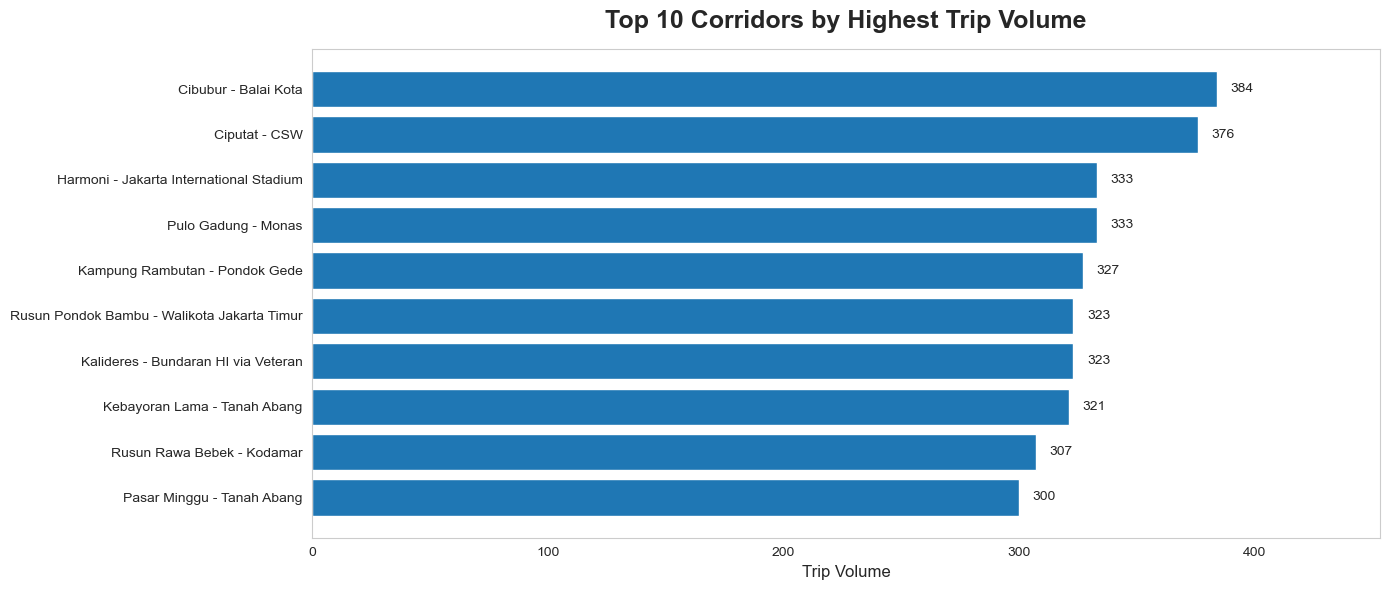

In [46]:
# Ambil top 10 koridor
top_koridor = koridor_volume.head(10)

plt.figure(figsize=(14,6))

bars = plt.barh(
    top_koridor['corridorName'],
    top_koridor['Jumlah Perjalanan']
)

# Label angka
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + (top_koridor['Jumlah Perjalanan'].max() * 0.015),
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',
        va='center',
        fontsize=10
    )

# Koridor terbesar di atas
plt.gca().invert_yaxis()

# Hapus grid
plt.grid(False)

# Judul
plt.title(
    'Top 10 Corridors by Highest Trip Volume',
    fontsize=18,
    fontweight='bold',
    pad=15
)

# Axis label
plt.xlabel('Trip Volume', fontsize=12)
plt.ylabel('')

# Tambah ruang kanan
plt.xlim(
    0,
    top_koridor['Jumlah Perjalanan'].max() * 1.18
)

plt.tight_layout()

plt.show()

Dari data top 10 koridor dengan volume perjalanan tertinggi ini, diketahui bahwa:

1. Koridor dengan volume tertinggi didominasi oleh rute yang menghubungkan kawasan permukiman padat dengan pusat aktivitas dan area transit utama di Jakarta.
2. Koridor Cibubur-Balai Kota dan Ciputat-CSW mencatat volume perjalanan tertinggi, yang menunjukkan tingginya mobilitas urban dari daerah penyangga (di luar Jakarta).
3. Tingginya volume perjalanan pada koridor Ciputat – CSW menjadi menarik untuk dianalisis lebih lanjut, khususnya terkait pola destinasi lanjutan penumpang setelah tiba di kawasan CSW.


## Rekomendasi Rute Baru 

Pada data ini, menarik untuk menggunakan CSW sebagai basis analisis karena merupakan salah satu hub yang paling integrated yaitu terhubung ke MRT dan lokasinya relatif dekat dengan Blok M yang menjadi hub utama untuk koridor TransJakarta.

In [47]:
# Filter perjalanan dari CSW 1 dan CSW 2
csw_trip = df_mapping[
    df_mapping['tapInStopsName'].isin(['CSW 1', 'CSW 2'])
]

# Cari destinasi terbanyak
csw_destination = (
    csw_trip.groupby('tapOutStopsName')
    .size()
    .reset_index(name='Jumlah Perjalanan')
    .sort_values(by='Jumlah Perjalanan', ascending=False)
)

csw_destination.head(10)

,tapOutStopsName,Jumlah Perjalanan
4,Rawa Barat,20
8,Velbak,17
3,Pancoran Barat Arah Timur,7
7,Tendean,2
0,Blok M Jalur 2,1
1,Karet Kuningan,1
2,Kebayoran Lama,1
5,Setiabudi Utara,1
6,Swadarma,1


Diketahui bahwa dari kawasan CSW, penumpang paling banyak melanjutkan perjalanan menuju halte Rawa Barat dan Velbak. Dari kedua tujuan tersebut, rute Ciputat–Velbak menjadi lebih menarik untuk dieksplorasi karena secara geografis Velbak merupakan area konektivitas strategis menuju Jakarta Barat dan Selatan, serta berada pada jalur yang relatif lurus dari kawasan Ciputat.

Saat ini, penumpang dari Ciputat yang ingin menuju Velbak masih perlu melakukan transit di Halte Pondok Indah maupun kawasan CSW. Hal ini menunjukkan adanya kebutuhan mobilitas yang cukup kuat antara wilayah selatan Jakarta dan koridor barat–selatan kota.

Temuan ini membuka potensi pengembangan trayek direct service Ciputat–Velbak untuk mengurangi kebutuhan transit serta meningkatkan efisiensi perjalanan penumpang.

Namun mengingat halte Velbak merupakan halte elevated, sehingga rute Ciputat-Velbak hanya bisa dengan moda non-BRT tanpa berhenti persis di halte yang sudah ada (berhenti di pinggir jalan terdekat).

### Koridor dengan Jumlah Perjalanan Terendah

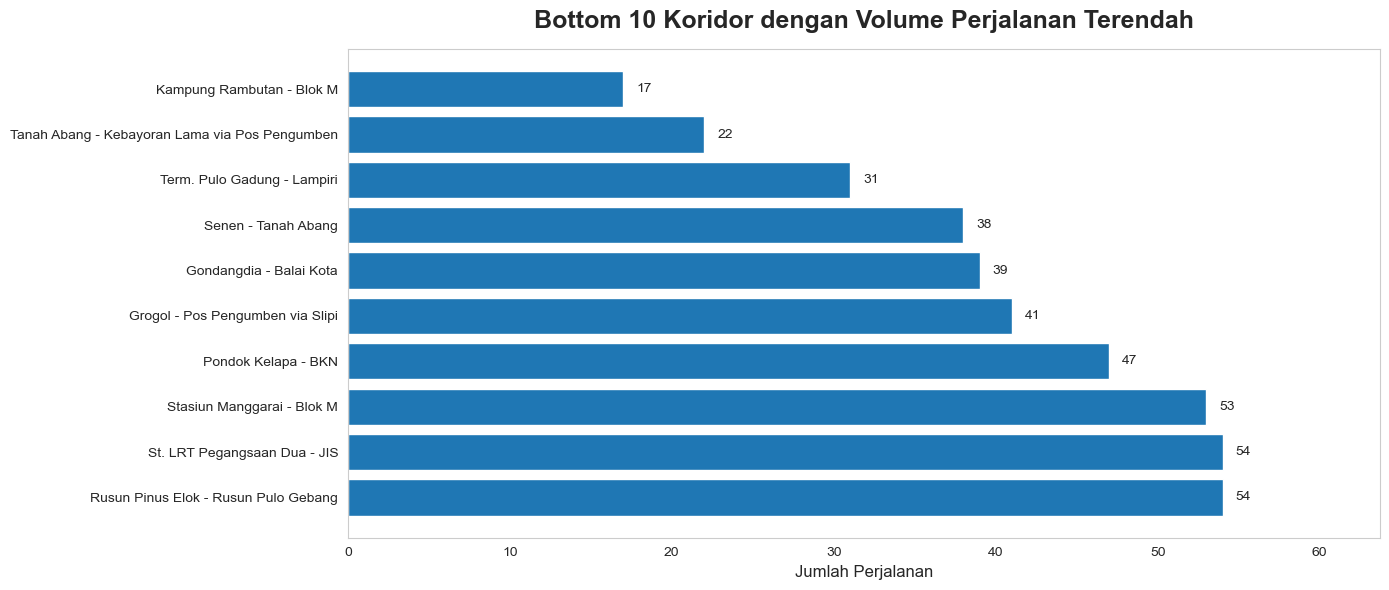

In [48]:
# Ambil 10 koridor dengan volume terendah

bottom_koridor = koridor_volume.sort_values(
    by='Jumlah Perjalanan',
    ascending=True
).head(10)

plt.figure(figsize=(14,6))

bars = plt.barh(
    bottom_koridor['corridorName'],
    bottom_koridor['Jumlah Perjalanan']
)

# Label angka
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + (bottom_koridor['Jumlah Perjalanan'].max() * 0.015),
        bar.get_y() + bar.get_height()/2,
        f'{int(width):,}',
        va='center',
        fontsize=10
    )

# Koridor terkecil di atas
plt.gca().invert_yaxis()

# Hapus grid
plt.grid(False)

# Judul
plt.title(
    'Bottom 10 Koridor dengan Volume Perjalanan Terendah',
    fontsize=18,
    fontweight='bold',
    pad=15
)

# Axis label
plt.xlabel('Jumlah Perjalanan', fontsize=12)
plt.ylabel('')

# Tambah ruang kanan
plt.xlim(
    0,
    bottom_koridor['Jumlah Perjalanan'].max() * 1.18
)

plt.tight_layout()

plt.show()

Koridor-koridor di atas tergolong memiliki demand penumpang yang masih rendah dan belum membutuhkan kapasitas armada besar secara optimal. Temuan ini membuka peluang untuk evaluasi operasional dengan menggunakan armads yang kapasitasnya lebih kecil, penyesuaian headway antar bus atau optimalisasi rute.

## Halte Tersibuk

In [49]:
# Top 10 halte tap in terbanyak
top_tapin = (
    df_mapping.groupby('tapInStopsName')
    .size()
    .reset_index(name='Jumlah Tap In')
    .sort_values(by='Jumlah Tap In', ascending=False)
)

top_tapin.head(10)

,tapInStopsName,Jumlah Tap In
1258,Penjaringan,229
270,Garuda Taman Mini,198
52,BKN,159
58,BNN LRT,145
1239,Pejaten,144
1568,Rusun Kapuk Muara,125
1255,Penggilingan,125
2430,Tendean,120
2133,Seskoal,120
165,Cibubur Junction,120


In [50]:
# Top 10 halte tap out terbanyak
top_tapout = (
    df_mapping.groupby('tapOutStopsName')
    .size()
    .reset_index(name='Jumlah Tap Out')
    .sort_values(by='Jumlah Tap Out', ascending=False)
)

top_tapout.head(10)

,tapOutStopsName,Jumlah Tap Out
42,BKN,302
1096,Penjaringan,264
2135,Term. Senen,188
2126,Term. Kampung Rambutan,158
999,Monas,158
781,Kejaksaan Agung,155
1329,Ragunan,145
1140,Pinang Ranti,142
852,Kota Kasablanka,129
1160,Pluit,128


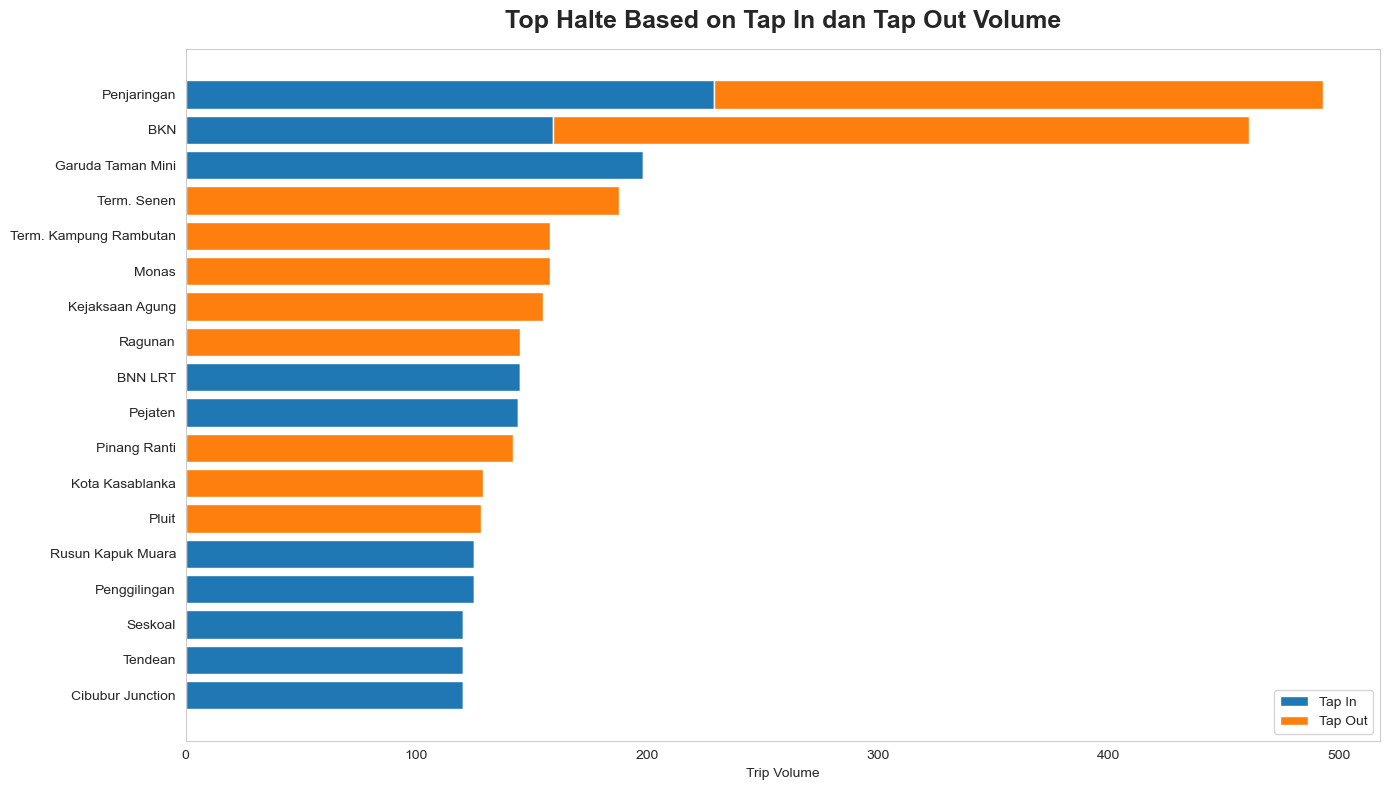

In [51]:
# Top Tap In
top_tapin = (
    df_mapping.groupby('tapInStopsName')
    .size()
    .reset_index(name='TapIn')
    .sort_values(by='TapIn', ascending=False)
    .head(10)
)

# Top Tap Out
top_tapout = (
    df_mapping.groupby('tapOutStopsName')
    .size()
    .reset_index(name='TapOut')
    .sort_values(by='TapOut', ascending=False)
    .head(10)
)

# Rename nama halte
top_tapin = top_tapin.rename(
    columns={'tapInStopsName':'Halte'}
)

top_tapout = top_tapout.rename(
    columns={'tapOutStopsName':'Halte'}
)

# Merge
gabungan = pd.merge(
    top_tapin,
    top_tapout,
    on='Halte',
    how='outer'
).fillna(0)

# Total aktivitas
gabungan['Total'] = (
    gabungan['TapIn'] +
    gabungan['TapOut']
)

# Urutkan
gabungan = gabungan.sort_values(
    by='Total',
    ascending=True
)

# Plot
plt.figure(figsize=(14,8))

plt.barh(
    gabungan['Halte'],
    gabungan['TapIn'],
    label='Tap In'
)

plt.barh(
    gabungan['Halte'],
    gabungan['TapOut'],
    left=gabungan['TapIn'],
    label='Tap Out'
)

# Judul
plt.title(
    'Top Halte Based on Tap In dan Tap Out Volume',
    fontsize=18,
    fontweight='bold',
    pad=15
)

plt.xlabel('Trip Volume')
plt.ylabel('')

plt.legend()

plt.grid(False)

plt.tight_layout()

plt.show()

In [52]:
# Hitung tap in
tapin = (
    df.groupby('tapInStopsName')
    .size()
    .reset_index(name='Tap In')
)

# Hitung tap out
tapout = (
    df.groupby('tapOutStopsName')
    .size()
    .reset_index(name='Tap Out')
)

# Gabungkan
hub_halte = tapin.merge(
    tapout,
    left_on='tapInStopsName',
    right_on='tapOutStopsName',
    how='outer'
)

# Rapihin
hub_halte['Halte'] = hub_halte['tapInStopsName'].fillna(
    hub_halte['tapOutStopsName']
)

hub_halte = hub_halte[['Halte','Tap In','Tap Out']]

hub_halte = hub_halte.fillna(0)

# Total aktivitas
hub_halte['Total Aktivitas'] = (
    hub_halte['Tap In'] +
    hub_halte['Tap Out']
)

# Ranking
hub_halte = hub_halte.sort_values(
    by='Total Aktivitas',
    ascending=False
)

hub_halte.head(10)

,Halte,Tap In,Tap Out,Total Aktivitas
1782,Penjaringan,243.0,265.0,508.0
71,BKN,173.0,316.0,489.0
77,BNN LRT,155.0,110.0,265.0
211,Cibubur Junction,133.0,129.0,262.0
3485,Tendean,126.0,131.0,257.0
2212,Rusun Kapuk Muara,131.0,117.0,248.0
1282,Kejaksaan Agung,85.0,159.0,244.0
1779,Penggilingan,130.0,111.0,241.0
352,Garuda Taman Mini,208.0,32.0,240.0
1639,Monas,58.0,167.0,225.0


Halte Penjaringan dan BKN menunjukkan potensi sebagai hub mobilitas karena memiliki volume pergerakan penumpang yang tinggi. BKN berpotensi melayani mobilitas komuter area Jakarta Timur sementara Penjaringan berpotensi sebagai hub kawasan Jakarta Utara.

In [53]:
# Cek Halte yang Paling Banyak Dilewati Koridor TJ

hub_koridor = (
    df.groupby('tapInStopsName')['corridorName']
    .nunique()
    .reset_index(name='Jumlah Koridor')
    .sort_values(by='Jumlah Koridor', ascending=False)
)

hub_koridor.head(10)

,tapInStopsName,Jumlah Koridor
58,BNN LRT,10
907,Kejaksaan Agung,8
1704,SMK 57,7
52,BKN,7
1171,Monas,7
55,BNN Arah Barat,7
995,Kuningan Madya,7
473,Jelambar,7
1577,Rawa Barat,7
805,Jln. Taman Jatibaru Timur,7


Sehingga, dari data ini yang memungkinkan untuk lebih baik dijadikan halte hub adalah BKN.

## Pola Commuting Berdasarkan Gender

In [54]:
# Hitung jumlah trip berdasarkan gender
gender_trip = (
    df_mapping.groupby('payCardSex')
    .size()
    .reset_index(name='Jumlah Trip')
    .sort_values(by='Jumlah Trip', ascending=False)
)

gender_trip

,payCardSex,Jumlah Trip
0,F,18875
1,M,16603


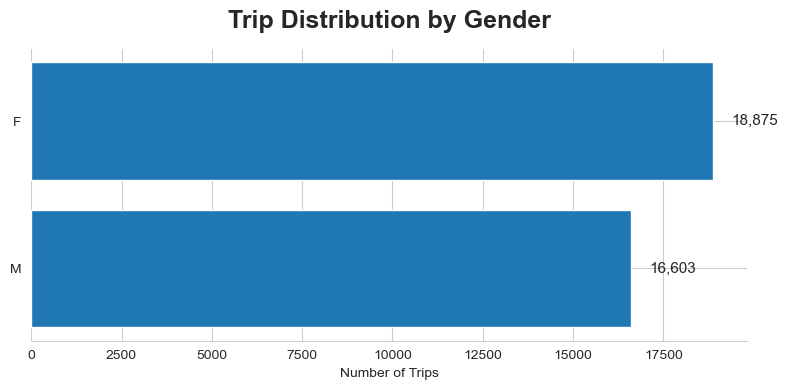

In [55]:
gender_trip_sorted = gender_trip.sort_values(
    by='Jumlah Trip',
    ascending=True
)

plt.figure(figsize=(8,4), facecolor='white')

bars = plt.barh(
    gender_trip_sorted['payCardSex'],
    gender_trip_sorted['Jumlah Trip']
)

plt.title(
    'Trip Distribution by Gender',
    fontsize=18,
    weight='bold',
    pad=15
)

plt.xlabel('Number of Trips')
plt.ylabel('')

# Remove spines
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Value labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + 500,
        bar.get_y() + bar.get_height()/2,
        f'{width:,.0f}',
        va='center',
        fontsize=11
    )

plt.tight_layout()
plt.show()

## Durasi Perjalanan

In [56]:
# Hitung durasi perjalanan
df_mapping['durasi_perjalanan'] = (
    df_mapping['tapOutTime'] - df_mapping['tapInTime']
).dt.total_seconds() / 60

# Ubah ke menit
df_mapping['durasi_perjalanan'] = df_mapping['durasi_perjalanan'].round(1)

# Rata-rata durasi perjalanan (menit)
rata_durasi = df_mapping['durasi_perjalanan'].mean()

print(f'Rata-rata durasi perjalanan: {rata_durasi:.1f} menit')

Rata-rata durasi perjalanan: 72.2 menit


## Klasifikasi Jenis Layanan

In [57]:
def classify_corridor(corridor, payamount):
    corridor = str(corridor)

    # Royal Trans
    if payamount == 20000:
        return 'Royal Trans'

    # Mikrotrans
    elif corridor.startswith('JAK'):
        return 'Mikrotrans'

    # Bus Wisata
    elif corridor.startswith('BW'):
        return 'Bus Wisata'

    # JIS Shuttle
    elif corridor.startswith('JIS'):
        return 'JIS Shuttle'

    # Express Service 
    elif corridor.startswith('L'):
        return 'Angkutan Express'

    # Rusun Service
    elif corridor.startswith('R'):
        return 'Angkutan Rusun'

    # Night Service 
    elif corridor.startswith('M'):
        return 'Night Service dari Koridor Utama'
        
    # Non-BRT Jabodetabek
    elif corridor.startswith(('B', 'D', 'P', 'S', 'T', 'SH')):
        return 'Non-BRT Jabodetabek'

    # BRT Utama
    elif corridor.isdigit():
        return 'BRT Utama'
     
    # BRT Lintas Koridor / Feeder
    elif any(char.isalpha() for char in corridor):
        return 'BRT Lintas Koridor / Feeder'

    else:
        return 'Lainnya'


# Agar tidak mengubah dataframe asli
df_mapping = df_mapping.copy()

# Buat kolom service category
df_mapping['serviceCategory'] = df_mapping.apply(
    lambda row: classify_corridor(
        row['corridorID'],
        row['payAmount']
    ),
    axis=1
)

# Summary layanan
service_summary = (
    df_mapping.groupby('serviceCategory')
    .agg(
        Jumlah_Trip=('serviceCategory', 'size'),
        Jumlah_Koridor=('corridorID', 'nunique')
    )
    .reset_index()
)

# Rename kolom
service_summary.columns = [
    'Kategori Layanan',
    'Jumlah Trip',
    'Jumlah Koridor'
]

# Hitung persentase trip
service_summary['Persentase Jumlah Trip (%)'] = (
    service_summary['Jumlah Trip']
    / service_summary['Jumlah Trip'].sum()
    * 100
).round(2)

# Sort
service_summary = service_summary.sort_values(
    by='Jumlah Trip',
    ascending=False
).reset_index(drop=True)

# Index mulai dari 1
service_summary.index = service_summary.index + 1

# Tampilkan tabel
service_summary

,Kategori Layanan,Jumlah Trip,Jumlah Koridor,Persentase Jumlah Trip (%)
1,BRT Lintas Koridor / Feeder,13777,89,38.83
2,Mikrotrans,13009,81,36.67
3,BRT Utama,2573,14,7.25
4,Night Service dari Koridor Utama,2047,15,5.77
5,Royal Trans,1646,10,4.64
6,Non-BRT Jabodetabek,1492,8,4.21
7,JIS Shuttle,333,1,0.94
8,Bus Wisata,209,1,0.59
9,Angkutan Express,196,1,0.55
10,Angkutan Rusun,196,1,0.55


Dari distribusi trip berdasarkan kategori layanan, diketahui bahwa Transjakarta memiliki jenis layanan yang cukup beragam untuk melayani kebutuhan mobilitas masyarakat Jakarta. Layanan tersebut mencakup BRT utama, feeder lintas koridor, Mikrotrans, hingga layanan khusus seperti Royal Trans, Bus Wisata, dan Night Service.

Data menunjukkan bahwa perjalanan penumpang didominasi oleh layanan BRT Lintas Koridor/Feeder dan Mikrotrans.

In [58]:
service_routes = (
    df_mapping.groupby('serviceCategory')['corridorID']
    .unique()
    .reset_index()
)

service_routes['List Koridor'] = (
    service_routes['corridorID']
    .apply(lambda x: ', '.join(sorted(map(str, x))))
)

for i, row in service_routes.iterrows():

    print('=' * 80)
    print(f"Kategori Layanan : {row['serviceCategory']}")
    print('-' * 80)
    print(row['List Koridor'])

Kategori Layanan : Angkutan Express
--------------------------------------------------------------------------------
L13E
Kategori Layanan : Angkutan Rusun
--------------------------------------------------------------------------------
R1A
Kategori Layanan : BRT Lintas Koridor / Feeder
--------------------------------------------------------------------------------
10A, 10B, 10D, 10H, 10K, 11B, 11C, 11D, 11K, 11M, 11N, 11P, 11Q, 12A, 12B, 12C, 12F, 12H, 12P, 13B, 13C, 13D, 1A, 1B, 1C, 1E, 1F, 1H, 1M, 1N, 1P, 1Q, 1R, 2A, 2B, 2E, 2F, 2H, 2P, 2Q, 3A, 3B, 3C, 3E, 3F, 3H, 4B, 4C, 4D, 4E, 4F, 5B, 5C, 5D, 5F, 5M, 5N, 6A, 6B, 6C, 6D, 6H, 6M, 6N, 6Q, 6T, 6U, 6V, 7A, 7B, 7C, 7D, 7E, 7F, 7P, 7Q, 8A, 8C, 8D, 8E, 8K, 8M, 9A, 9C, 9D, 9E, 9F, 9H, 9N
Kategori Layanan : BRT Utama
--------------------------------------------------------------------------------
1, 10, 11, 12, 13, 14, 2, 3, 4, 5, 6, 7, 8, 9
Kategori Layanan : Bus Wisata
--------------------------------------------------------------------

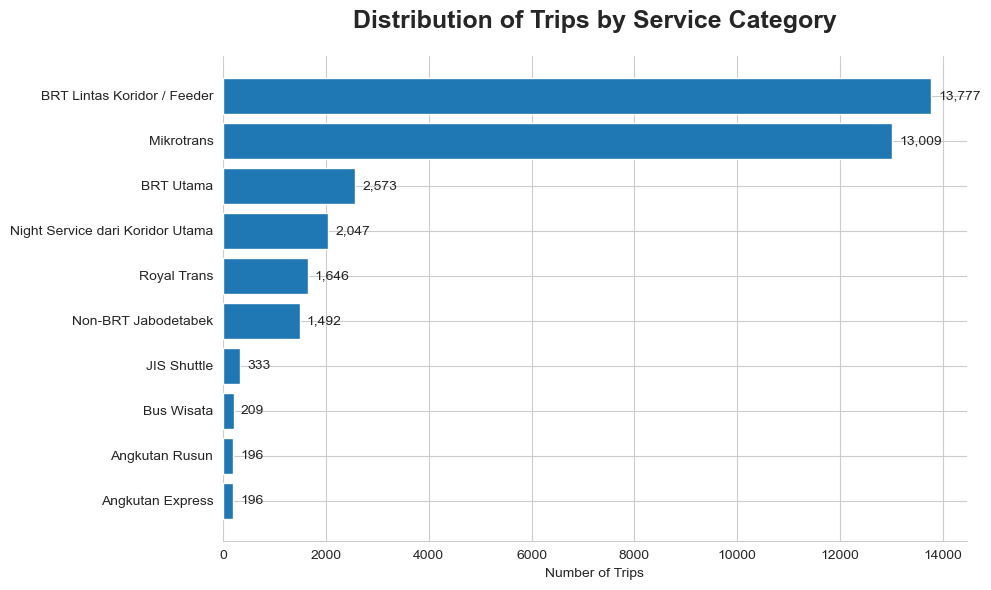

In [59]:
# Sort data
plot_data = service_summary.sort_values(
    by='Jumlah Trip',
    ascending=True
)

# Bar Chart
plt.figure(figsize=(10, 6), facecolor='white')

bars = plt.barh(
    plot_data['Kategori Layanan'],
    plot_data['Jumlah Trip']
)

# Title
plt.title(
    'Distribution of Trips by Service Category',
    fontsize=18,
    weight='bold',
    pad=20
)

plt.xlabel('Number of Trips')
plt.ylabel('')

# Remove spines
ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Value labels
for bar in bars:
    width = bar.get_width()

    plt.text(
        width + (plot_data['Jumlah Trip'].max() * 0.01),
        bar.get_y() + bar.get_height()/2,
        f'{width:,.0f}',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()

Dari grafik di atas, diketahui perjalanan didominasi oleh layanan BRT Lintas Koridor/Feeder dan Mikrotrans yang menunjukkan pentingnya bus penyangga koridor utama BRT untuk menjamin konektivitas sistem transportasi publik Jakarta. Data ini juga menunjukkan memang diperlukaannya transportasi penunjang publik untuk kemudahan mobilitas ke area yang dituju.

In [60]:
# Top 3 koridor BRT Lintas Koridor / Feeder
top_feeder = (
    df_mapping[
        df_mapping['serviceCategory']
        == 'BRT Lintas Koridor / Feeder'
    ]
    .groupby(['corridorID', 'corridorName'])
    .size()
    .reset_index(name='Jumlah Trip')
    .sort_values(
        by='Jumlah Trip',
        ascending=False
    )
    .head(3)
)

print("Top 3 BRT Lintas Koridor / Feeder")
display(top_feeder)

# Top 3 koridor Mikrotrans
top_mikrotrans = (
    df_mapping[
        df_mapping['serviceCategory']
        == 'Mikrotrans'
    ]
    .groupby(['corridorID', 'corridorName'])
    .size()
    .reset_index(name='Jumlah Trip')
    .sort_values(
        by='Jumlah Trip',
        ascending=False
    )
    .head(3)
)

print("Top 3 Mikrotrans")
display(top_mikrotrans)

Top 3 BRT Lintas Koridor / Feeder


,corridorID,corridorName,Jumlah Trip
11,11P,Rusun Pondok Bambu - Walikota Jakarta Timur,323
77,8C,Kebayoran Lama - Tanah Abang,321
35,2E,Rusun Rawa Bebek - Kodamar,307


Top 3 Mikrotrans


,corridorID,corridorName,Jumlah Trip
5,JAK.06,Kampung Rambutan - Pondok Gede,327
70,JAK.72,Kampung Rambutan - Pasar Rebo via Poncol,292
48,JAK.42,Kampung Melayu - Pondok Kelapa,282


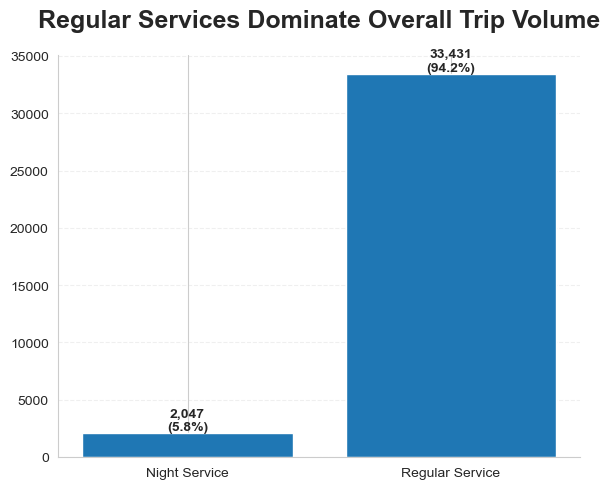

In [61]:
trip_comparison = (
    df_mapping.groupby('serviceCategory')
    .size()
    .reset_index(name='Jumlah Trip')
)

trip_comparison['Kategori'] = trip_comparison[
    'serviceCategory'
].apply(
    lambda x:
    'Night Service'
    if x == 'Night Service dari Koridor Utama'
    else 'Regular Service'
)

summary = (
    trip_comparison.groupby('Kategori')['Jumlah Trip']
    .sum()
    .reset_index()
)

# Percentage
total_trip = summary['Jumlah Trip'].sum()

summary['Percentage'] = (
    summary['Jumlah Trip'] / total_trip * 100
)

plt.figure(figsize=(6,5), facecolor='white')

bars = plt.bar(
    summary['Kategori'],
    summary['Jumlah Trip']
)

plt.title(
    'Regular Services Dominate Overall Trip Volume',
    fontsize=18,
    weight='bold',
    pad=20
)

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

# Value labels + percentage
for i, bar in enumerate(bars):

    height = bar.get_height()

    percentage = summary.loc[i, 'Percentage']

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{int(height):,}\n({percentage:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

In [62]:
### Perbandingan Jumlah Trip Regular & Night Service

# Regular Trip Koridor Utama
regular_trip = (
    df_mapping[
        df_mapping['corridorID'].astype(str).str.isdigit()
    ]
    .groupby('corridorID')
    .size()
    .reset_index(name='Regular Trip')
)

# Night Trip Koridor Utama
night_trip = (
    df_mapping[
        df_mapping['corridorID'].astype(str).str.startswith('M')
    ]
    .groupby('corridorID')
    .size()
    .reset_index(name='Night Trip')
)

# Hilangkan huruf M agar cocok dengan regular corridor
night_trip['corridorID'] = (
    night_trip['corridorID']
    .str.replace('M', '', regex=False)
)

# Gabungkan
comparison = pd.merge(
    regular_trip,
    night_trip,
    on='corridorID',
    how='left'
)

# Isi missing value
comparison = comparison.fillna(0)

# Ubah tipe data
comparison['Night Trip'] = (
    comparison['Night Trip']
    .astype(int)
)

# Rapihkan index
comparison = comparison.reset_index(drop=True)

comparison.index = comparison.index + 1

# Tampilkan hasil
print("Comparison Regular vs Night Trip BRT")

comparison.style.hide(axis='index')

Comparison Regular vs Night Trip BRT


corridorID,Regular Trip,Night Trip
1,228,60
10,99,252
11,123,123
12,250,92
13,236,244
14,208,0
2,275,58
3,123,200
4,191,106
5,245,15


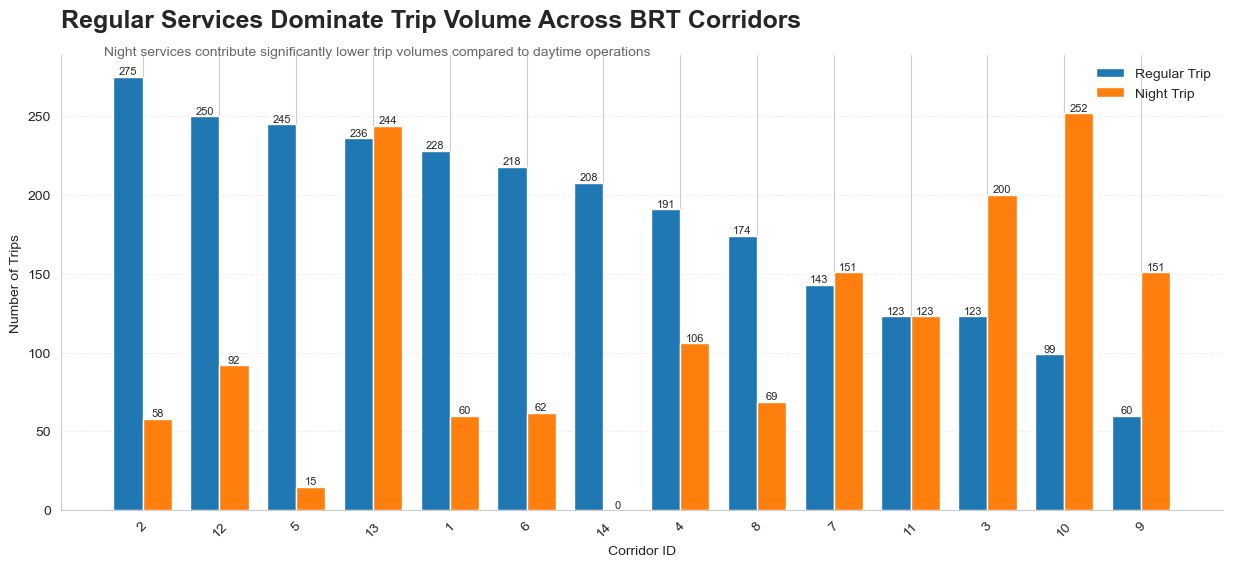

In [63]:
# Graph untuk Regular vs Night Trip

comparison = pd.merge(
    regular_trip,
    night_trip,
    on='corridorID',
    how='left'
).fillna(0)

# Convert data type
comparison['Night Trip'] = (
    comparison['Night Trip']
    .astype(int)
)

# Sort by regular trip volume
comparison = comparison.sort_values(
    by='Regular Trip',
    ascending=False
)

# X-axis position
x = np.arange(len(comparison))
width = 0.38

# Figure
fig, ax = plt.subplots(
    figsize=(15,7),
    facecolor='white'
)

# Bars
regular_bar = ax.bar(
    x - width/2,
    comparison['Regular Trip'],
    width,
    label='Regular Trip'
)

night_bar = ax.bar(
    x + width/2,
    comparison['Night Trip'],
    width,
    label='Night Trip'
)

# Title
ax.set_title(
    'Regular Services Dominate Trip Volume Across BRT Corridors',
    fontsize=18,
    weight='bold',
    loc='left',
    pad=20
)

# Subtitle
plt.text(
    -0.5,
    comparison['Regular Trip'].max() * 1.05,
    'Night services contribute significantly lower trip volumes compared to daytime operations',
    fontsize=10,
    alpha=0.7
)

# Labels
ax.set_xlabel('Corridor ID')
ax.set_ylabel('Number of Trips')

# X ticks
ax.set_xticks(x)

ax.set_xticklabels(
    comparison['corridorID'],
    rotation=45
)

# Clean style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Grid
ax.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

# Legend
ax.legend(frameon=False)

# Value labels - Regular
for i, v in enumerate(comparison['Regular Trip']):
    ax.text(
        i - width/2,
        v + (comparison['Regular Trip'].max() * 0.005),
        f'{int(v):,}',
        ha='center',
        fontsize=8
    )

# Value labels - Night
for i, v in enumerate(comparison['Night Trip']):
    ax.text(
        i + width/2,
        v + (comparison['Regular Trip'].max() * 0.005),
        f'{int(v):,}',
        ha='center',
        fontsize=8
    )

# Layout
plt.subplots_adjust(
    top=0.85,
    bottom=0.2
)

plt.show()

Dengan membagi trip rute BRT berdasarkan koridornya, diketahui bahwa sebagian besar penumpang menggunakan moda di siang hari. Adapun hanya beberapa koridor yang dominan digunakan pada perjalanan malam hari, dengan paling signifikasn koridor 10. Hal ini menyiratkan terkait adanya kebutuhan koridor pada malam hari dan perlu langkah strategis untuk menunjang hal tersebut.

In [64]:
df_mapping['tapInHour'] = df_mapping['tapInTime'].dt.hour

# Buat kategori hari
df_mapping['dayType'] = (
    df_mapping['tapInTime']
    .dt.dayofweek
    .apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
)

# Aggregasi
weekday_weekend = (
    df_mapping
    .groupby(['dayType', 'tapInHour'])
    .size()
    .reset_index(name='Total Trips')
)

weekday_weekend

,dayType,tapInHour,Total Trips
0,Weekday,5,2924
1,Weekday,6,5264
2,Weekday,7,2413
3,Weekday,8,2484
4,Weekday,9,2443
5,Weekday,10,97
6,Weekday,11,133
7,Weekday,12,112
8,Weekday,13,124
9,Weekday,14,8


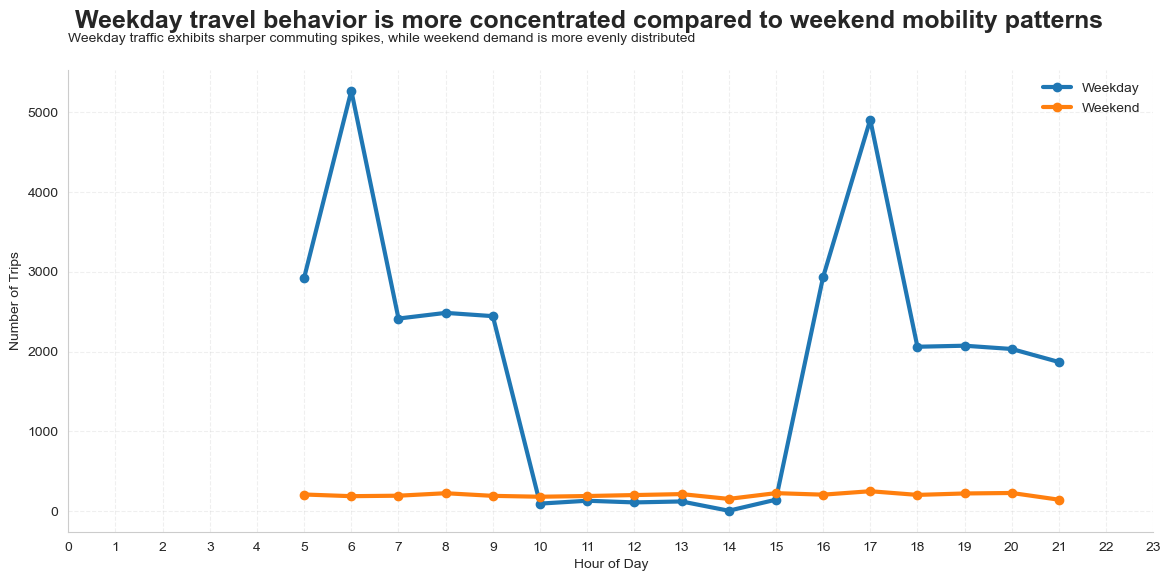

In [65]:
# Plot
plt.figure(figsize=(14,6))

for day in ['Weekday', 'Weekend']:
    
    subset = weekday_weekend[
        weekday_weekend['dayType'] == day
    ]
    
    plt.plot(
        subset['tapInHour'],
        subset['Total Trips'],
        marker='o',
        linewidth=3,
        label=day
    )

plt.xticks(range(24))

plt.suptitle(
    'Weekday travel behavior is more concentrated compared to weekend mobility patterns',
    fontsize=18,
    fontweight='bold',
    x=0.13,
    ha='left'
)

plt.title(
    'Weekday traffic exhibits sharper commuting spikes, while weekend demand is more evenly distributed',
    fontsize=10,
    loc='left',
    pad=20
)

plt.xlabel('Hour of Day')
plt.ylabel('Number of Trips')

plt.legend(frameon=False)

sns.despine()

plt.grid(
    linestyle='--',
    alpha=0.3
)

plt.show()

In [66]:
# Buat kategori weekday/weekend
df_mapping['dayType'] = (
    df_mapping['tapInTime']
    .dt.dayofweek
    .apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')
)

# Hitung trip per halte tujuan
halte_load = (
    df_mapping
    .groupby(['tapOutStopsName', 'dayType'])
    .size()
    .reset_index(name='Total Trips')
)

# Pivot weekday vs weekend
halte_compare = (
    halte_load
    .pivot_table(
        index='tapOutStopsName',
        columns='dayType',
        values='Total Trips',
        fill_value=0
    )
)

# Total trip
halte_compare['Total'] = (
    halte_compare['Weekday'] +
    halte_compare['Weekend']
)

# Top 3 halte
top3_halte = (
    halte_compare
    .sort_values(by='Total', ascending=False)
    .head(3)
)

top3_halte

dayType,Weekday,Weekend,Total
tapOutStopsName,,,
BKN,290.0,12.0,302.0
Penjaringan,242.0,22.0,264.0
Term. Senen,176.0,12.0,188.0


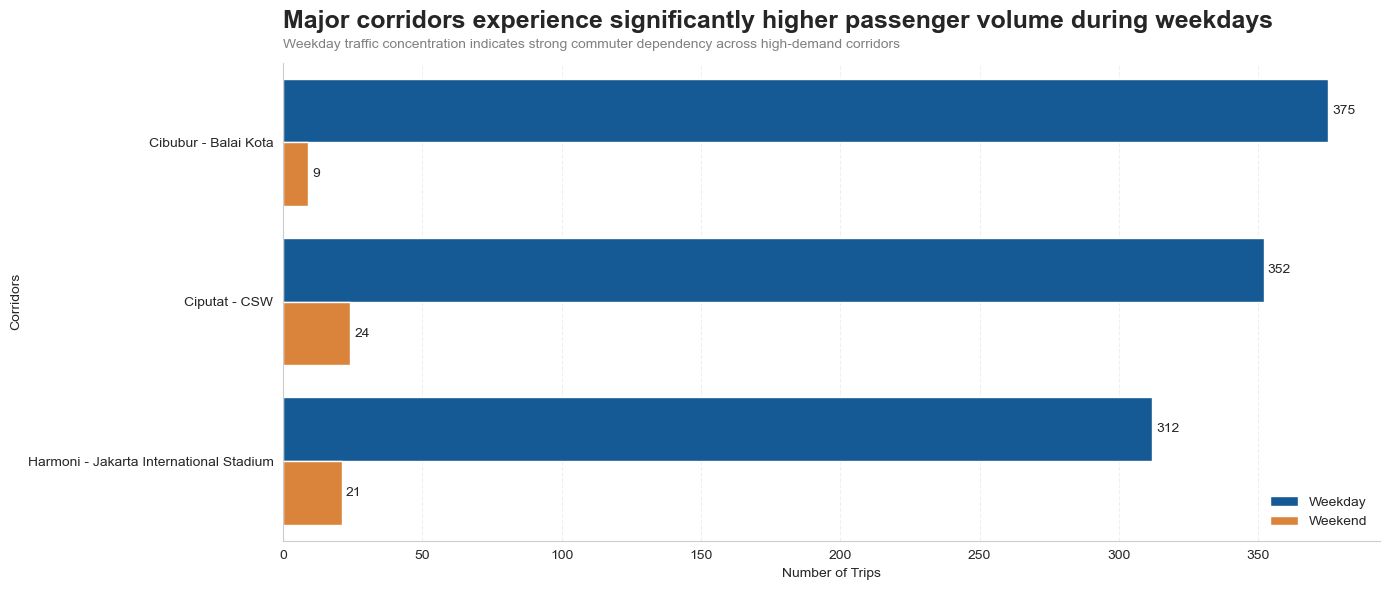

In [67]:
corridor_total = (
    df_mapping
    .groupby('corridorName')
    .size()
    .reset_index(name='Total Trips')
)

top3_corridors = (
    corridor_total
    .sort_values(by='Total Trips', ascending=False)
    .head(3)['corridorName']
)

corridor_compare = (
    df_mapping[
        df_mapping['corridorName'].isin(top3_corridors)
    ]
    .groupby(['corridorName', 'dayType'])
    .size()
    .reset_index(name='Trips')
)

plt.figure(figsize=(14,6))

ax = sns.barplot(
    data=corridor_compare,
    y='corridorName',
    x='Trips',
    hue='dayType',
    palette=['#005BAA', '#F58220']
)

plt.title(
    'Major corridors experience significantly higher passenger volume during weekdays',
    fontsize=18,
    fontweight='bold',
    loc='left',
    pad=25
)

plt.text(
    0,
    1.03,
    'Weekday traffic concentration indicates strong commuter dependency across high-demand corridors',
    transform=ax.transAxes,
    fontsize=10,
    color='gray'
)

plt.xlabel('Number of Trips')
plt.ylabel('Corridors')

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

sns.despine()

for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.legend(
    title='',
    frameon=False,
    loc='lower right'
)

plt.tight_layout()

plt.show()

## Peak Hour Traffic Analysis

Analisis ini dilakukan untuk mengidentfikasi distribusi traffic penumpang TransJakarta berdasarkan jam operasional. Analisis ini dilakukan untuk membantu mengidentfiikasi peak hour sebagai dasar penyesuaian kapasitas layanan maupun penambahan armada pada koridor tertentu.

In [68]:
# Membuat kolom jam perjalanan

df_mapping['tapInHour'] = (
    df_mapping['tapInTime']
    .dt.hour
)

df_mapping.head(10)

,transID,payCardID,payCardBank,payCardName,payCardSex,payCardBirthDate,corridorID,corridorName,direction,tapInStops,...,stopEndSeq,tapOutTime,payAmount,age,Date,tripStatus,durasi_perjalanan,serviceCategory,tapInHour,dayType
0,EIIW227B8L34VB,180062659848800,emoney,Bajragin Usada,M,2008,5,Matraman Baru - Ancol,1.0,P00142,...,12.0,2023-04-03 06:00:53,3500.0,15,2023-04-03,Complete,39.2,BRT Utama,5,Weekday
1,LGXO740D2N47GZ,4885331907664776,dki,Gandi Widodo,F,1997,6C,Stasiun Tebet - Karet via Patra Kuningan,0.0,B01963P,...,21.0,2023-04-03 06:40:01,3500.0,26,2023-04-03,Complete,57.3,BRT Lintas Koridor / Feeder,5,Weekday
2,DJWR385V2U57TO,4996225095064169,dki,Emong Wastuti,F,1992,R1A,Pantai Maju - Kota,0.0,B00499P,...,39.0,2023-04-03 06:50:55,3500.0,31,2023-04-03,Complete,51.8,Angkutan Rusun,5,Weekday
3,JTUZ800U7C86EH,639099174703,flazz,Surya Wacana,F,1978,11D,Pulo Gebang - Pulo Gadung 2 via PIK,0.0,B05587P,...,29.0,2023-04-03 06:28:16,3500.0,45,2023-04-03,Complete,43.4,BRT Lintas Koridor / Feeder,5,Weekday
4,VMLO535V7F95NJ,570928206772,flazz,Embuh Mardhiyah,M,1982,12,Tanjung Priok - Pluit,0.0,P00239,...,15.0,2023-04-03 06:57:03,3500.0,41,2023-04-03,Complete,39.5,BRT Utama,6,Weekday
5,DDES630K2F80KC,2251412124634980,dki,Tirta Siregar,F,1993,1T,Cibubur - Balai Kota,0.0,B00127P,...,6.0,2023-04-03 05:52:25,20000.0,30,2023-04-03,Complete,44.4,Royal Trans,5,Weekday
8,OIHS248V7S72EB,6510013988638519,dki,"Cagak Maheswara, S.Sos",F,1992,B14,Bekasi Barat - Kuningan,1.0,B00795P,...,16.0,2023-04-03 06:51:12,20000.0,31,2023-04-03,Complete,49.5,Royal Trans,6,Weekday
9,ERXO372B2H63RB,3580401035990896,dki,"T. Dadap Pradana, M.Ak",M,2004,1Q,Rempoa - Blok M,0.0,B05781P,...,24.0,2023-04-03 06:51:12,3500.0,19,2023-04-03,Complete,53.4,BRT Lintas Koridor / Feeder,5,Weekday
10,CLWK627W2M22WO,5541851157087967,dki,"Oskar Widiastuti, S.Farm",F,1997,5M,Kampung Melayu - Tanah Abang via Cikini,1.0,B05433P,...,23.0,2023-04-03 07:23:54,3500.0,26,2023-04-03,Complete,51.4,BRT Lintas Koridor / Feeder,6,Weekday
11,IIEK980X1O23NZ,347204308990092,emoney,R.M. Labuh Laksmiwati,F,1984,M7B,BKN - Blok M,1.0,P00254,...,14.0,2023-04-03 06:50:21,NaN,39,2023-04-03,Complete,28.2,Night Service dari Koridor Utama,6,Weekday


In [69]:
# Menghitung Traffic per Jam

traffic_per_hour = (
    df_mapping
    .groupby('tapInHour')
    .size()
    .reset_index(name='jumlahTransaksi')
)

traffic_per_hour

,tapInHour,jumlahTransaksi
0,5,3135
1,6,5454
2,7,2609
3,8,2711
4,9,2637
5,10,280
6,11,325
7,12,316
8,13,340
9,14,164


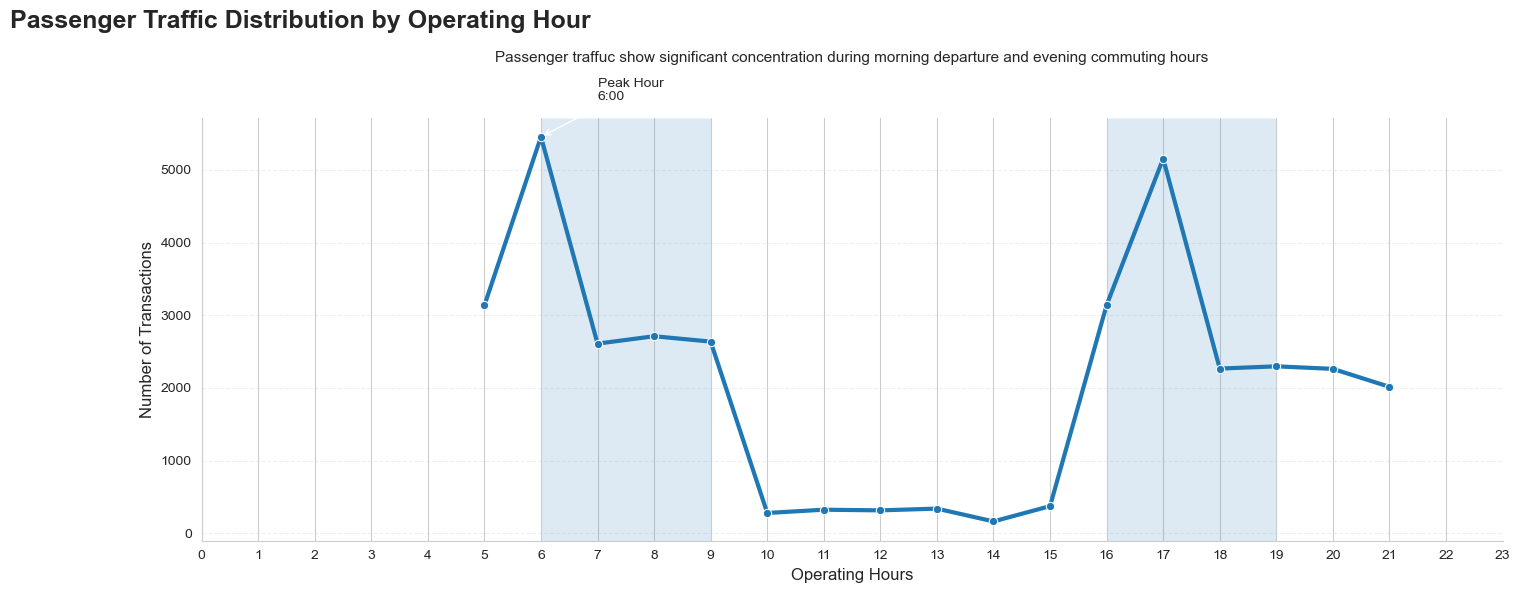

In [70]:
## Visualisasi Peak Hour Traffic Penumpang

plt.figure(figsize=(14,6))

ax = sns.lineplot(
    data = traffic_per_hour,
    x = 'tapInHour',
    y = 'jumlahTransaksi',
    linewidth = 3,
    marker = 'o'
)

# Highlight peak periods
plt.axvspan(6, 9, alpha=0.15)
plt.axvspan(16, 19, alpha=0.15)

# Title & subtitle style
plt.suptitle(
    'Passenger Traffic Distribution by Operating Hour',
    fontsize = 18,
    fontweight = 'bold',
    x = 0.125,
    ha = 'center'
)

plt.title(
    'Passenger traffuc show significant concentration during morning departure and evening commuting hours',
    fontsize = 11,
    loc = 'center',
    pad = 40
)

# Axis labels
plt.xlabel('Operating Hours', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)

# Ticks
plt.xticks(range(0,24))

# Remove top/right borders
sns.despine()

# Grid minimalis
plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

# Annotate peak value
peak_idx = traffic_per_hour['jumlahTransaksi'].idxmax()

peak_hour = traffic_per_hour.loc[peak_idx, 'tapInHour']
peak_value = traffic_per_hour.loc[peak_idx, 'jumlahTransaksi']

plt.annotate(
    f'Peak Hour\n{peak_hour}:00',
    xy = (peak_hour, peak_value),
    xytext = (peak_hour + 1, peak_value + 500),
    arrowprops = dict(arrowstyle='->'),
    fontsize = 10
)

plt.tight_layout()

plt.show()

Distribusi volume penumpang menunjukkan pola mobilitas komuter yang sangat terpusat pada jam sibuk pagi dan sore hari. Puncak transaksi tertinggi terjadi pada pukul 06.00 dengan lebih dari 5,4 ribu transaksi, yang mengindikasikan tingginya aktivitas perjalanan menuju pusat bisnis dan area perkantoran. Pola serupa kembali terlihat pada pukul 17.00 dengan volume transaksi lebih dari 5,1 ribu, mencerminkan tingginya arus perjalanan pulang kerja. Sementara itu, volume transaksi mengalami penurunan signifikan pada periode di luar jam sibuk, khususnya antara pukul 10.00 hingga 15.00. Temuan ini menunjukkan bahwa permintaan layanan Transjakarta masih sangat didominasi oleh aktivitas commuting harian sehingga optimalisasi armada dan frekuensi layanan pada peak hour menjadi faktor penting dalam menjaga kualitas operasional layanan.

In [71]:
## Tabel Peak Hour Traffic

peak_hour_table = (
    traffic_per_hour
    .sort_values(
        by = 'jumlahTransaksi',
        ascending = False
    )
    .reset_index(drop=True)
)

# Tambahkan ranking
peak_hour_table.index = peak_hour_table.index + 1

peak_hour_table = peak_hour_table.rename(columns={
    'tapInHour': 'Jam',
    'jumlahTransaksi': 'Jumlah Transaksi'
})

## Formatting Tabel Peak Hour

peak_hour_table['Jam'] = (
    peak_hour_table['Jam']
    .astype(str)
    .str.zfill(2) + ':00'
)

peak_hour_table['Jumlah Transaksi'] = (
    peak_hour_table['Jumlah Transaksi']
    .map('{:,.0f}'.format)
)

peak_hour_table.head(10)

,Jam,Jumlah Transaksi
1,06:00,"5,454"
2,17:00,"5,154"
3,16:00,"3,139"
4,05:00,"3,135"
5,08:00,"2,711"
6,09:00,"2,637"
7,07:00,"2,609"
8,19:00,"2,297"
9,18:00,"2,266"
10,20:00,"2,262"


In [72]:
## Analisis Lonjakan Traffic Pagi dan Sore

peak_period = pd.DataFrame({
    'Peak Period': [
        'Morning Peak Hour (06:00 - 09:00)',
        'Evening Peak Hour (16:00 - 19:00)'
    ],
    
    'Trip Volume': [
        df_mapping[
            df_mapping['tapInHour'].between(6, 9)
        ].shape[0],
        
        df_mapping[
            df_mapping['tapInHour'].between(16, 19)
        ].shape[0]
    ]
})

# Hitung persentase terhadap total transaksi
peak_period['Trip Percentage (%)'] = (
    peak_period['Trip Volume']
    / df_mapping.shape[0]
    * 100
).round(2)

# Formatting
peak_period['Trip Volume'] = (
    peak_period['Trip Volume']
    .map('{:,.0f}'.format)
)

peak_period

,Peak Period,Trip Volume,Trip Percentage (%)
0,Morning Peak Hour (06:00 - 09:00),"13,411",37.80
1,Evening Peak Hour (16:00 - 19:00),"12,856",36.24


Sebagian besar transaksi TransJakarta terkonsentrasi pada morning peak hour dan evening peak hour dengan total 74.04% dari total data trip.

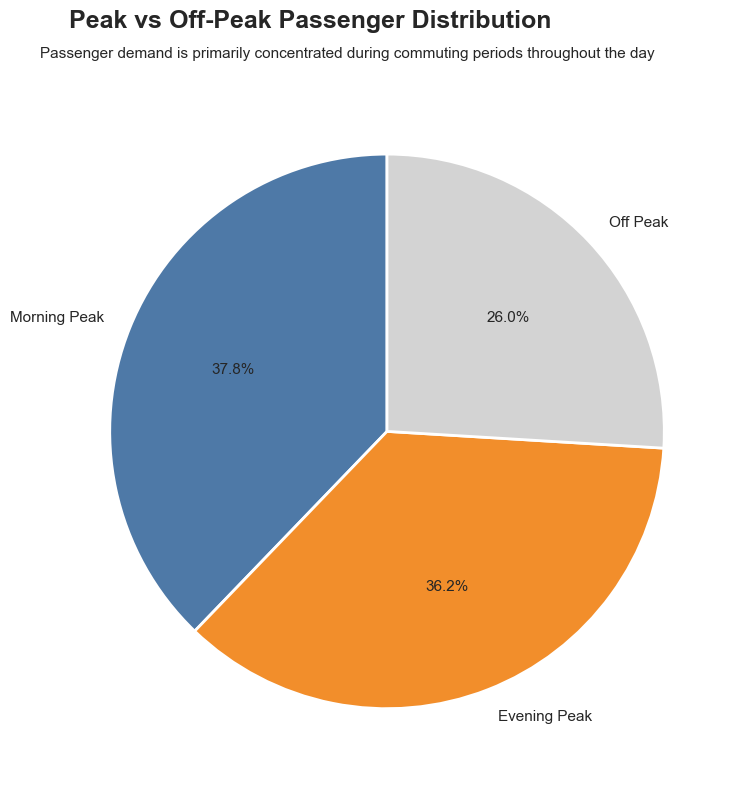

In [73]:
## Peak vs Off-Peak Passenger Distribution

# Calculate trip volume
morning_peak = df_mapping[
    df_mapping['tapInHour'].between(6, 9)
].shape[0]

evening_peak = df_mapping[
    df_mapping['tapInHour'].between(16, 19)
].shape[0]

off_peak = (
    df_mapping.shape[0]
    - morning_peak
    - evening_peak
)

# Create dataframe
peak_distribution = pd.DataFrame({
    'Period': [
        'Morning Peak',
        'Evening Peak',
        'Off Peak'
    ],
    
    'Trip Volume': [
        morning_peak,
        evening_peak,
        off_peak
    ]
})

colors = [
    '#4E79A7',  # soft blue
    '#F28E2B',  # soft orange
    '#D3D3D3'   # light gray
]


# Pie chart
plt.figure(figsize=(8,8))

plt.pie(
    peak_distribution['Trip Volume'],
    labels = peak_distribution['Period'],
    autopct = '%1.1f%%',
    startangle = 90,
    colors = colors,
    wedgeprops = {
        'edgecolor': 'white',
        'linewidth': 2
    },
    textprops = {
        'fontsize': 11
    }
)

# Title & subtitle
plt.suptitle(
    'Peak vs Off-Peak Passenger Distribution',
    fontsize = 18,
    fontweight = 'bold',
    x = 0.125,
    ha = 'left'
)

plt.title(
    'Passenger demand is primarily concentrated during commuting periods throughout the day',
    fontsize = 11,
    loc = 'left',
    pad = 20
)

plt.tight_layout()

plt.show()

Secara general, terlihat dari data bahwa mayoritas trip berada pada periode morning and evening peak yang menunjukkan tingginya kebutuhan penumpang untuk commuting ke kantor/mencari nafkah.

## Investigasi Arah Pergerakan Trip pada Morning dan Evening Peak Hour

Akan dianalisis (dan membuktikan hipotesis), apakah pergerakan trip cenderung menuju arah pusat kota atau tidak pada `Morning Peak Hour` dengan menetapkan `Bundaran HI` sebagai titik pusat kota. Pemilihan ini didasarkan karena menjadi salah satu pusat kativitas dan mobilitas utama di Jakarta, berada di jantung kota dan dikelilingi oleh berbagai bangunan strategis sepeti mall, perkantoran, kawasan bisnis, hingga kantor-kantor pemerintahan. 

In [74]:
## Definisikan koordinat Bundaran HI sebagai titik pusat kota

bundaran_hi_lat = -6.1931
bundaran_hi_lon = 106.8218

In [75]:
# Import geodesic untuk menghitung jarak halte ke Bundaran HI

from geopy.distance import geodesic

In [76]:
# Morning peak hour
morning_trip = df_mapping[
    df_mapping['tapInHour'].between(6, 9)
].copy()


## Menghitung jarak halte tap out ke Bundaran HI

morning_trip['distance_to_HI'] = morning_trip.apply(
    lambda row: geodesic(
        (row['tapOutStopsLat'], row['tapOutStopsLon']),
        (bundaran_hi_lat, bundaran_hi_lon)
    ).km
    if pd.notnull(row['tapOutStopsLat']) else np.nan,
    axis=1
)


## Sensitivity Analysis

radius_list = [3, 5, 7, 10]

result = []

previous_radius = 0

for radius in radius_list:
    
    # Jumlah trip menuju pusat kota
    trip_ke_pusat = (
        morning_trip['distance_to_HI'] <= radius
    ).sum()
    
    # Persentase
    persentase = (
        trip_ke_pusat / len(morning_trip)
    ) * 100
    
    
    ## Halte baru pada radius tertentu
    halte_baru = morning_trip[
        (morning_trip['distance_to_HI'] > previous_radius) &
        (morning_trip['distance_to_HI'] <= radius)
    ]
    
    
    ## Ambil 2 halte dengan jumlah tap out terbesar
    top_halte = (
        halte_baru['tapOutStopsName']
        .value_counts()
        .head(2)
        .index
        .tolist()
    )
    
    
    result.append([
        radius,
        trip_ke_pusat,
        round(persentase, 2),
        ', '.join(top_halte)
    ])
    
    previous_radius = radius


## Final Table

sensitivity_table = pd.DataFrame(
    result,
    columns = [
        'Radius dari Bundaran HI (km)',
        'Jumlah Trip Menuju Pusat Kota',
        'Persentase Trip (%)',
        'Contoh Halte Dominan'
    ]
)

sensitivity_table

,Radius dari Bundaran HI (km),Jumlah Trip Menuju Pusat Kota,Persentase Trip (%),Contoh Halte Dominan
0,3,1797,13.40,"Monas, Pecenongan"
1,5,3364,25.08,"Gelora Bung Karno, Bundaran Senayan 1"
2,7,5371,40.05,"Kejaksaan Agung, Kota"
3,10,8251,61.52,"Penjaringan, BKN"


Berdasarkan tabel sensitivitas, radius 7 km dari Bundaran HI dianggap paling representatif untuk mendefinisikan kawasan pusat kota. Karena ketika melihat contoh halte dominan pada jarak radius 10 km, Penjaringan dan BKN sudah tidak dinilai sebagai area pusat bisnis.

In [77]:
# Definisikan area <= 7 km sebagai Pusat Kota dan >7 Km sebagai Non-Pusat Kota

morning_trip['trip_area'] = np.where(
    morning_trip['distance_to_HI'] <= 7,
    'Pusat Kota',
    'Non-Pusat Kota'
)

# Distribusi trip
morning_distribution = (
    morning_trip['trip_area']
    .value_counts()
    .reset_index()
)

morning_distribution.columns = [
    'Area',
    'Jumlah Trip'
]

# Hitung persentase
morning_distribution['Persentase (%)'] = (
    morning_distribution['Jumlah Trip']
    / morning_distribution['Jumlah Trip'].sum()
    * 100
).round(2)

morning_distribution

,Area,Jumlah Trip,Persentase (%)
0,Non-Pusat Kota,8040,59.95
1,Pusat Kota,5371,40.05


Dari hasil analisis diketahui bahwa meskipun kawasan pusat kota Jakarta menjadi salah satu tujuan utama perjalanan pada morning peak hour, mayoritas pergerakan penumpang TransJakarta ternyata tidak hanya terkonsentrasi pada area pusat kota dalam radius 7 km dari Bundaran HI. Sebagian besar trip justru menunjukkan pola aktivitas antar kawasan (inter-district mobility), yang mengindikasikan bahwa mobilitas masyarakat Jakarta bersifat lebih tersebar dan tidak sepenuhnya terpusat pada satu kawasan CBD. Namun demikian, proporsi perjalanan menuju pusat kota yang mencapai 40,05% tetap menunjukkan bahwa kawasan CBD Jakarta masih memiliki peran penting sebagai salah satu pusat aktivitas dan tujuan commuting utama.

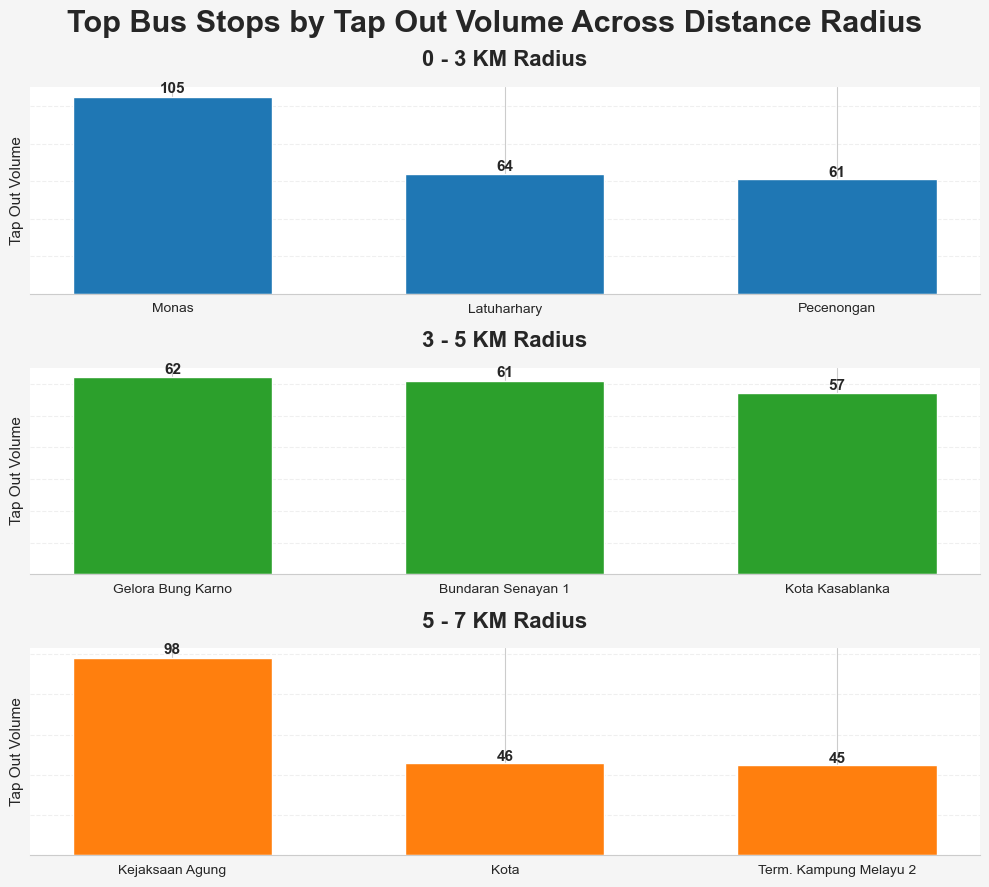

In [78]:
# Ingijn mengetahui halte dengan tapout terbanyak di radius 0-3 km, 3-5 km, dan 5-7 km dari Bundaran HI

import pandas as pd
import matplotlib.pyplot as plt
from geopy.distance import geodesic

# =========================
# Summary Tap Out
# =========================
tapout_summary = (
    morning_trip
    .groupby([
        'tapOutStops',
        'tapOutStopsName',
        'tapOutStopsLat',
        'tapOutStopsLon'
    ])
    .size()
    .reset_index(name='Total Tap Out')
)

# Hitung Distance dari Bundaran HI
def calculate_distance(row):

    halte_coord = (
        row['tapOutStopsLat'],
        row['tapOutStopsLon']
    )

    return geodesic(
        [bundaran_hi_lat, bundaran_hi_lon],
        halte_coord
    ).km

tapout_summary['distance_km'] = (
    tapout_summary.apply(
        calculate_distance,
        axis=1
    )
)

# Filter Radius
halte_3km = (
    tapout_summary[
        tapout_summary['distance_km'] <= 3
    ]
    .sort_values(
        by='Total Tap Out',
        ascending=False
    )
    .head(3)
)

halte_5km = (
    tapout_summary[
        (tapout_summary['distance_km'] > 3) &
        (tapout_summary['distance_km'] <= 5)
    ]
    .sort_values(
        by='Total Tap Out',
        ascending=False
    )
    .head(3)
)

halte_7km = (
    tapout_summary[
        (tapout_summary['distance_km'] > 5) &
        (tapout_summary['distance_km'] <= 7)
    ]
    .sort_values(
        by='Total Tap Out',
        ascending=False
    )
    .head(3)
)

# Plot Style Function
def plot_small_bar(ax, data, title, color):

    bars = ax.bar(
        data['tapOutStopsName'],
        data['Total Tap Out'],
        color=color,
        width=0.6
    )

    # value label
    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + (height * 0.02),
            f"{int(height):,}",
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

    # style
    ax.set_title(
        title,
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    ax.set_ylabel('Tap Out Volume', fontsize=11)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    ax.tick_params(
        axis='y',
        left=False,
        labelleft=False
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=0,
        ha='center',
        fontsize=10
    )

# =========================
# Create Figure
# =========================
fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 9)
)

fig.patch.set_facecolor('#f5f5f5')

# =========================
# Plot per Radius
# =========================
plot_small_bar(
    axes[0],
    halte_3km,
    '0 - 3 KM Radius',
    '#1f77b4'
)

plot_small_bar(
    axes[1],
    halte_5km,
    '3 - 5 KM Radius',
    '#2ca02c'
)

plot_small_bar(
    axes[2],
    halte_7km,
    '5 - 7 KM Radius',
    '#ff7f0e'
)

# =========================
# Main Title
# =========================
fig.suptitle(
    'Top Bus Stops by Tap Out Volume Across Distance Radius',
    fontsize=22,
    fontweight='bold',
    y=0.98
)

plt.tight_layout()
plt.show()

Dari grafik ini, diketahui bahwa halte yang menjadi tujuan utama pada radius 0-3 km, 3-5 km, 5-7 km adalah Monas, Gelora Bung Karno, dan Kejaksaan Agung. Monas dekat dengan pusat pemerintahan dan menjadi hub utama untuk mengarah ke Jakarta Utara. Untuk Gelora Bung Karno, menjadi halte destinasi banyak karyawan karena terpusatnya kantor di area tersebut. Untuk kejaksaan agung, meruapkan halte integrated dengan CSW, yang menjadi hub untuk bus ke arah Tangerang, Jakarta Timur, maupun MRT.

In [79]:
# Membuat peta scatter lokasi tapoutstops di radius pusat kota  untuk morning peak hour

import folium
from geopy.distance import geodesic

# =========================
# Base Map
# =========================
jakarta_map = folium.Map(
    location=[bundaran_hi_lat, bundaran_hi_lon],
    zoom_start=11,
    tiles='CartoDB positron'
)

# =========================
# Marker Bundaran HI
# =========================
folium.CircleMarker(
    location=[bundaran_hi_lat, bundaran_hi_lon],
    radius=8,
    color='red',
    fill=True,
    fill_color='red',
    fill_opacity=1,
    popup='Bundaran HI'
).add_to(jakarta_map)

# =========================
# Total Tap Out per Halte
# =========================
tapout_summary = (
    morning_trip
    .groupby([
        'tapOutStopsName',
        'tapOutStopsLat',
        'tapOutStopsLon'
    ])
    .size()
    .reset_index(name='Total Tap Out')
)

# =========================
# Hitung Distance dari Bundaran HI
# =========================
def calculate_distance(row):

    halte_coord = (
        row['tapOutStopsLat'],
        row['tapOutStopsLon']
    )

    return geodesic(
        [bundaran_hi_lat, bundaran_hi_lon],
        halte_coord
    ).km

tapout_summary['distance_km'] = (
    tapout_summary.apply(
        calculate_distance,
        axis=1
    )
)

# =========================
# Filter max 7 KM
# =========================
tapout_7km = tapout_summary[
    tapout_summary['distance_km'] <= 7
]

# =========================
# Top 30 Halte
# =========================
top_halte = (
    tapout_7km
    .sort_values(
        by='Total Tap Out',
        ascending=False
    )
    .head(30)
)

# =========================
# Radius Circle
# =========================
radius_config = {
    3000: '#1f77b4',   # Blue
    5000: '#2ca02c',   # Green
    7000: '#ff7f0e'    # Orange
}

for radius, color in radius_config.items():

    folium.Circle(
        radius=radius,
        location=[bundaran_hi_lat, bundaran_hi_lon],
        color=color,
        fill=True,
        fill_opacity=0.03,
        weight=2
    ).add_to(jakarta_map)

# =========================
# Plot Halte
# =========================
for _, row in top_halte.iterrows():

    # Warna berdasarkan distance
    if row['distance_km'] <= 3:
        bubble_color = '#1f77b4'

    elif row['distance_km'] <= 5:
        bubble_color = '#2ca02c'

    else:
        bubble_color = '#ff7f0e'

    folium.CircleMarker(
        location=[
            row['tapOutStopsLat'],
            row['tapOutStopsLon']
        ],

        radius=7,

        color='black',
        weight=1,

        fill=True,
        fill_color=bubble_color,
        fill_opacity=0.75,

        popup=f"""
        <b>{row['tapOutStopsName']}</b><br>
        Total Tap Out: {row['Total Tap Out']:,}<br>
        Distance: {row['distance_km']:.2f} KM
        """

    ).add_to(jakarta_map)

# =========================
# Small Custom Legend
# =========================
legend_html = '''
<div style="
    position: fixed;
    bottom: 15px;
    left: 15px;
    width: 140px;
    background-color: white;
    border:1px solid lightgrey;
    z-index:9999;
    font-size:11px;
    padding:8px;
    border-radius:8px;
    box-shadow: 1px 1px 4px rgba(0,0,0,0.2);
">

<b>Distance Radius</b><br><br>

<i style="
background:#1f77b4;
width:10px;
height:10px;
float:left;
margin-right:6px;
opacity:0.8;
border-radius:50%;
"></i>
0 - 3 KM<br><br>

<i style="
background:#2ca02c;
width:10px;
height:10px;
float:left;
margin-right:6px;
opacity:0.8;
border-radius:50%;
"></i>
3 - 5 KM<br><br>

<i style="
background:#ff7f0e;
width:10px;
height:10px;
float:left;
margin-right:6px;
opacity:0.8;
border-radius:50%;
"></i>
5 - 7 KM

</div>
'''

jakarta_map.get_root().html.add_child(
    folium.Element(legend_html)
)

# =========================
# Display Map
# =========================
jakarta_map

In [80]:
# Membuat peta scatter untuk halte degan tapout terbanyak pada evening peak hour
import folium
from geopy.distance import geodesic

# =========================
# Evening Peak Hour Data
# =========================
evening_trip = df_mapping[
    df_mapping['tapInHour'].between(16,19)
]

# =========================
# Tap Out Summary
# =========================
tapout_summary = (
    evening_trip
    .groupby([
        'tapOutStopsName',
        'tapOutStopsLat',
        'tapOutStopsLon'
    ])
    .size()
    .reset_index(name='Total Tap Out')
)

# =========================
# Calculate Distance
# =========================
def calculate_distance(row):

    halte_coord = (
        row['tapOutStopsLat'],
        row['tapOutStopsLon']
    )

    return geodesic(
        [bundaran_hi_lat, bundaran_hi_lon],
        halte_coord
    ).km

tapout_summary['distance_km'] = (
    tapout_summary.apply(
        calculate_distance,
        axis=1
    )
)

# =========================
# Filter Max 25 KM
# =========================
tapout_25km = tapout_summary[
    tapout_summary['distance_km'] <= 25
]

# =========================
# Top Stops
# =========================
top_stops = (
    tapout_25km
    .sort_values(
        by='Total Tap Out',
        ascending=False
    )
    .head(60)
)

# =========================
# Base Map
# =========================
jakarta_map = folium.Map(
    location=[bundaran_hi_lat, bundaran_hi_lon],
    zoom_start=10,
    tiles='CartoDB positron'
)

# =========================
# Bundaran HI Marker
# =========================
folium.CircleMarker(
    location=[bundaran_hi_lat, bundaran_hi_lon],
    radius=9,
    color='red',
    fill=True,
    fill_color='red',
    fill_opacity=1,
    popup='Bundaran HI'
).add_to(jakarta_map)

# =========================
# Radius Circles
# =========================
radius_config = {
    10000: '#4E79A7',  # 0–10 KM
    15000: '#59A14F',  # 10–15 KM
    25000: '#F28E2B'   # 15–25 KM
}

for radius, color in radius_config.items():

    folium.Circle(
        radius=radius,
        location=[bundaran_hi_lat, bundaran_hi_lon],
        color=color,
        fill=True,
        fill_opacity=0.03,
        weight=2
    ).add_to(jakarta_map)

# =========================
# Plot Stops
# =========================
for _, row in top_stops.iterrows():

    # Color by distance
    if row['distance_km'] <= 10:
        bubble_color = '#4E79A7'

    elif row['distance_km'] <= 15:
        bubble_color = '#59A14F'

    else:
        bubble_color = '#F28E2B'

    folium.CircleMarker(
        location=[
            row['tapOutStopsLat'],
            row['tapOutStopsLon']
        ],

        radius=max(
            5,
            row['Total Tap Out'] / 400
        ),

        color='black',
        weight=1,

        fill=True,
        fill_color=bubble_color,
        fill_opacity=0.75,

        popup=f"""
        <b>{row['tapOutStopsName']}</b><br>
        Total Tap Out: {row['Total Tap Out']:,}<br>
        Distance: {row['distance_km']:.2f} KM
        """

    ).add_to(jakarta_map)

# =========================
# Legend
# =========================
legend_html = '''
<div style="
    position: fixed;
    bottom: 15px;
    left: 15px;
    width: 165px;
    background-color: white;
    border:1px solid lightgrey;
    z-index:9999;
    font-size:11px;
    padding:8px;
    border-radius:8px;
    box-shadow: 1px 1px 4px rgba(0,0,0,0.2);
">

<b>Distance Radius</b><br><br>

<i style="
background:#4E79A7;
width:10px;
height:10px;
float:left;
margin-right:6px;
opacity:0.8;
border-radius:50%;
"></i>
0 - 10 KM<br><br>

<i style="
background:#59A14F;
width:10px;
height:10px;
float:left;
margin-right:6px;
opacity:0.8;
border-radius:50%;
"></i>
10 - 15 KM<br><br>

<i style="
background:#F28E2B;
width:10px;
height:10px;
float:left;
margin-right:6px;
opacity:0.8;
border-radius:50%;
"></i>
15 - 25 KM

</div>
'''

jakarta_map.get_root().html.add_child(
    folium.Element(legend_html)
)

# =========================
# Display Map
# =========================
jakarta_map

# Menghitung Jarak Terjauh Mobilitas Penumpang dari Pusat Kota (Bundaran HI)

In [81]:

# Calculate Maximum Distance
max_distance = (
    tapout_summary['distance_km']
    .max()
)

print(f'Maximum Distance: {max_distance:.2f} KM')

Maximum Distance: 23.16 KM


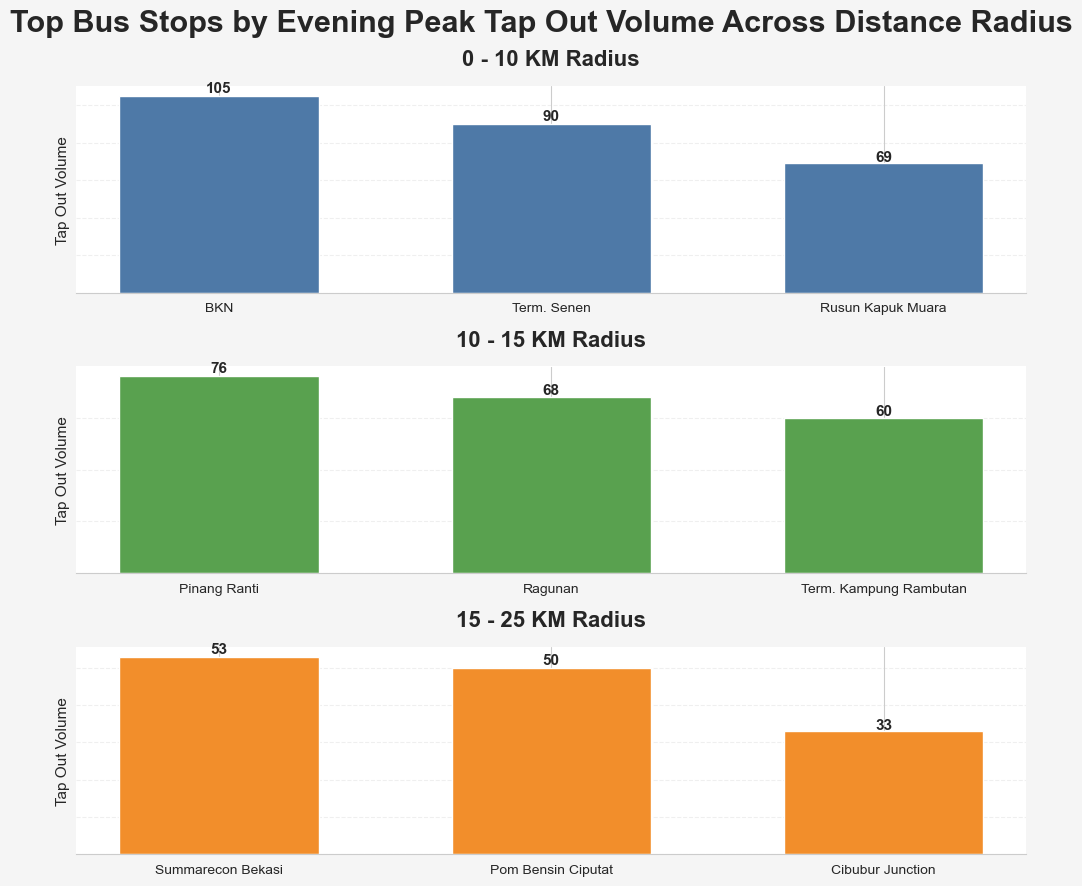

In [82]:
## Mengtahui halte dengan tap out terbanyak di evening peak hour

import pandas as pd
import matplotlib.pyplot as plt
from geopy.distance import geodesic

# =========================
# Evening Peak Hour Data
# =========================
evening_trip = df_mapping[
    df_mapping['tapInHour'].between(16,19)
]

# =========================
# Summary Tap Out
# =========================
tapout_summary = (
    evening_trip
    .groupby([
        'tapOutStops',
        'tapOutStopsName',
        'tapOutStopsLat',
        'tapOutStopsLon'
    ])
    .size()
    .reset_index(name='Total Tap Out')
)

# =========================
# Calculate Distance from Bundaran HI
# =========================
def calculate_distance(row):

    halte_coord = (
        row['tapOutStopsLat'],
        row['tapOutStopsLon']
    )

    return geodesic(
        [bundaran_hi_lat, bundaran_hi_lon],
        halte_coord
    ).km

tapout_summary['distance_km'] = (
    tapout_summary.apply(
        calculate_distance,
        axis=1
    )
)

# =========================
# Filter Radius
# =========================
halte_10km = (
    tapout_summary[
        tapout_summary['distance_km'] <= 10
    ]
    .sort_values(
        by='Total Tap Out',
        ascending=False
    )
    .head(3)
)

halte_15km = (
    tapout_summary[
        (tapout_summary['distance_km'] > 10) &
        (tapout_summary['distance_km'] <= 15)
    ]
    .sort_values(
        by='Total Tap Out',
        ascending=False
    )
    .head(3)
)

halte_25km = (
    tapout_summary[
        (tapout_summary['distance_km'] > 15) &
        (tapout_summary['distance_km'] <= 25)
    ]
    .sort_values(
        by='Total Tap Out',
        ascending=False
    )
    .head(3)
)

# =========================
# Plot Style Function
# =========================
def plot_small_bar(ax, data, title, color):

    bars = ax.bar(
        data['tapOutStopsName'],
        data['Total Tap Out'],
        color=color,
        width=0.6
    )

    # Value label
    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + (height * 0.02),
            f"{int(height):,}",
            ha='center',
            fontsize=11,
            fontweight='bold'
        )

    # Styling
    ax.set_title(
        title,
        fontsize=16,
        fontweight='bold',
        pad=15
    )

    ax.set_ylabel(
        'Tap Out Volume',
        fontsize=11
    )

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)

    ax.grid(
        axis='y',
        linestyle='--',
        alpha=0.3
    )

    ax.tick_params(
        axis='y',
        left=False,
        labelleft=False
    )

    plt.setp(
        ax.get_xticklabels(),
        rotation=0,
        ha='center',
        fontsize=10
    )

# =========================
# Create Figure
# =========================
fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 9)
)

fig.patch.set_facecolor('#f5f5f5')

# =========================
# Plot per Radius
# =========================
plot_small_bar(
    axes[0],
    halte_10km,
    '0 - 10 KM Radius',
    '#4E79A7'
)

plot_small_bar(
    axes[1],
    halte_15km,
    '10 - 15 KM Radius',
    '#59A14F'
)

plot_small_bar(
    axes[2],
    halte_25km,
    '15 - 25 KM Radius',
    '#F28E2B'
)

# =========================
# Main Title
# =========================
fig.suptitle(
    'Top Bus Stops by Evening Peak Tap Out Volume Across Distance Radius',
    fontsize=22,
    fontweight='bold',
    y=0.98
)

plt.tight_layout()

plt.show()

## Sequence Length Morning Peak Hour dan Evening Peak Hour

In [83]:
# Menghitung sequence length untuk morning peak hour
morning_trip['sequenceLength'] = (
    morning_trip['stopEndSeq']
    - morning_trip['stopStartSeq']
)

# Menghapus nilai negatif / anomali
morning_trip_seq = morning_trip[
    morning_trip['sequenceLength'] >= 0
]

# Statistik deskriptif
morning_trip_seq['sequenceLength'].describe()

count    13411.000000
mean         7.393483
std          7.431389
min          1.000000
25%          2.000000
50%          5.000000
75%         10.000000
max         54.000000
Name: sequenceLength, dtype: float64

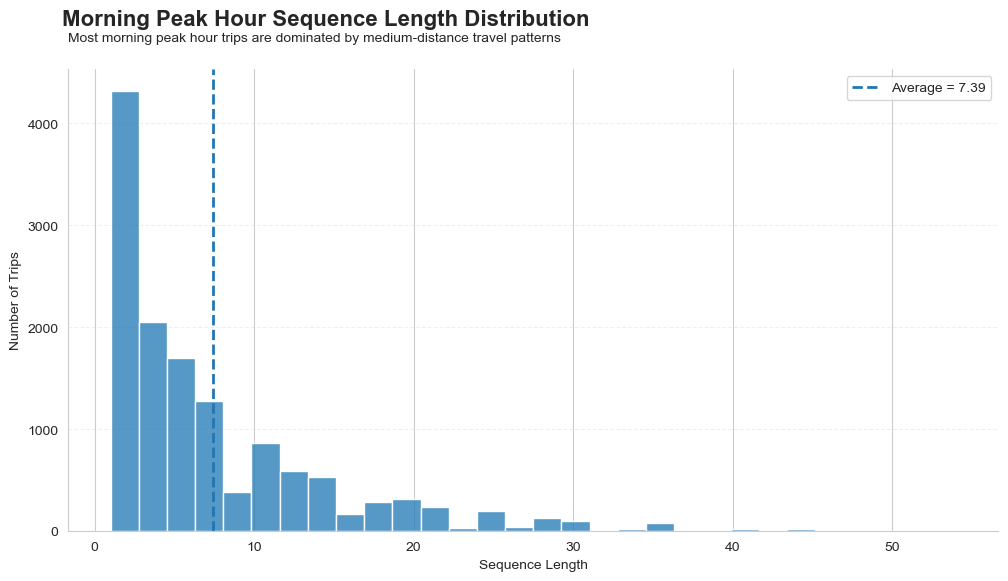

In [84]:
plt.figure(figsize=(12,6))

# Histogram
sns.histplot(
    morning_trip_seq['sequenceLength'],
    bins=30
)

# Average line
avg_seq = morning_trip_seq['sequenceLength'].mean()

plt.axvline(
    avg_seq,
    linestyle='--',
    linewidth=2,
    label=f'Average = {avg_seq:.2f}'
)

plt.suptitle(
    'Morning Peak Hour Sequence Length Distribution',
    fontsize=16,
    fontweight='bold',
    x=0.12,
    ha='left'
)

plt.title(
    'Most morning peak hour trips are dominated by medium-distance travel patterns',
    fontsize=10,
    loc='left',
    pad=20
)

plt.xlabel('Sequence Length')
plt.ylabel('Number of Trips')

plt.legend()

sns.despine()

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.show()

In [85]:
sequence_summary = pd.DataFrame({
    'Metric': [
        'Rata-rata',
        'Median',
        'Minimum',
        'Maximum'
    ],
    
    'Value': [
        morning_trip_seq['sequenceLength'].mean(),
        morning_trip_seq['sequenceLength'].median(),
        morning_trip_seq['sequenceLength'].min(),
        morning_trip_seq['sequenceLength'].max()
    ]
})

sequence_summary

,Metric,Value
0,Rata-rata,7.393483
1,Median,5.000000
2,Minimum,1.000000
3,Maximum,54.000000


Diketahui rata-rata halte yang dilewati oleh para commuter ada di rentang 7 halte, menunjukkan perjalanan didominasi rentang jarak short-medium.

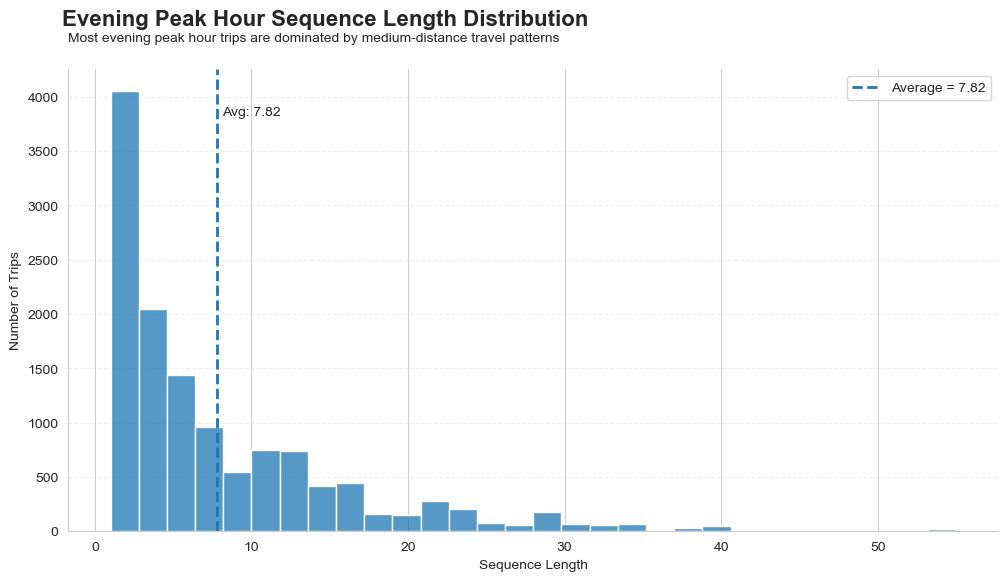

In [86]:
# Evening Sequence Length

df_mapping['tapInTime'] = pd.to_datetime(
    df_mapping['tapInTime']
)

df_mapping['hour'] = (
    df_mapping['tapInTime']
    .dt.hour
)

evening_trip = df_mapping[
    (df_mapping['hour'] >= 16) &
    (df_mapping['hour'] <= 19)
].copy()

evening_trip['sequenceLength'] = (
    evening_trip['stopEndSeq']
    - evening_trip['stopStartSeq']
)

evening_trip_seq = evening_trip[
    evening_trip['sequenceLength'] >= 0
]

avg_seq = (
    evening_trip_seq['sequenceLength']
    .mean()
)

plt.figure(figsize=(12,6))

sns.histplot(
    evening_trip_seq['sequenceLength'],
    bins=30
)

plt.axvline(
    avg_seq,
    linestyle='--',
    linewidth=2,
    label=f'Average = {avg_seq:.2f}'
)

plt.text(
    avg_seq + 0.3,
    plt.ylim()[1] * 0.9,
    f'Avg: {avg_seq:.2f}',
    fontsize=10
)

plt.suptitle(
    'Evening Peak Hour Sequence Length Distribution',
    fontsize=16,
    fontweight='bold',
    x=0.12,
    ha='left'
)

plt.title(
    'Most evening peak hour trips are dominated by medium-distance travel patterns',
    fontsize=10,
    loc='left',
    pad=20
)

plt.xlabel('Sequence Length')
plt.ylabel('Number of Trips')

plt.legend()

sns.despine()

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.show()

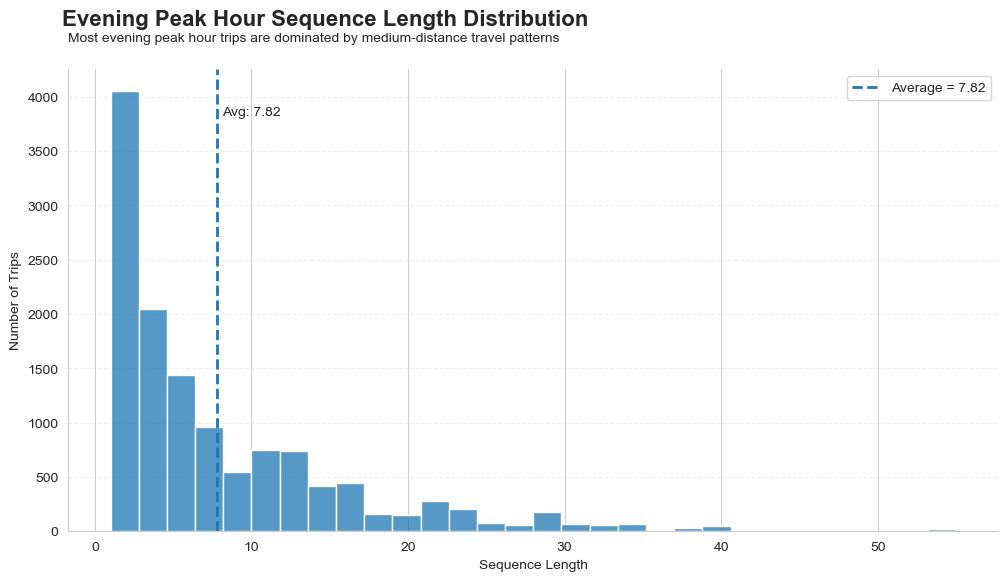

In [87]:
plt.figure(figsize=(12,6))

sns.histplot(
    evening_trip_seq['sequenceLength'],
    bins=30
)

# Average value
avg_seq = evening_trip_seq['sequenceLength'].mean()

# Mean line
plt.axvline(
    avg_seq,
    linestyle='--',
    linewidth=2,
    label=f'Average = {avg_seq:.2f}'
)

# Average annotation
plt.text(
    avg_seq + 0.3,
    plt.ylim()[1] * 0.9,
    f'Avg: {avg_seq:.2f}',
    fontsize=10
)

plt.suptitle(
    'Evening Peak Hour Sequence Length Distribution',
    fontsize=16,
    fontweight='bold',
    x=0.12,
    ha='left'
)

plt.title(
    'Most evening peak hour trips are dominated by medium-distance travel patterns',
    fontsize=10,
    loc='left',
    pad=20
)

plt.xlabel('Sequence Length')
plt.ylabel('Number of Trips')

plt.legend()

sns.despine()

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.show()

Untuk Evening Peak Hour, terlihat sequence length slightly lebih banyak. Menunjukkan willingness penggguna moda untuk lebih lama menggunakan moda, dibandingkan pagi (bisa karena mengajr waktu masuk kantor).

In [88]:
# Ambil jam dari tap in
df_mapping['hour'] = pd.to_datetime(
    df_mapping['tapInTime']
).dt.hour

# Filter peak hour pagi dan sore
peak_hour = df_mapping[
    (
        (df_mapping['hour'].between(6,9)) |
        (df_mapping['hour'].between(16,19))
    )
]

# Hitung jumlah trip berdasarkan gender saat peak hour
gender_peak = (
    peak_hour.groupby('payCardSex')
    .size()
    .reset_index(name='Jumlah Trip')
    .sort_values(by='Jumlah Trip', ascending=False)
)

gender_peak

,payCardSex,Jumlah Trip
0,F,13969
1,M,12298


In [89]:
# Peak hour trips (Morning Peak Hour)
peak_hour = df_mapping[
    df_mapping['tapInHour'].between(6,9)
]

# Female passenger trips during peak hour
female_peak = peak_hour[
    peak_hour['payCardSex'] == 'F'
]

# Total trips per corridor during peak hour
total_corridor_peak = (
    peak_hour
    .groupby(['corridorID', 'corridorName'])
    .size()
    .reset_index(name='Total Trip')
)

# Female trips per corridor
female_corridor = (
    female_peak
    .groupby(['corridorID', 'corridorName'])
    .size()
    .reset_index(name='Female Trip')
)

# Merge datasets
female_ratio = total_corridor_peak.merge(
    female_corridor,
    on=['corridorID', 'corridorName'],
    how='left'
)

# Fill missing values
female_ratio['Female Trip'] = (
    female_ratio['Female Trip']
    .fillna(0)
)

# Calculate female passenger percentage
female_ratio['Female Passenger Percentage (%)'] = (
    female_ratio['Female Trip']
    / female_ratio['Total Trip']
    * 100
)

# Filter corridors with sufficient trip volume
female_ratio = female_ratio[
    female_ratio['Total Trip'] > 100
]

# Sort descending
female_ratio = female_ratio.sort_values(
    by='Female Passenger Percentage (%)',
    ascending=False
)

# Display top 10
female_ratio.head(10)

,corridorID,corridorName,Total Trip,Female Trip,Female Passenger Percentage (%)
219,T11,Poris Plawad - Bundaran Senayan,116,96.0,82.758621
47,2P,Gondangdia - Senen,107,77.0,71.962617
202,M13,Puri Beta 2 - Tendean,118,77.0,65.254237
44,2E,Rusun Rawa Bebek - Kodamar,130,84.0,64.615385
148,JAK.27,Pulo Gebang - Rorotan,101,58.0,57.425743
14,11P,Rusun Pondok Bambu - Walikota Jakarta Timur,138,79.0,57.246377
210,M7B,BKN - Blok M,119,68.0,57.142857
58,4C,TU Gas - Bundaran Senayan,101,57.0,56.435644
120,JAK.06,Kampung Rambutan - Pondok Gede,137,73.0,53.284672
76,6N,Ragunan - Blok M via Kemang,106,51.0,48.113208


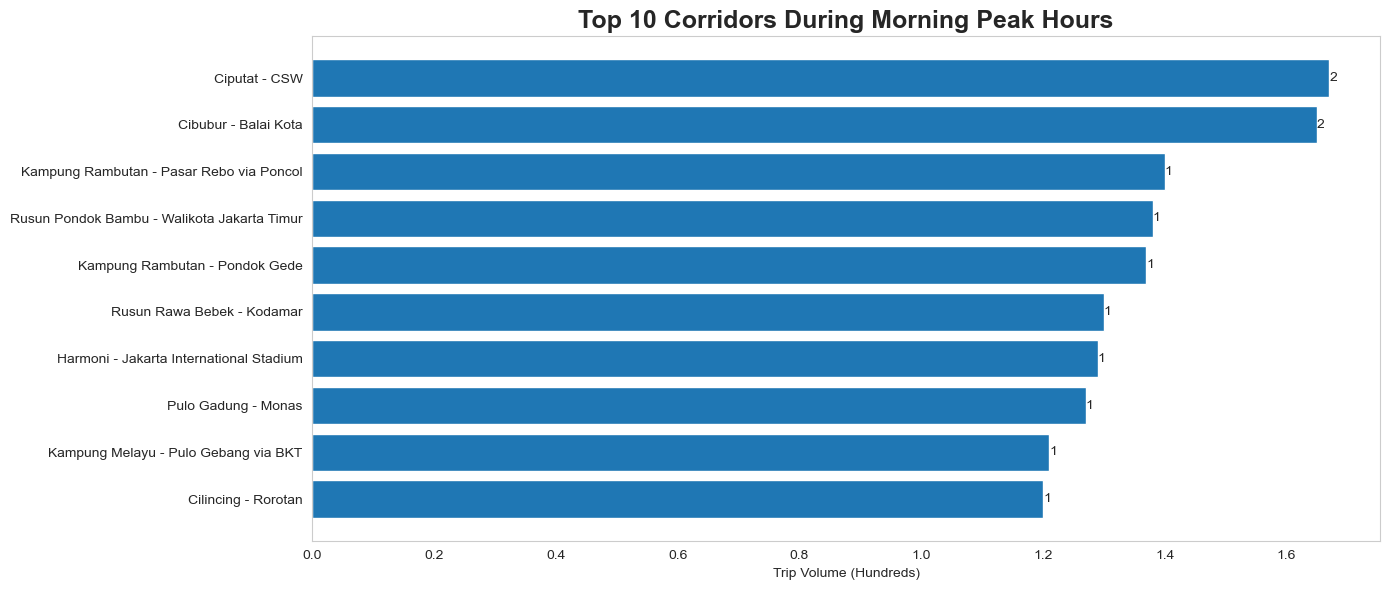

In [90]:
morning_peak = df_mapping[
    df_mapping['tapInHour'].between(6,9)
]

morning_corridors = (
    morning_peak
    .groupby('corridorName')
    .size()
    .reset_index(name='Trip Volume')
    .sort_values(by='Trip Volume', ascending=False)
    .head(10)
)

plt.figure(figsize=(14,6))

bars = plt.barh(
    morning_corridors['corridorName'],
    morning_corridors['Trip Volume'] / 100
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:,.0f}',
        va='center'
    )

plt.gca().invert_yaxis()
plt.grid(False)

plt.title(
    'Top 10 Corridors During Morning Peak Hours',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Trip Volume (Hundreds)')
plt.ylabel('')

plt.tight_layout()
plt.show()

Koridor yang didentifikasi menjadi koridor tersibuk pada morning peak hour adalah Ciputat-CSW, Cibubur - Balai Kota, dan Kampung Rambutan-Pasar Rebo yang didominasi dari area suburban ke area pusat kota.

## Koridor dengan Trip Tertinggi pada Evening Peak Hour

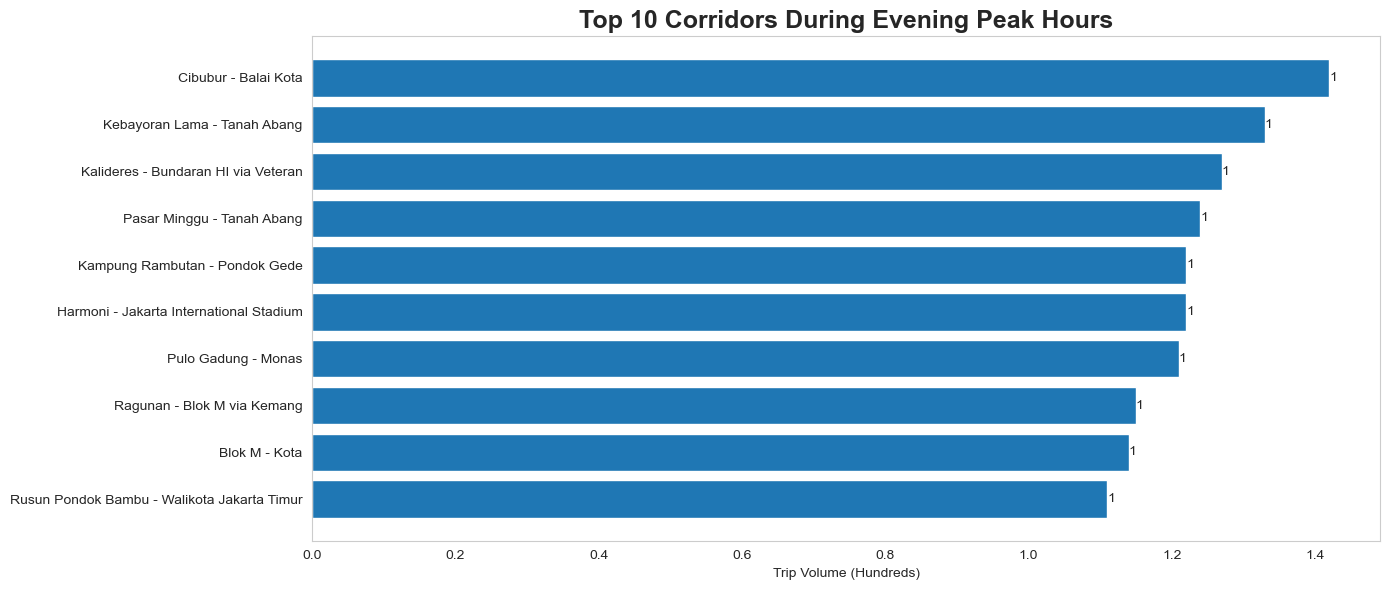

In [91]:
evening_peak = df_mapping[
    df_mapping['tapInHour'].between(16,19)
]

evening_corridors = (
    evening_peak
    .groupby('corridorName')
    .size()
    .reset_index(name='Trip Volume')
    .sort_values(by='Trip Volume', ascending=False)
    .head(10)
)

plt.figure(figsize=(14,6))

bars = plt.barh(
    evening_corridors['corridorName'],
    evening_corridors['Trip Volume'] / 100
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f'{width:,.0f}',
        va='center'
    )

plt.gca().invert_yaxis()
plt.grid(False)

plt.title(
    'Top 10 Corridors During Evening Peak Hours',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Trip Volume (Hundreds)')
plt.ylabel('')

plt.tight_layout()
plt.show()

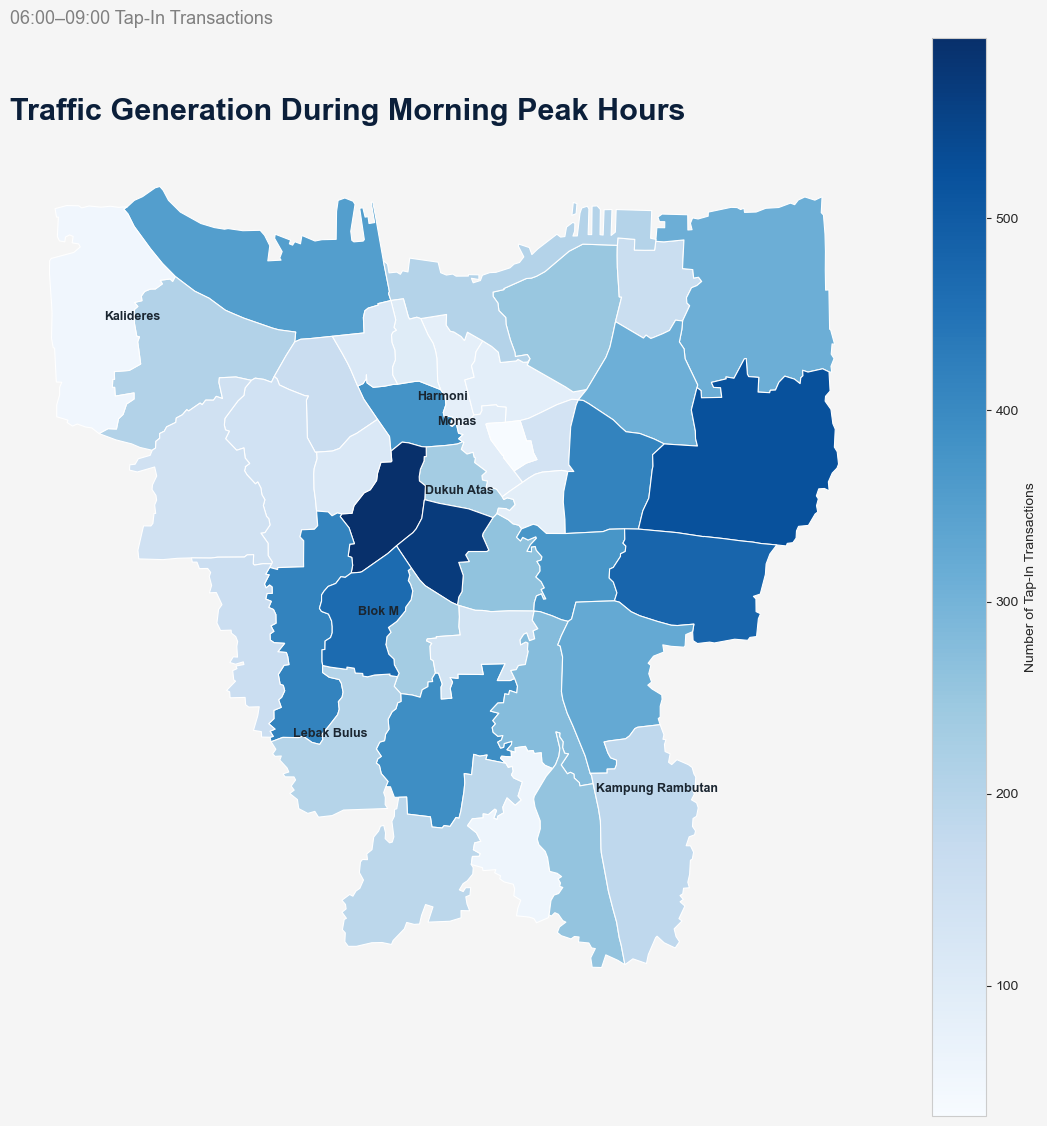

In [92]:
import geopandas as gpd
# Filter morning peak hour
morning_peak = df_mapping[
    (df_mapping['tapInTime'].dt.hour >= 6) &
    (df_mapping['tapInTime'].dt.hour < 9)
].copy()

# Clean coordinates
morning_peak = morning_peak[
    (morning_peak['tapInStopsLat'].between(-6.5, -5.9)) &
    (morning_peak['tapInStopsLon'].between(106.6, 107.1))
]

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    morning_peak,
    geometry=gpd.points_from_xy(
        morning_peak['tapInStopsLon'],
        morning_peak['tapInStopsLat']
    ),
    crs='EPSG:4326'
)

# Load Jakarta GeoJSON
jakarta = gpd.read_file(
    '/Users/primettatatiana/Downloads/jakarta_kecamatan.geojson'
)

# Match CRS
jakarta = jakarta.to_crs(gdf.crs)

# Spatial join
joined = gpd.sjoin(
    gdf,
    jakarta,
    how='left',
    predicate='within'
)

# Aggregate traffic
traffic = (
    joined.groupby('name')
    .size()
    .reset_index(name='total_trip')
)

# Merge traffic to map
jakarta_map = jakarta.merge(
    traffic,
    on='name',
    how='left'
)

# Fill missing values
jakarta_map['total_trip'] = jakarta_map['total_trip'].fillna(0)

# Plot map
fig, ax = plt.subplots(
    figsize=(14,14),
    facecolor='#F5F5F5'
)

jakarta_map.plot(
    column='total_trip',
    cmap='Blues',
    linewidth=0.8,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Number of Tap-In Transactions'
    },
    ax=ax
)

# Important area labels
important_areas = {
    'Blok M': (106.7985, -6.2446),
    'Monas': (106.8272, -6.1754),
    'Dukuh Atas': (106.8229, -6.2007),
    'Harmoni': (106.8198, -6.1663),
    'Lebak Bulus': (106.7746, -6.2890),
    'Kampung Rambutan': (106.8853, -6.3089),
    'Kalideres': (106.7055, -6.1374)
}

for area, coord in important_areas.items():
    ax.text(
        coord[0],
        coord[1],
        area,
        fontsize=9,
        fontweight='bold',
        color='#1B2631'
    )

# Remove axis
ax.set_axis_off()

# Title
plt.title(
    'Traffic Generation During Morning Peak Hours',
    fontsize=22,
    fontweight='bold',
    loc='left',
    color='#0B1F3A',
    pad=20
)

# Subtitle
plt.suptitle(
    '06:00–09:00 Tap-In Transactions',
    fontsize=13,
    x=0.125,
    y=0.90,
    ha='left',
    color='gray'
)

plt.show()

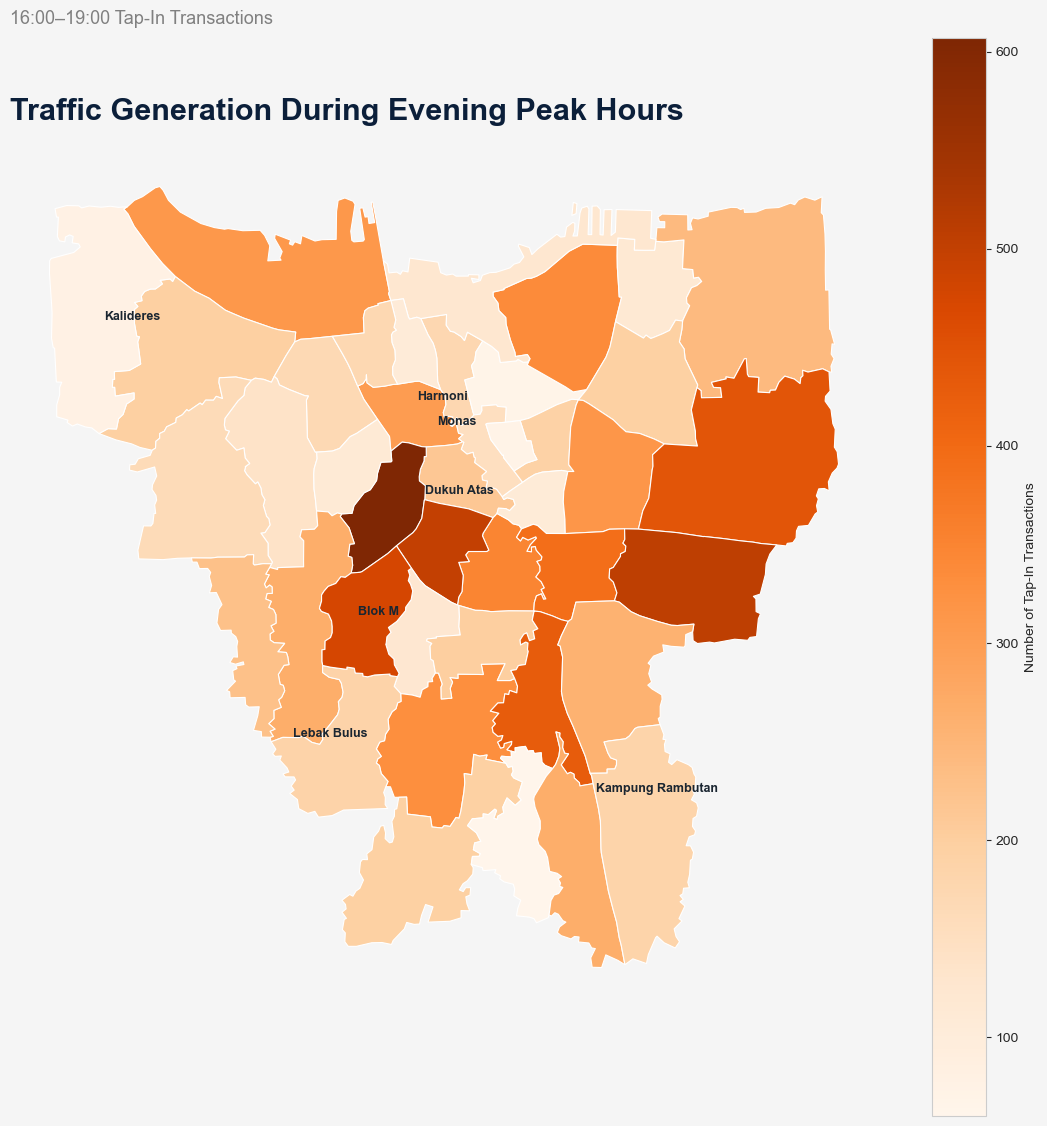

In [93]:
# Peta untuk melihat jumlah trip terbanyak di evening peak hour

import geopandas as gpd

# Filter evening peak hour
evening_peak = df_mapping[
    (df_mapping['tapInTime'].dt.hour >= 16) &
    (df_mapping['tapInTime'].dt.hour < 19)
].copy()

# Clean coordinates
evening_peak = evening_peak[
    (evening_peak['tapInStopsLat'].between(-6.5, -5.9)) &
    (evening_peak['tapInStopsLon'].between(106.6, 107.1))
]

# Convert to GeoDataFrame
gdf = gpd.GeoDataFrame(
    evening_peak,
    geometry=gpd.points_from_xy(
        evening_peak['tapInStopsLon'],
        evening_peak['tapInStopsLat']
    ),
    crs='EPSG:4326'
)

# Load Jakarta GeoJSON
jakarta = gpd.read_file(
    '/Users/primettatatiana/Downloads/jakarta_kecamatan.geojson'
)

# Match CRS
jakarta = jakarta.to_crs(gdf.crs)

# Spatial join
joined = gpd.sjoin(
    gdf,
    jakarta,
    how='left',
    predicate='within'
)

# Aggregate traffic
traffic = (
    joined.groupby('name')
    .size()
    .reset_index(name='total_trip')
)

# Merge traffic to map
jakarta_map = jakarta.merge(
    traffic,
    on='name',
    how='left'
)

# Fill missing values
jakarta_map['total_trip'] = jakarta_map['total_trip'].fillna(0)

# Plot map
fig, ax = plt.subplots(
    figsize=(14,14),
    facecolor='#F5F5F5'
)

jakarta_map.plot(
    column='total_trip',
    cmap='Oranges',
    linewidth=0.8,
    edgecolor='white',
    legend=True,
    legend_kwds={
        'label': 'Number of Tap-In Transactions'
    },
    ax=ax
)

# Important area labels
important_areas = {
    'Blok M': (106.7985, -6.2446),
    'Monas': (106.8272, -6.1754),
    'Dukuh Atas': (106.8229, -6.2007),
    'Harmoni': (106.8198, -6.1663),
    'Lebak Bulus': (106.7746, -6.2890),
    'Kampung Rambutan': (106.8853, -6.3089),
    'Kalideres': (106.7055, -6.1374)
}

for area, coord in important_areas.items():
    ax.text(
        coord[0],
        coord[1],
        area,
        fontsize=9,
        fontweight='bold',
        color='#1B2631'
    )

# Remove axis
ax.set_axis_off()

# Title
plt.title(
    'Traffic Generation During Evening Peak Hours',
    fontsize=22,
    fontweight='bold',
    loc='left',
    color='#0B1F3A',
    pad=20
)

# Subtitle
plt.suptitle(
    '16:00–19:00 Tap-In Transactions',
    fontsize=13,
    x=0.125,
    y=0.90,
    ha='left',
    color='gray'
)

plt.show()

Diektahui untuk morning dan evening peak hour, memang trip terkonsentrasi di area pusat kota antara Blok M - Senayan - Sudirman.

In [94]:
import contextily as ctx

In [95]:
!pip install contextily

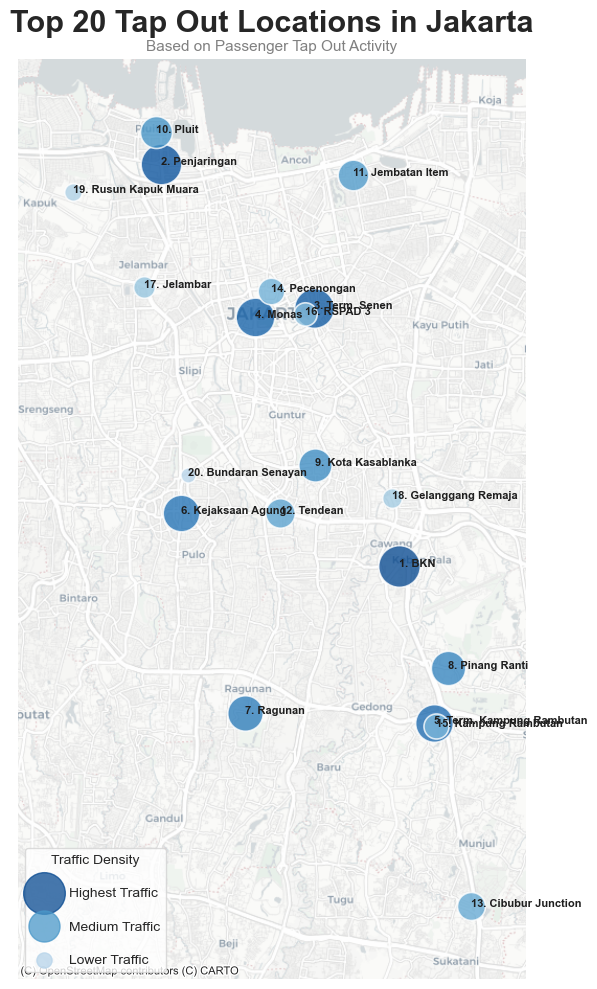

In [96]:

# Aggregasi Top 20 Tap Out
# (Menggunakan df_mapping)
top20 = (
    df_mapping[
        df_mapping['tapOutStopsLat'].notnull() &
        df_mapping['tapOutStopsLon'].notnull()
    ]
    .groupby(
        [
            'tapOutStopsName',
            'tapOutStopsLat',
            'tapOutStopsLon'
        ]
    )
    .size()
    .reset_index(name='total_tapout')
    .sort_values(
        by='total_tapout',
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

# ===================================
# Tambahkan Ranking
# ===================================
top20['rank'] = top20.index + 1

# ===================================
# Bubble Size
# ===================================
bubble_sizes = np.linspace(
    900,   # terbesar
    120,   # terkecil
    20
)

top20['bubble_size'] = bubble_sizes

# ===================================
# Warna Biru Tua -> Biru Muda
# ===================================
colors = plt.cm.Blues(
    np.linspace(0.9, 0.3, 20)
)

top20['color'] = [colors[i] for i in range(20)]

# Convert ke GeoDataFrame
gdf = gpd.GeoDataFrame(
    top20,
    geometry=gpd.points_from_xy(
        top20['tapOutStopsLon'],
        top20['tapOutStopsLat']
    ),
    crs='EPSG:4326'
)

# Convert CRS

gdf = gdf.to_crs(epsg=3857)

# Plot
fig, ax = plt.subplots(figsize=(16,10))

ax.set_aspect(1)

# Bubble Plot
for _, row in gdf.iterrows():

    ax.scatter(
        row.geometry.x,
        row.geometry.y,
        s=row['bubble_size'],
        color=row['color'],
        alpha=0.78,
        edgecolor='white',
        linewidth=1.2
    )

# Label Ranking + Nama Halte
for _, row in gdf.iterrows():

    ax.text(
        row.geometry.x,
        row.geometry.y,
        f"{row['rank']}. {row['tapOutStopsName']}",
        fontsize=8,
        fontweight='bold',
        color='#1E1E1E'
    )

# Tambah Padding
xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

xpad = (xmax - xmin) * 0.08
ypad = (ymax - ymin) * 0.04

ax.set_xlim(xmin - xpad, xmax + xpad)
ax.set_ylim(ymin - ypad, ymax + ypad)


# Tambahkan Basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.CartoDB.Positron
)

# Custom Legend
legend_sizes = [900, 500, 120]

legend_colors = [
    plt.cm.Blues(0.9),
    plt.cm.Blues(0.6),
    plt.cm.Blues(0.3)
]

legend_labels = [
    'Highest Traffic',
    'Medium Traffic',
    'Lower Traffic'
]

for size, color, label in zip(
    legend_sizes,
    legend_colors,
    legend_labels
):

    ax.scatter(
        [],
        [],
        s=size,
        color=color,
        alpha=0.75,
        label=label
    )

ax.legend(
    scatterpoints=1,
    frameon=True,
    facecolor='white',
    edgecolor='lightgray',
    labelspacing=1.5,
    loc='lower left',
    title='Traffic Density'
)

# Styling
ax.set_title(
    'Top 20 Tap Out Locations in Jakarta',
    fontsize=22,
    fontweight='bold',
    pad=20
)

# Optional subtitle
ax.text(
    0.5,
    1.01,
    'Based on Passenger Tap Out Activity',
    transform=ax.transAxes,
    ha='center',
    fontsize=11,
    color='gray'
)

ax.set_axis_off()

plt.tight_layout()
plt.show()

Dilihat dari grafik ini, yang paling utama adalah BKN dan yang menarik diketahui banyak pengguna transjakarta yang memang berasal dari kota penyangga (Cibubur).

## Kesimpulan dan Rekomendasi

### Ringkasan Pengolahan Data

Dataset transaksi Transjakarta berisi data transaksi selama rentang 1-30 April 2023. Data dianalisis untuk menegtahui pola mobilitas penumpang, karakteristik perjalanan, pemahaman serta analysis pada jam-jam padat (morning and evening peak analysis), serta untuk merumuskan usulan potensi pengembangan layanan transportasi publik di Jakarta serta area kota penyangga yang masih menjadi area layanan Transjakarta.

Tahapan pengolahan data yag dilakukan meliputi:
1. Data Understanding
   Melihat struktur dataset kemudian mengkonversi kolom tapInTime dan tapOutTime menjadi format datetime.
2. Handling Missing Value
   Melakukan maapping pada data corridorID dan corridorName yang kosong berdasarkan data koridor yang valid. Missing value pada tapOutTime dianalisis sebagai indikasi incomplete trip
3. Data Cleaning
   Penghapusan data yang benar-benar kosong pada informasi tapOut kemudian melakukan pengecekan duplikasi data
4. Data Analysis
   Melakukan perhitungan durasi perjalanan dan klasifikasi peak hour menjadi morning peak dan evening peak.

### Kesimpulan Analisis

1. **Mobilitas TransJakarta didominasi perkalanan daily commuter**
Adapun volume transaksi untuk:
a. morning peak hour terjadi pada pukul 06.00 pagi
b. evening peak hour terjadi pada pukul 17.00 sore

hal ini menunjukkan adanya pola commuting masyarakat menuju dan dari pusat aktivitas kerja di Jakarta. Sebanyak 74.04% transaksi terkonsentrasi pada morning dan evening peak hour dengan masing-masing pada morning sebanyak 37.8% dan dan evening pada 36.2%. 

2. **Koridor dengan demand tertinggi berasal dari kota penyangga**
Koridor dengan volume perjalanan tertinggi didominasi rute penghubung kawasan penyangga menuju pusat Jakarta, terutama:
--> Cibubur - Balai Kota
--> Ciputat - CSW
   Hal ini menunjukkan tingginya ketergantungan mobilitas komuter terhadap layanan TransJakarta.

3. **Mobilitas Jakarta Tidak Sepenuhnya terpusat di CBD**
Meskipun terdapat arus besar menuju pusat kota pada saat morning peak hour, mayoritas perjalanan menunjukkan pola inter-district mobility, meskipun memang trip tertinggi dihasilkan oleh koridor menuju dan dari pusat kota.


### Insight Utama

1. **Insight Operasional**
Koridor dengan demand rendah berpotensi untuk diberikan optimasi headway dan penyesuaian kapasistas armada sebagai contoh jika sebelumnya BRT kemudian diturunkan menjadi non-BRT.
2. **Insight Mobilitas**
   Ciputat - CSW sebagai salah satu koridor dengan jumlah trip terbesar, menarik untuk menganalisis pola perjalanan dari halte CSW untuk mengeksplor kemungkinan penambahan koridor baru. Penumpang dari CSW banyak yang melanjutkan perjalanan ke halte Velbak dan Rawa Barat. Mengingat lokasi Ciputat- Velbak yang secara geografis dekat, menarik untuk melihat peluang pengembang konektivitas langaung dari Ciputat menuju Velbak melalui armada non-BRT.
3. **Insight Hub Transportasi**
   Halte penjaringan menunjukkan potensi sebagai hub mobilitas kawasan Jakarta Utara, sedangkan halte BKN berpotensi menjadi hub komuter area Jakarta Timur.
4. **Insight Peak Hour**
   Pola pergerakan pagi menunjukkan kecenderungan perjalanan menunju pusat aktivitas kota, evening peak hour memperlihatkan pola penyebaran perjalanan kembali menuju kawasan residensial dan kota-kota penyangga seperti Depok dan Tangerang Selatan.
5. **Insight Demografi**
   Pengguna transjakarta didominasi kelompok usia produktif (25-45 tahun) yang menunjukkan tingginya ketergantungan pekerja urban terhadap transportasi publik.
6. **Insight Strategis**
   Pengembangan konektiviats berbasis hub berpotensi meningkatkan efisiensi jaringan transportasi publik Jakarta secara keseluruhan dan menarik untuk mengembangkan posisi halte CSW karena posisinya yang strategis sebagai integrated hub dengan layanan MRT dan dekat dengan Blok M sebagai pusat koridor utama TransJakarta.